# Heat Pump Installed Capacity Detection

Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
import os
import sys
import warnings
import time

import shap
import h5py

import xgboost as xgb

from matplotlib.patches import Polygon

from hyperopt import STATUS_OK, Trials, fmin, hp, tpe

from typing import Tuple

from matplotlib import colors

from math import ceil, floor
from scipy.stats import skew, kurtosis
from scipy.interpolate import griddata

from datetime import datetime, timedelta
from random import choice, sample, randrange, randint, uniform
from itertools import compress
from copy import deepcopy

from sklearn.metrics import root_mean_squared_error, mean_absolute_percentage_error, mean_absolute_error, r2_score, mean_squared_error
from sklearn.model_selection import cross_val_score, GridSearchCV, train_test_split, StratifiedKFold, KFold
from sklearn.preprocessing import MinMaxScaler
from sklearn.exceptions import ConvergenceWarning
from sklearn.linear_model import LinearRegression, Lasso, ElasticNet
from sklearn.svm import SVR
from sklearn.decomposition import PCA

from scipy.optimize import least_squares, minimize, LinearConstraint, curve_fit
from scipy.signal import butter, sosfilt, welch
from scipy.stats import pearsonr, spearmanr, kendalltau

from pvlib import pvsystem, irradiance
from pvlib.location import Location
from pvlib.modelchain import ModelChain

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import regularizers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam

from scikeras.wrappers import KerasRegressor

import cvxpy as cp

import missingno as msn

from tqdm import tqdm, trange
import pwlf

In [2]:
regenerate_substations = False

In [3]:
# or import heapo as a package - RECOMMENDED because Visual Studio Code then recognizes the package
folder_path = os.path.dirname(os.path.dirname(os.getcwd()))
sys.path.insert(0, folder_path)
sys.path.insert(0, folder_path + '/Desktop/NILM/src')
from heapo import *

# ---------------------------------------
# DEFINE PATH TO WHERE THE DATA IS STORED
# ---------------------------------------

# NOTE: if data is stored under /data/ within this repository --> set data_path = None 
data_path = 'data/heapo_data'

# ---------------------------------------
# CREATE HEAPO OBJECT
# ---------------------------------------

# create HEAPO object
heapo = HEAPO(data_path=data_path, use_local_time=False, suppress_warning=False)

Check households with submetered Heat Pumps

In [4]:
df_protocols = heapo.get_all_protocols()
households = heapo.get_all_households()

submeter_datarange = {}

start_date = '2023-02-28 00:00:00+00:00'
end_date = '2024-02-28 00:00:00+00:00'

for household_id in households:
    try:
        df_house = heapo.load_smart_meter_data(household_id, resolution='15min')
        df_house = df_house[df_house['Timestamp'] >= pd.to_datetime(start_date)]
        df_house.dropna(subset=['kWh_received_HeatPump', 'kWh_received_Total', 'kWh_received_Other'],inplace=True)
        if len(df_house) > 365 * 0.9 * 96:
            submeter_datarange[household_id] = (df_house['Timestamp'].min(), df_house['Timestamp'].max(), len(df_house) * timedelta(minutes=15), df_house['Timestamp'].max() - df_house['Timestamp'].min() - len(df_house) * timedelta(minutes=15))
    except:
        pass


Get corresponding weather stations' IDs

In [5]:
df_meta = heapo.get_meta_data_overview()

datarangeDf = pd.DataFrame.from_dict(submeter_datarange, orient='index', columns=['Start', 'End', 'Length', 'Missing Data']).sort_values('Length', ascending=False)
datarangeDf = datarangeDf.join(df_meta.set_index('Household_ID')['Weather_ID'])

In [6]:
hp_peaks = []
for household_id in datarangeDf.index:
    df_house = heapo.load_smart_meter_data(household_id, resolution='15min')
    df_house = df_house[(df_house['Timestamp'] >= pd.to_datetime(start_date)) & (df_house['Timestamp'] <= pd.to_datetime(end_date))]
    hp_load = df_house['kWh_received_HeatPump'].values * 4
    hp_load = hp_load[~np.isnan(hp_load)]
    hp_peak = hp_load.max()
    hp_99_9 = np.quantile(hp_load, 0.999)
    hp_peaks.append((hp_peak, hp_99_9))

In [7]:
hp_peaks_df = pd.DataFrame({'Household_ID': datarangeDf.index, 'HP_Peak': [hp[0] for hp in hp_peaks], 'HP_99_9': [hp[1] for hp in hp_peaks]})
hp_peaks_df.sort_values('HP_Peak', ascending=False, inplace=True)
hp_peaks_df

,Household_ID,HP_Peak,HP_99_9
12,1186910,28.388,22.109908
11,1181060,17.380,13.560228
16,6687105,14.008,13.792000
40,611797,13.416,9.964912
37,120706,12.820,10.224228
0,818882,12.152,10.840684
28,816910,11.708,9.136456
2,884673,10.720,7.916228
30,109105,10.608,10.208000
33,112891,10.220,6.396228


Check weather data availability

In [8]:
weather_ids = datarangeDf['Weather_ID'].unique()

weather_datarange = {}

for weather_id in weather_ids:
    try:
        df_weather = heapo.load_weather_data(weather_id, resolution='hourly')
        df_weather = df_weather[df_weather['Timestamp'] >= pd.to_datetime(start_date) & (df_weather['Timestamp'] <= pd.to_datetime(end_date))]
        df_weather.dropna(subset=['Temperature_avg_hourly'],inplace=True)
        if len(df_weather) > 365 * 0.9 * 24: # at least 90% of data for one year
            weather_datarange[weather_id] = (df_weather['Timestamp'].min(), df_weather['Timestamp'].max(), len(df_weather) * timedelta(minutes=60), df_weather['Timestamp'].max() - df_weather['Timestamp'].min() - len(df_weather) * timedelta(minutes=60))
    except:
        pass

In [9]:
weather_datarangeDf = pd.DataFrame.from_dict(weather_datarange, orient='index', columns=['Start', 'End', 'Length', 'Missing Data']).sort_values('Length', ascending=False)

### Fit submetered HP load to temperature as piecewise linear function (Daily)

In [10]:
piece_lin_coeffs_hp = []

r2_score_list_hp = []

for id in tqdm(datarangeDf.index, desc='Fitting piecewise linear functions'):
    try:
        sm_data = heapo.load_smart_meter_and_weather_data_combined(id, smd_resolution='daily', weather_resolution='daily', interpolate_hourly=False)
    except:
        continue
    
    sm_data = sm_data.dropna(subset=['Temperature_avg_daily', 'kWh_received_HeatPump'])
    x = sm_data['Temperature_avg_daily'].values
    y = sm_data['kWh_received_HeatPump'].values
    try:
        plin = pwlf.PiecewiseLinFit(x, y)
        breakpoints = plin.fit(2)
        piece_lin_coeffs_hp.append((id, *breakpoints, *plin.slopes))
        r2_score_list_hp.append((id, plin.r_squared()))

    except:
        pass
    
piece_lin_coeffs_hp_df = pd.DataFrame(piece_lin_coeffs_hp, columns=['Household_ID', 'Breakpoint0', 'Breakpoint1', 'Breakpoint2', 'Slope1', 'Slope2'])
piece_lin_coeffs_hp_df.set_index('Household_ID', inplace=True)

r2_score_df = pd.DataFrame(r2_score_list_hp, columns=['Household_ID', 'R2_Score'])
r2_score_df.set_index('Household_ID', inplace=True)

Fitting piecewise linear functions: 100%|██████████| 55/55 [00:01<00:00, 36.87it/s]


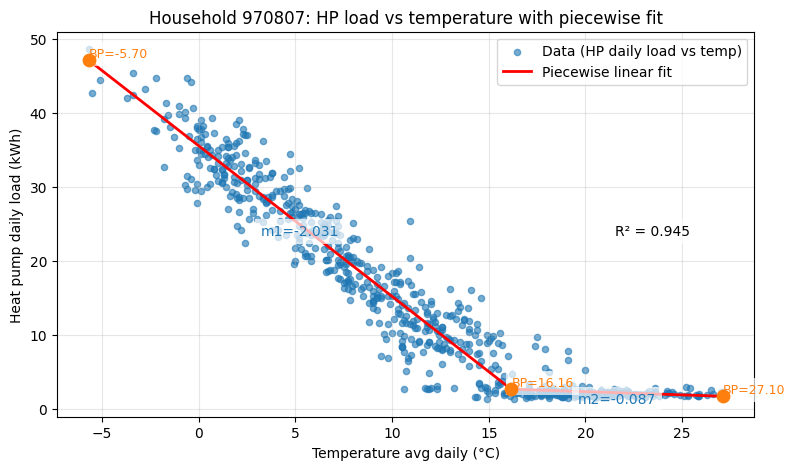

In [11]:
# example plot with one household and the existing y_fit
# pick a household for which we computed piecewise fit (from cell 13)
i = 3
example_id = datarangeDf.index[i]

df_example = heapo.load_smart_meter_and_weather_data_combined(example_id,
    smd_resolution='daily', weather_resolution='daily', interpolate_hourly=False)

df_example = df_example.dropna(subset=['Temperature_avg_daily', 'kWh_received_HeatPump'])
x = df_example['Temperature_avg_daily'].values
y = df_example['kWh_received_HeatPump'].values

plin = pwlf.PiecewiseLinFit(x, y)
breakpoints = plin.fit(2)

# make x_fit consistent with y_fit length
x_hat = np.linspace(x.min(), x.max(), 100)
y_hat = plin.predict(x_hat)

plt.figure(figsize=(9, 5))
plt.scatter(x, y, s=20, alpha=0.6, label='Data (HP daily load vs temp)')
plt.plot(x_hat, y_hat, color='red', lw=2, label='Piecewise linear fit')
plt.xlabel('Temperature avg daily (°C)')
plt.ylabel('Heat pump daily load (kWh)')
plt.title(f'Household {example_id}: HP load vs temperature with piecewise fit')
plt.legend()
plt.grid(alpha=0.3)
r2 = r2_score_df.loc[example_id, 'R2_Score'] if 'r2_score_df' in globals() and example_id in r2_score_df.index else plin.r_squared()
plt.text(0.80, 0.5, f'R² = {r2:.3f}', transform=plt.gca().transAxes, fontsize=10, va='top', bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

# annotate breakpoints and slopes
for bp in breakpoints:
    y_bp = plin.predict(bp)
    plt.scatter(bp, y_bp, color='tab:orange', s=80, zorder=6)
    # plt.axvline(bp, color='tab:orange', linestyle='--', alpha=0.7)
    plt.text(bp, y_bp, f'BP={bp:.2f}', color='tab:orange', fontsize=9, rotation=0,
             ha='left', va='bottom', bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

for i, slope in enumerate(plin.slopes):
    x0 = breakpoints[i]
    x1 = breakpoints[i+1]
    xm = (x0 + x1) / 2
    ym = plin.predict(xm)
    plt.text(xm, ym, f'm{i+1}={slope:.3f}', color='tab:blue', fontsize=10,
             ha='center', va='top', bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))
plt.show()

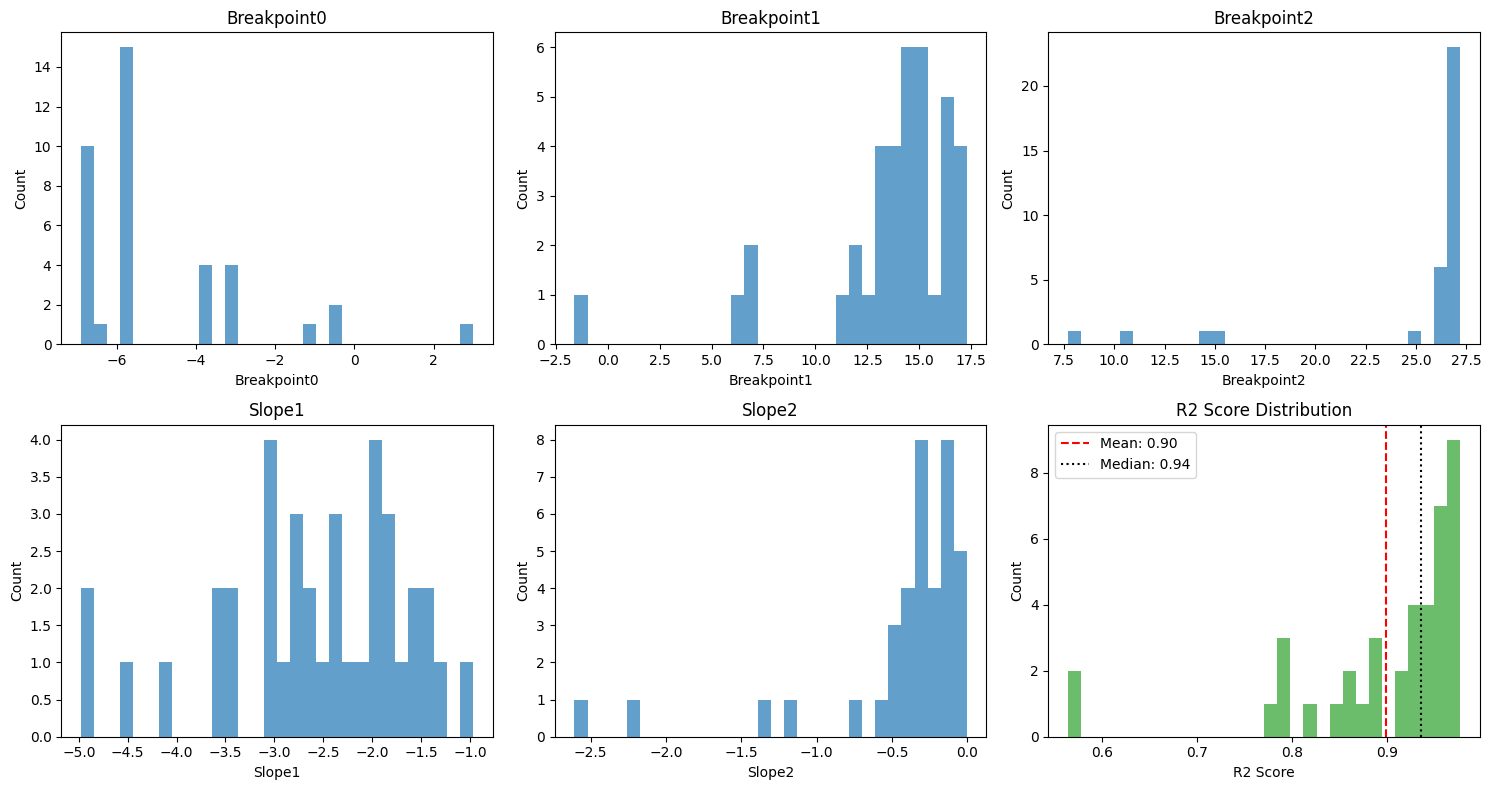

In [12]:
cols = ['Breakpoint0', 'Breakpoint1', 'Breakpoint2', 'Slope1', 'Slope2']

fig, axs = plt.subplots(2, 3, figsize=(15, 8))
axs = axs.flatten()

for i, col in enumerate(cols):
    ser = piece_lin_coeffs_hp_df[col].dropna()
    ser = ser[np.abs(ser) < np.percentile(np.abs(ser), 95)]  # remove outliers for better visualization
    axs[i].hist(ser, bins=30, color='tab:blue', alpha=0.7)
    axs[i].set_title(col)
    axs[i].set_xlabel(col)
    axs[i].set_ylabel('Count')

if 'r2_score_df' in globals() and not r2_score_df.empty:
    r2_scores = r2_score_df['R2_Score'].dropna()
    ax = axs[i+1]
    ax.hist(r2_scores, bins=30, color='tab:green', alpha=0.7)
    ax.set_title('R2 Score Distribution')
    ax.set_xlabel('R2 Score')
    ax.set_ylabel('Count')
    ax.axvline(r2_scores.mean(), color='red', linestyle='--', linewidth=1.5, label=f'Mean: {r2_scores.mean():.2f}')
    ax.axvline(r2_scores.median(), color='black', linestyle=':', linewidth=1.5, label=f'Median: {r2_scores.median():.2f}')
    ax.legend()
else:
    axs[len(cols)].text(0.5, 0.5, 'No R2 score data', ha='center', va='center')

# # remove empty axis
# if len(cols) < len(axs):
#     for j in range(len(cols), len(axs)):
#         fig.delaxes(axs[j])

fig.tight_layout()
plt.show()

### Fit smart meter load to temperature as a piecewise linear function (DAILY)

In [13]:
piece_lin_coeffs = []

r2_score_list = []

for id in tqdm(df_meta['Household_ID'], desc='Fitting piecewise linear functions'):
    try:
        sm_data = heapo.load_smart_meter_and_weather_data_combined(id, smd_resolution='daily', weather_resolution='daily', interpolate_hourly=False)
    except:
        continue
    
    sm_data = sm_data.dropna(subset=['Temperature_avg_daily', 'kWh_received_Total'])
    x = sm_data['Temperature_avg_daily'].values
    y = sm_data['kWh_received_Total'].values
    try:
        plin = pwlf.PiecewiseLinFit(x, y)
        breakpoints = plin.fit(2)
        piece_lin_coeffs.append((id, *breakpoints, *plin.slopes))
        r2_score_list.append((id, plin.r_squared()))

    except:
        pass
    
piece_lin_coeffs_df = pd.DataFrame(piece_lin_coeffs, columns=['Household_ID', 'Breakpoint0', 'Breakpoint1', 'Breakpoint2', 'Slope1', 'Slope2'])
piece_lin_coeffs_df.set_index('Household_ID', inplace=True)

r2_score_df = pd.DataFrame(r2_score_list, columns=['Household_ID', 'R2_Score'])
r2_score_df.set_index('Household_ID', inplace=True)

Fitting piecewise linear functions:   9%|▉         | 124/1408 [00:03<00:40, 31.34it/s]c:\Users\VENANCIA\OneDrive - VITO\Desktop\NILM\.venv\Lib\site-packages\pwlf\pwlf.py:1248: RuntimeWarning: invalid value encountered in divide
  self.slopes = np.divide(
c:\Users\VENANCIA\OneDrive - VITO\Desktop\NILM\.venv\Lib\site-packages\pwlf\pwlf.py:1521: RuntimeWarning: invalid value encountered in scalar divide
  rsq = 1.0 - (ssr / sst)
Fitting piecewise linear functions: 100%|██████████| 1408/1408 [00:43<00:00, 32.70it/s]


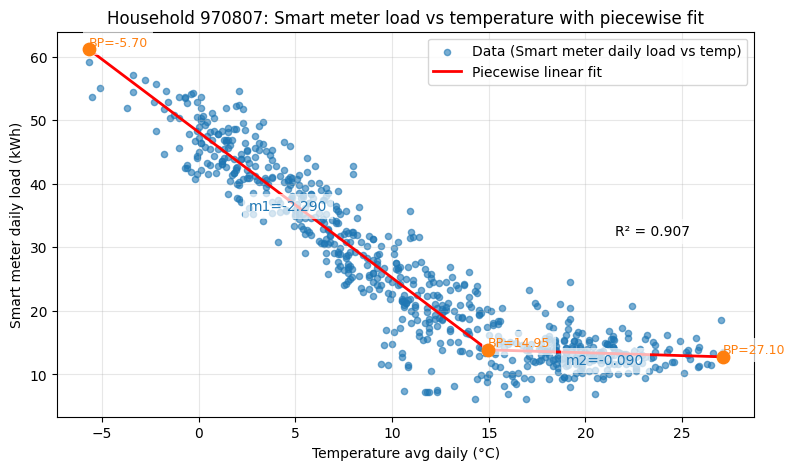

In [14]:
# example plot with one household and the existing y_fit
# pick a household for which we computed piecewise fit (from cell 13)
i = 3

example_id = datarangeDf.index[i]

df_example = heapo.load_smart_meter_and_weather_data_combined(example_id,
    smd_resolution='daily', weather_resolution='daily', interpolate_hourly=False)

df_example = df_example.dropna(subset=['Temperature_avg_daily', 'kWh_received_Total'])
x = df_example['Temperature_avg_daily'].values
y = df_example['kWh_received_Total'].values

plin = pwlf.PiecewiseLinFit(x, y)
breakpoints = plin.fit(2)

# make x_fit consistent with y_fit length
x_hat = np.linspace(x.min(), x.max(), 100)
y_hat = plin.predict(x_hat)

plt.figure(figsize=(9, 5))
plt.scatter(x, y, s=20, alpha=0.6, label='Data (Smart meter daily load vs temp)')
plt.plot(x_hat, y_hat, color='red', lw=2, label='Piecewise linear fit')
plt.xlabel('Temperature avg daily (°C)')
plt.ylabel('Smart meter daily load (kWh)')
plt.title(f'Household {example_id}: Smart meter load vs temperature with piecewise fit')
plt.legend()
plt.grid(alpha=0.3)
r2 = r2_score_df.loc[example_id, 'R2_Score'] if 'r2_score_df' in globals() and example_id in r2_score_df.index else plin.r_squared()
plt.text(0.80, 0.5, f'R² = {r2:.3f}', transform=plt.gca().transAxes, fontsize=10, va='top', bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

# annotate breakpoints and slopes
for bp in breakpoints:
    y_bp = plin.predict(bp)
    plt.scatter(bp, y_bp, color='tab:orange', s=80, zorder=6)
    # plt.axvline(bp, color='tab:orange', linestyle='--', alpha=0.7)
    plt.text(bp, y_bp, f'BP={bp:.2f}', color='tab:orange', fontsize=9, rotation=0,
             ha='left', va='bottom', bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

for i, slope in enumerate(plin.slopes):
    x0 = breakpoints[i]
    x1 = breakpoints[i+1]
    xm = (x0 + x1) / 2
    ym = plin.predict(xm)
    plt.text(xm, ym, f'm{i+1}={slope:.3f}', color='tab:blue', fontsize=10,
             ha='center', va='top', bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))
plt.show()

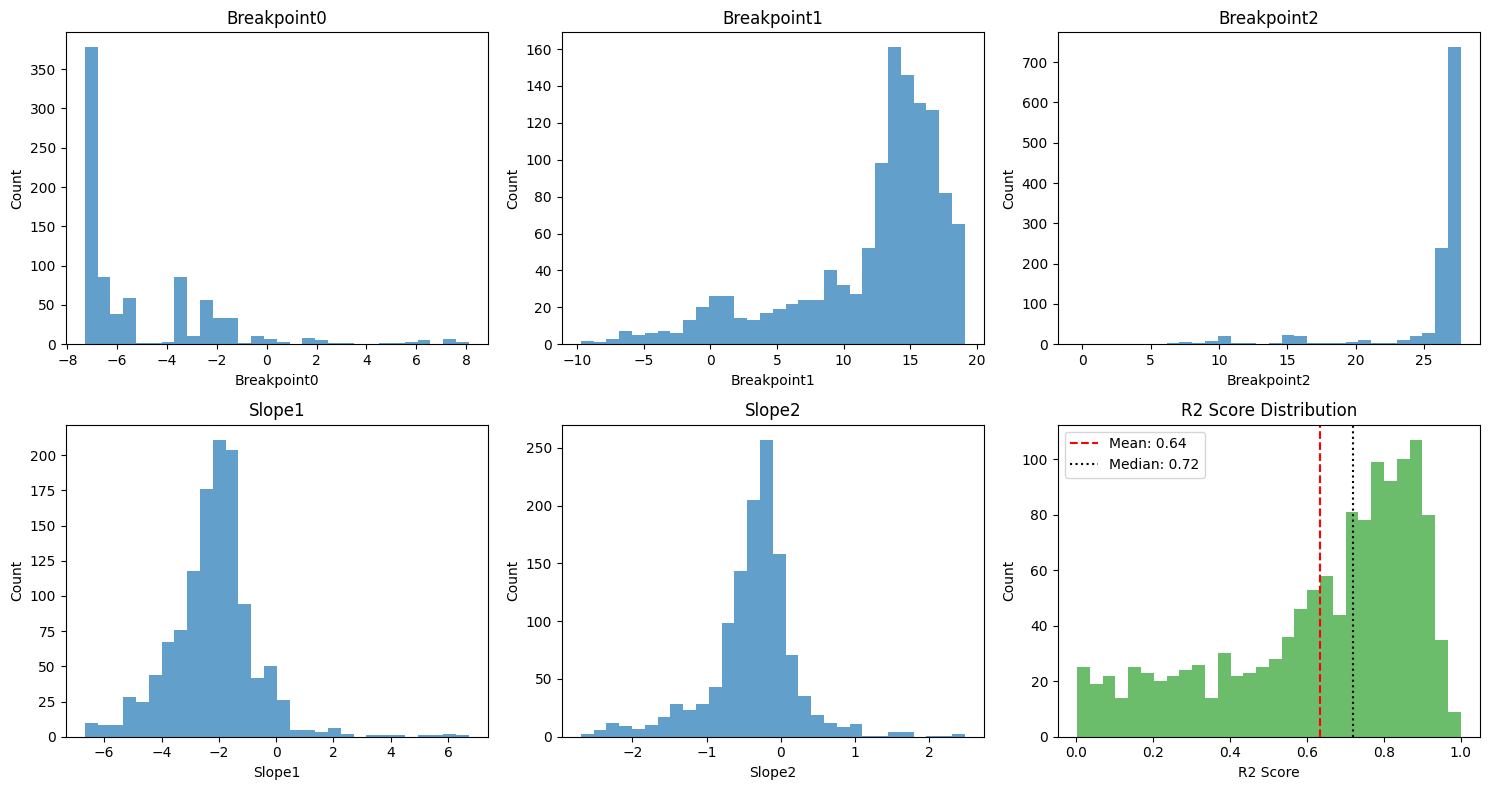

In [15]:
if 'piece_lin_coeffs_df' in globals() and not piece_lin_coeffs_df.empty:
    cols = ['Breakpoint0', 'Breakpoint1', 'Breakpoint2', 'Slope1', 'Slope2']

    fig, axs = plt.subplots(2, 3, figsize=(15, 8))
    axs = axs.flatten()

    for i, col in enumerate(cols):
        ser = piece_lin_coeffs_df[col].dropna()
        ser = ser[np.abs(ser) < np.percentile(np.abs(ser), 95)]  # remove outliers for better visualization
        axs[i].hist(ser, bins=30, color='tab:blue', alpha=0.7)
        axs[i].set_title(col)
        axs[i].set_xlabel(col)
        axs[i].set_ylabel('Count')

    if 'r2_score_df' in globals() and not r2_score_df.empty:
        r2_scores = r2_score_df['R2_Score'].dropna()
        ax = axs[i+1]
        ax.hist(r2_scores, bins=30, color='tab:green', alpha=0.7)
        ax.set_title('R2 Score Distribution')
        ax.set_xlabel('R2 Score')
        ax.set_ylabel('Count')
        ax.axvline(r2_scores.mean(), color='red', linestyle='--', linewidth=1.5, label=f'Mean: {r2_scores.mean():.2f}')
        ax.axvline(r2_scores.median(), color='black', linestyle=':', linewidth=1.5, label=f'Median: {r2_scores.median():.2f}')
        ax.legend()
    else:
        axs[len(cols)].text(0.5, 0.5, 'No R2 score data', ha='center', va='center')

    # # remove empty axis
    # if len(cols) < len(axs):
    #     for j in range(len(cols), len(axs)):
    #         fig.delaxes(axs[j])

    fig.tight_layout()
    plt.show()
else:
    print("piece_lin_coeffs_df is not available or empty")

Ground-source vs Air-source

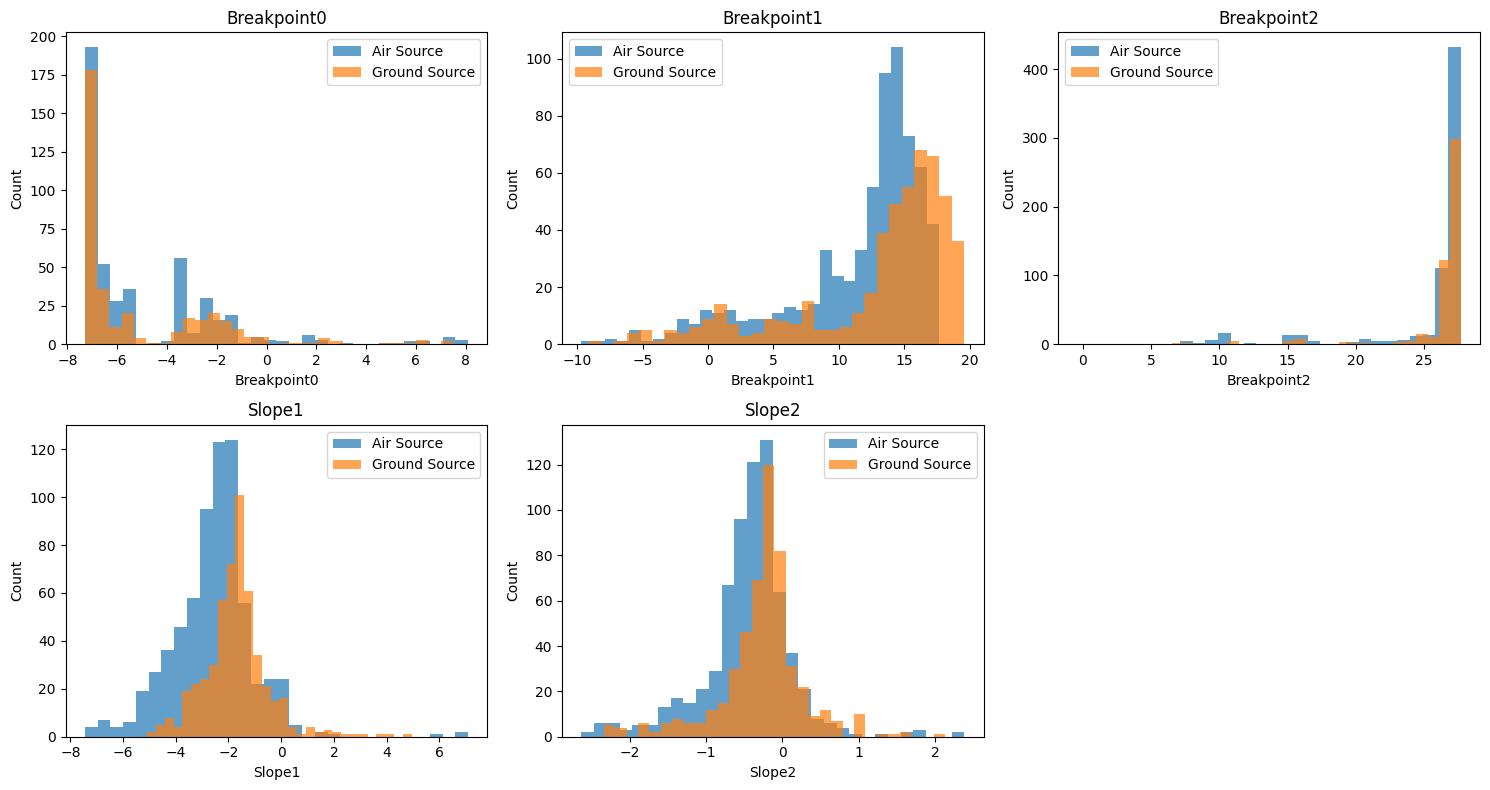

In [16]:
cols = ['Breakpoint0', 'Breakpoint1', 'Breakpoint2', 'Slope1', 'Slope2']

air_source_mask = df_meta['Survey_HeatPump_Installation_Type'][df_meta['Household_ID'].isin(piece_lin_coeffs_df.index)] == 'air-source'
ground_source_mask = df_meta['Survey_HeatPump_Installation_Type'][df_meta['Household_ID'].isin(piece_lin_coeffs_df.index)] == 'ground-source'


coeffs_air = piece_lin_coeffs_df[air_source_mask.to_list()]
coeffs_ground = piece_lin_coeffs_df[ground_source_mask.to_list()]

fig, axs = plt.subplots(2, 3, figsize=(15, 8))
axs = axs.flatten()

for i, col in enumerate(cols):
    ser_air = coeffs_air[col].dropna()
    ser_ground = coeffs_ground[col].dropna()

    ser_air = ser_air[np.abs(ser_air) < np.percentile(np.abs(ser_air), 95)]  # remove outliers for better visualization
    ser_ground = ser_ground[np.abs(ser_ground) < np.percentile(np.abs(ser_ground), 95)]  # remove outliers for better visualization

    axs[i].hist(ser_air, bins=30, color='tab:blue', alpha=0.7, label='Air Source')
    axs[i].hist(ser_ground, bins=30, color='tab:orange', alpha=0.7, label='Ground Source')
    axs[i].set_title(col)
    axs[i].set_xlabel(col)
    axs[i].set_ylabel('Count')
    axs[i].legend()

# remove empty axis
if len(cols) < len(axs):
    for j in range(len(cols), len(axs)):
        fig.delaxes(axs[j])

fig.tight_layout()
plt.show()

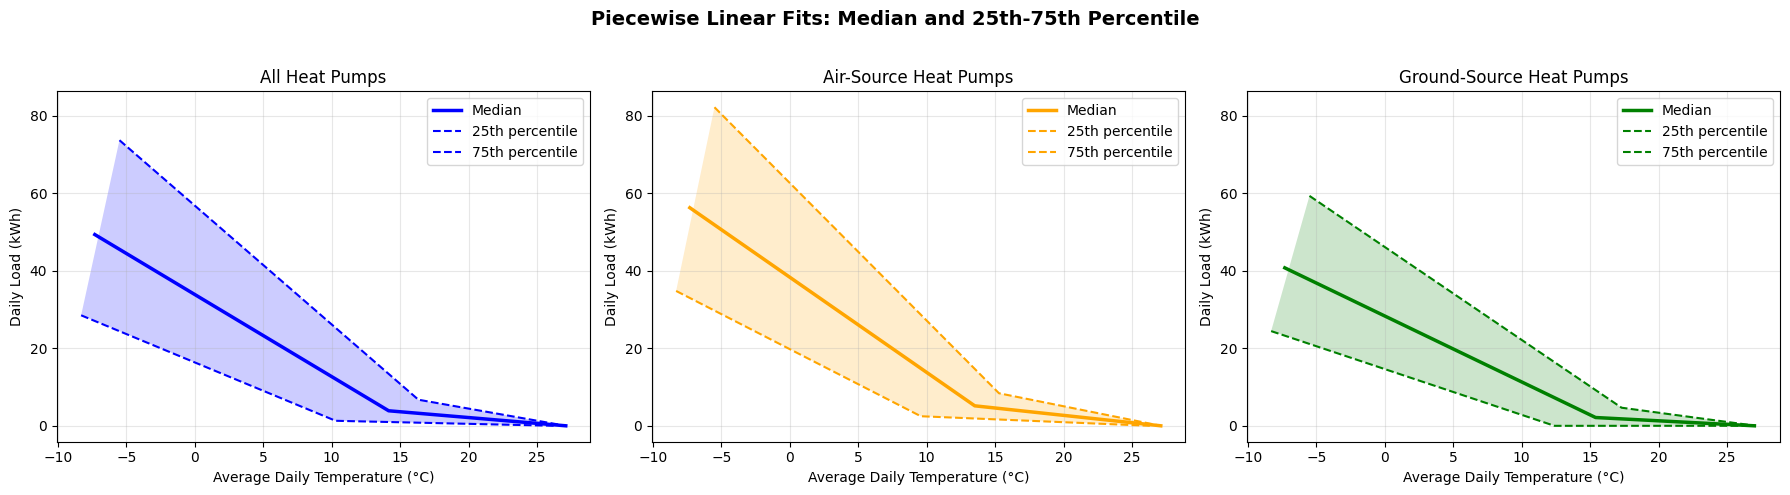

In [17]:
# Calculate percentiles and mean of breakpoints for all HPs, air-source, and ground-source
cols_bp = ['Breakpoint0', 'Breakpoint1', 'Breakpoint2']
cols_slopes = ['Slope1', 'Slope2']

# All HPs
bp_median_all = piece_lin_coeffs_df[cols_bp].median()
bp_p25_all = piece_lin_coeffs_df[cols_bp].quantile(0.25)
bp_p75_all = piece_lin_coeffs_df[cols_bp].quantile(0.75)

slope_median_all = piece_lin_coeffs_df[cols_slopes].median()
slope_p25_all = piece_lin_coeffs_df[cols_slopes].quantile(0.25)
slope_p75_all = piece_lin_coeffs_df[cols_slopes].quantile(0.75)

# Air-source
bp_median_air = coeffs_air[cols_bp].median()
bp_p25_air = coeffs_air[cols_bp].quantile(0.25)
bp_p75_air = coeffs_air[cols_bp].quantile(0.75)

slope_median_air = coeffs_air[cols_slopes].median()
slope_p25_air = coeffs_air[cols_slopes].quantile(0.25)
slope_p75_air = coeffs_air[cols_slopes].quantile(0.75)

# Ground-source
bp_median_ground = coeffs_ground[cols_bp].median()
bp_p25_ground = coeffs_ground[cols_bp].quantile(0.25)
bp_p75_ground = coeffs_ground[cols_bp].quantile(0.75)

slope_median_ground = coeffs_ground[cols_slopes].median()
slope_p25_ground = coeffs_ground[cols_slopes].quantile(0.25)
slope_p75_ground = coeffs_ground[cols_slopes].quantile(0.75)


def fill_between_piecewise(ax, x_low, y_low, x_high, y_high, color='blue', alpha=0.2):
    x_low = np.asarray(x_low); y_low = np.asarray(y_low)
    x_high = np.asarray(x_high); y_high = np.asarray(y_high)

    # ensure order by x
    order_low = np.argsort(x_low)
    order_high = np.argsort(x_high)

    x_low, y_low = x_low[order_low], y_low[order_low]
    x_high, y_high = x_high[order_high], y_high[order_high]

    poly_coords = np.vstack([
        np.column_stack([x_low, y_low]),
        np.column_stack([x_high[::-1], y_high[::-1]])
    ])
    poly = Polygon(poly_coords, closed=True, facecolor=color, alpha=alpha, edgecolor='none')
    ax.add_patch(poly)

# Function to predict using breakpoints and slopes
def predict_piecewise(breakpoints, slopes):
    y = np.zeros_like(breakpoints, dtype=float)
    for i in range(len(breakpoints) - 2, -1, -1):
        y[i] = slopes[i] * (breakpoints[i] - breakpoints[i+1]) + y[i+1]
    return y

# Create subplots
fig, axs = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: All HPs
ax = axs[0]
y_median = predict_piecewise(bp_median_all.values, slope_median_all.values)
y_p25 = predict_piecewise(bp_p25_all.values, slope_p75_all.values)
y_p75 = predict_piecewise(bp_p75_all.values, slope_p25_all.values)

fill_between_piecewise(ax, bp_p25_all.values, y_p25, bp_p75_all.values, y_p75, color='blue', alpha=0.2)

ax.plot(bp_median_all.values, y_median, 'b-', linewidth=2.5, label='Median')
ax.plot(bp_p25_all.values, y_p25, 'b--', linewidth=1.5, label='25th percentile')
ax.plot(bp_p75_all.values, y_p75, 'b--', linewidth=1.5, label='75th percentile')

ax.set_xlabel('Average Daily Temperature (°C)')
ax.set_ylabel('Daily Load (kWh)')
ax.set_title('All Heat Pumps')
ax.grid(alpha=0.3)
ax.legend()

# Plot 2: Air-source
ax = axs[1]
y_median = predict_piecewise(bp_median_air.values, slope_median_air.values)
y_p25 = predict_piecewise(bp_p25_air.values, slope_p75_air.values)
y_p75 = predict_piecewise(bp_p75_air.values, slope_p25_air.values)

fill_between_piecewise(ax, bp_p25_air.values, y_p25, bp_p75_air.values, y_p75, color='orange', alpha=0.2)

ax.plot(bp_median_air.values, y_median, color='orange', linewidth=2.5, label='Median')
ax.plot(bp_p25_air.values, y_p25, color='orange', linestyle='--', linewidth=1.5, label='25th percentile')
ax.plot(bp_p75_air.values, y_p75, color='orange', linestyle='--', linewidth=1.5, label='75th percentile')

ax.set_xlabel('Average Daily Temperature (°C)')
ax.set_ylabel('Daily Load (kWh)')
ax.set_title('Air-Source Heat Pumps')
ax.grid(alpha=0.3)
ax.legend()

# Plot 3: Ground-source
ax = axs[2]
y_median = predict_piecewise(bp_median_ground.values, slope_median_ground.values)
y_p25 = predict_piecewise(bp_p25_ground.values, slope_p75_ground.values)
y_p75 = predict_piecewise(bp_p75_ground.values, slope_p25_ground.values)

fill_between_piecewise(ax, bp_p25_ground.values, y_p25, bp_p75_ground.values, y_p75, color='green', alpha=0.2)

ax.plot(bp_median_ground.values, y_median, color='green', linewidth=2.5, label='Median')
ax.plot(bp_p25_ground.values, y_p25, color='green', linestyle='--', linewidth=1.5, label='25th percentile')
ax.plot(bp_p75_ground.values, y_p75, color='green', linestyle='--', linewidth=1.5, label='75th percentile')

ax.set_xlabel('Average Daily Temperature (°C)')
ax.set_ylabel('Daily Load (kWh)')
ax.set_title('Ground-Source Heat Pumps')
ax.grid(alpha=0.3)
ax.legend()
ymin = min(ax.get_ylim()[0] for ax in axs)
ymax = max(ax.get_ylim()[1] for ax in axs)
for ax in axs:
    ax.set_ylim(ymin, ymax)
fig.suptitle('Piecewise Linear Fits: Median and 25th-75th Percentile', fontsize=14, fontweight='bold')
fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


### Create synthetic substations

In [18]:
all_smd = heapo.load_smart_meter_data_multiple(datarangeDf.index.tolist(), resolution='15min')
all_smd = all_smd[(all_smd['Timestamp'] >= pd.to_datetime(start_date)) & (all_smd['Timestamp'] <= pd.to_datetime(end_date))]

In [19]:
if regenerate_substations:
    n_substations = 2000

    substations = {}

    min_substation_size = 2
    max_substation_size = 100

    available_households = list(datarangeDf.index)
    available_weather_ids = list(datarangeDf['Weather_ID'])

    datetime_range = pd.date_range(start=start_date, end=end_date, freq='15min')

    for i in trange(n_substations, desc='Generating substations'):

        hp_ratio = uniform(0.1, 1.0) # ratio of households with heat pump in substation
        substation_size = randint(min_substation_size, max_substation_size) # number of households in substation

        n_hps = int(hp_ratio * substation_size)

        substations[i] = {
            'size': substation_size,
            'HP_ratio': hp_ratio,
        }
        
        weather_station = sample(available_weather_ids, 1)[0] # randomly select weather station
        substations[i]['weather_id'] = weather_station
        
        households_hp = datarangeDf[datarangeDf['Weather_ID'] == weather_station].sample(n_hps, replace=True).index.tolist() # randomly select households with this weather station
        substations[i]['households_hp'] = households_hp

        households = datarangeDf.sample(substation_size - n_hps, replace=True).index.tolist()
        substations[i]['households'] = households

        substations[i]['HP_Load'] = pd.Series(0, index=datetime_range)
        substations[i]['Total_Load'] = pd.Series(0, index=datetime_range)

        for household_id in households_hp:
            smd_hp = all_smd[all_smd['Household_ID'] == household_id]
            smd_hp = smd_hp.set_index('Timestamp')
            smd_hp = smd_hp.sort_index()
            substations[i]['HP_Load'] += smd_hp['kWh_received_HeatPump'].interpolate(method='time')
            substations[i]['Total_Load'] += smd_hp['kWh_received_Other'].interpolate(method='time') + smd_hp['kWh_received_HeatPump'].interpolate(method='time')
        
        for household_id in households:
            smd = all_smd[all_smd['Household_ID'] == household_id]
            smd = smd.set_index('Timestamp')
            smd = smd.sort_index()
            substations[i]['Total_Load'] += smd['kWh_received_Other'].interpolate(method='time')

        substations[i]['HP_Load'] = substations[i]['HP_Load'] * 4 # convert to kW
        substations[i]['Total_Load'] = substations[i]['Total_Load'] * 4 # convert to kW

        weather_data = heapo.load_weather_data(weather_station, resolution='hourly')
        weather_data = weather_data[(weather_data['Timestamp'] >= pd.to_datetime(start_date)) & (weather_data['Timestamp'] <= pd.to_datetime(end_date))][['Timestamp', 'Temperature_avg_hourly']]
        weather_data = weather_data.set_index('Timestamp')
        weather_data = weather_data.resample('15min').interpolate(method='time')

        substations[i]['Temperature'] = weather_data['Temperature_avg_hourly']

        substations[i]['HP_Peak'] = np.sum([hp_peaks_df[hp_peaks_df['Household_ID'] == household_id]['HP_Peak'].values[0] for household_id in households_hp])
        
        # Add Ground and Air source information

        loadDict = {
            'Total_Load': substations[i]['Total_Load'].values,
            'Date': substations[i]['Total_Load'].index.date,
            'Time': substations[i]['Total_Load'].index.time
        }

        loadDf = pd.DataFrame(loadDict, columns=['Total_Load', 'Date', 'Time'])

        weather_data['Date'] = weather_data.index.date
        weather_data['Time'] = weather_data.index.time

        dailyLoad = loadDf.pivot(index='Date', columns='Time', values='Total_Load').ffill()

        dailyWeather = weather_data.pivot(index='Date', columns='Time', values='Temperature_avg_hourly').ffill()

        dailyWeather = dailyWeather[dailyWeather.index.isin(dailyLoad.index)]

        dailyFeatures = {}
        dailyFeatures['Mean'] = dailyLoad.mean(axis=1)
        dailyFeatures['Std'] = dailyLoad.std(axis=1)
        dailyFeatures['Min'] = dailyLoad.min(axis=1)
        dailyFeatures['Max'] = dailyLoad.max(axis=1)
        dailyFeatures['Skew'] = dailyLoad.skew(axis=1)
        dailyFeatures['Kurtosis'] = dailyLoad.kurtosis(axis=1)
        dailyFeatures['Max-Min'] = dailyLoad.max(axis=1) - dailyLoad.min(axis=1)
        dailyFeatures['Cov'] = np.array([np.cov(dailyLoad.iloc[i], dailyWeather.iloc[i])[0][1] 
                                                for i in range(len(dailyLoad))])
        dailyFeatures['Corr_Pearson'] = pearsonr(x=dailyLoad, y=dailyWeather, axis=1).statistic

        dailyFeaturesDf = pd.DataFrame(dailyFeatures)
        
        features = {}
        features['Mean'] = dailyFeaturesDf.mean()
        features['Std'] = dailyFeaturesDf.std()
        features['Min'] = dailyFeaturesDf.min()
        features['Max'] = dailyFeaturesDf.max()
        features['Median'] = dailyFeaturesDf.median()
        
        for key_main in features.keys():
            for key_sub in features[key_main].index:
                substations[i][f'Feature_{key_main}_{key_sub}'] = features[key_main][key_sub]

    # Save substations data
    substations_df = pd.DataFrame.from_dict(substations, orient='index')
    pickle.dump(substations_df, open('data/substations_data.pkl', 'wb'))
else:
    substations_df = pickle.load(open('data/substations_data.pkl', 'rb'))

In [20]:
if regenerate_substations:
    n_substations = 100

    substations_test = {}

    available_households = list(datarangeDf.index)
    available_weather_ids = list(datarangeDf['Weather_ID'])

    for i in trange(n_substations, desc='Generating substations'):

        hp_ratio = 0.5 # ratio of households with heat pump in substation
        substation_size = 50 # number of households in substation

        n_hps = int(hp_ratio * substation_size)

        substations_test[i] = {
            'size': substation_size,
            'HP_ratio': hp_ratio,
        }
        
        weather_station = sample(available_weather_ids, 1)[0] # randomly select weather station
        substations_test[i]['weather_id'] = weather_station
        
        households_hp = datarangeDf[datarangeDf['Weather_ID'] == weather_station].sample(n_hps, replace=True).index.tolist() # randomly select households with this weather station
        substations_test[i]['households_hp'] = households_hp

        households = datarangeDf.sample(substation_size - n_hps, replace=True).index.tolist()
        substations_test[i]['households'] = households

        if len(households_hp) > 0:
            smd_hp = heapo.load_smart_meter_data_multiple(households_hp, resolution='15min')
            smd_hp = smd_hp[(smd_hp['Timestamp'] >= pd.to_datetime(start_date)) & (smd_hp['Timestamp'] <= pd.to_datetime(end_date))]
            smd_hp_agg = smd_hp[['Timestamp', 'kWh_received_HeatPump', 'kWh_received_Other']].groupby('Timestamp').sum()
        else:
            smd_hp_agg = np.zeros((len(pd.date_range(start=start_date, end=end_date, freq='15min')), 2))
            smd_hp_agg = pd.DataFrame(smd_hp_agg, columns=['kWh_received_HeatPump', 'kWh_received_Other'], index=pd.date_range(start=start_date, end=end_date, freq='15min'))

        if len(households) > 0:
            smd = heapo.load_smart_meter_data_multiple(households, resolution='15min')
            smd = smd[(smd['Timestamp'] >= pd.to_datetime(start_date)) & (smd['Timestamp'] <= pd.to_datetime(end_date))]
            smd_agg = smd[['Timestamp', 'kWh_received_Other']].groupby('Timestamp').sum()
        else:
            smd_agg = np.zeros((len(pd.date_range(start=start_date, end=end_date, freq='15min')), 1))
            smd_agg = pd.DataFrame(smd_agg, columns=['kWh_received_Other'], index=pd.date_range(start=start_date, end=end_date, freq='15min'))

        substations_test[i]['HP_Load'] = (smd_hp_agg['kWh_received_HeatPump'] * 4).dropna() # convert to kW
        substations_test[i]['Total_Load'] = (smd_hp_agg['kWh_received_HeatPump'] * 4 + smd_hp_agg['kWh_received_Other'] * 4 + smd_agg['kWh_received_Other'] * 4).dropna() # convert to kW

        weather_data = heapo.load_weather_data(weather_station, resolution='hourly')
        weather_data = weather_data[(weather_data['Timestamp'] >= pd.to_datetime(start_date)) & (weather_data['Timestamp'] <= pd.to_datetime(end_date))][['Timestamp', 'Temperature_avg_hourly']]
        weather_data = weather_data.set_index('Timestamp')
        weather_data = weather_data.resample('15min').interpolate(method='time')

        substations_test[i]['Temperature'] = weather_data['Temperature_avg_hourly']

        substations_test[i]['HP_Peak'] = np.sum([hp_peaks_df[hp_peaks_df['Household_ID'] == household_id]['HP_Peak'].values[0] for household_id in households_hp])

        # Add Ground and Air source information

        loadDict = {
            'Total_Load': substations_test[i]['Total_Load'].values,
            'Date': substations_test[i]['Total_Load'].index.date,
            'Time': substations_test[i]['Total_Load'].index.time
        }

        loadDf = pd.DataFrame(loadDict, columns=['Total_Load', 'Date', 'Time'])

        weather_data['Date'] = weather_data.index.date
        weather_data['Time'] = weather_data.index.time

        dailyLoad = loadDf.pivot(index='Date', columns='Time', values='Total_Load').ffill()

        dailyWeather = weather_data.pivot(index='Date', columns='Time', values='Temperature_avg_hourly').ffill()

        dailyWeather = dailyWeather[dailyWeather.index.isin(dailyLoad.index)]

        dailyFeatures = {}
        dailyFeatures['Mean'] = dailyLoad.mean(axis=1)
        dailyFeatures['Std'] = dailyLoad.std(axis=1)
        dailyFeatures['Min'] = dailyLoad.min(axis=1)
        dailyFeatures['Max'] = dailyLoad.max(axis=1)
        dailyFeatures['Skew'] = dailyLoad.skew(axis=1)
        dailyFeatures['Kurtosis'] = dailyLoad.kurtosis(axis=1)
        dailyFeatures['Max-Min'] = dailyLoad.max(axis=1) - dailyLoad.min(axis=1)
        dailyFeatures['Cov'] = np.array([np.cov(dailyLoad.iloc[i], dailyWeather.iloc[i])[0][1] 
                                                for i in range(len(dailyLoad))])
        dailyFeatures['Corr_Pearson'] = pearsonr(x=dailyLoad, y=dailyWeather, axis=1).statistic

        dailyFeaturesDf = pd.DataFrame(dailyFeatures)
        
        features = {}
        features['Mean'] = dailyFeaturesDf.mean()
        features['Std'] = dailyFeaturesDf.std()
        features['Min'] = dailyFeaturesDf.min()
        features['Max'] = dailyFeaturesDf.max()
        features['Median'] = dailyFeaturesDf.median()
        
        for key_main in features.keys():
            for key_sub in features[key_main].index:
                substations_test[i][f'Feature_{key_main}_{key_sub}'] = features[key_main][key_sub]

    # Save substations data
    substations_val_df = pd.DataFrame.from_dict(substations_test, orient='index')
    pickle.dump(substations_val_df, open('data/substations_val_data.pkl', 'wb'))
else:
    substations_val_df = pickle.load(open('data/substations_val_data.pkl', 'rb'))

In [21]:
substations_df = substations_df.fillna(0)
substations_val_df = substations_val_df.fillna(0)

In [22]:
substations_df_train, substations_df_test = train_test_split(substations_df, test_size=0.5, random_state=42)

### Fite piecewise function to substation net load

In [70]:
piece_lin_coeff_sub = []
r2_score_sub = []

for id in tqdm(substations_df_train.index, desc='Fitting piecewise linear functions for substations'):
    try:
        sm_data = pd.DataFrame({
            'Temperature_avg_hourly': substations_df_train.loc[id, 'Temperature'].resample('D').mean(),
            'Total_Load': substations_df_train.loc[id, 'Total_Load'].resample('D').mean()
        }).dropna()

        x = sm_data['Temperature_avg_hourly'].values
        y = sm_data['Total_Load'].values

        plin = pwlf.PiecewiseLinFit(x, y)
        breakpoints = plin.fit(2)
        
        r2_score_sub.append((id, plin.r_squared()))

        if plin.r_squared() > 0.1:  # only keep good fits for training set
            piece_lin_coeff_sub.append((id, *breakpoints, *plin.slopes))
        else:
            piece_lin_coeff_sub.append((id, *breakpoints, 0, 0))

    except:
        pass

Fitting piecewise linear functions for substations: 100%|██████████| 1000/1000 [00:22<00:00, 43.76it/s]


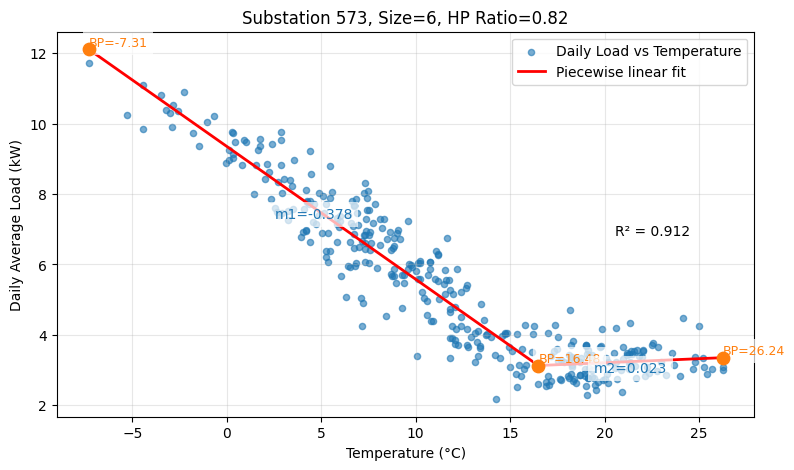

In [71]:
cols = ['Breakpoint0', 'Breakpoint1', 'Breakpoint2', 'Slope1', 'Slope2']

piece_lin_coeff_sub_df = pd.DataFrame(piece_lin_coeff_sub, columns=['Substation_ID', 'Breakpoint0', 'Breakpoint1', 'Breakpoint2', 'Slope1', 'Slope2'])
piece_lin_coeff_sub_df.set_index('Substation_ID', inplace=True)

r2_score_sub_df = pd.DataFrame(r2_score_sub, columns=['Substation_ID', 'R2_Score'])
r2_score_sub_df.set_index('Substation_ID', inplace=True)

# example plot with one substation and the existing y_fit
i = 1

example_id = int(piece_lin_coeff_sub_df.index.values[i])

df_example = pd.DataFrame({
    'Temperature_avg_hourly': substations_df_train.loc[example_id, 'Temperature'].resample('d').mean(),
    'Total_Load': substations_df_train.loc[example_id, 'Total_Load'].resample('d').mean(),
    'size' : substations_df_train.loc[example_id, 'size'],
    'HP_ratio' : substations_df_train.loc[example_id, 'HP_ratio']
}).dropna()

x = df_example['Temperature_avg_hourly'].values
y = df_example['Total_Load'].values
plin = pwlf.PiecewiseLinFit(x, y)
breakpoints = plin.fit(2)

# make x_fit consistent with y_fit length
x_hat = np.linspace(x.min(), x.max(), 100)
y_hat = plin.predict(x_hat)

plt.figure(figsize=(9, 5))
plt.scatter(x, y, s=20, alpha=0.6, label='Daily Load vs Temperature')
plt.plot(x_hat, y_hat, color='red', lw=2, label='Piecewise linear fit')
plt.xlabel('Temperature (°C)')
plt.ylabel('Daily Average Load (kW)')
plt.title(f'Substation {example_id}, Size={df_example["size"].iloc[i]}, HP Ratio={df_example["HP_ratio"].iloc[i]:.2f}')
plt.legend()
plt.grid(alpha=0.3)
r2 = r2_score_sub_df.loc[example_id, 'R2_Score'] if 'r2_score_sub_df' in globals() and example_id in r2_score_sub_df.index else plin.r_squared()
plt.text(0.80, 0.5, f'R² = {r2:.3f}', transform=plt.gca().transAxes, fontsize=10, va='top', bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))
# annotate breakpoints and slopes
for bp in breakpoints:
    y_bp = plin.predict(bp)
    plt.scatter(bp, y_bp, color='tab:orange', s=80, zorder=6)
    # plt.axvline(bp, color='tab:orange', linestyle='--', alpha=0.7)
    plt.text(bp, y_bp, f'BP={bp:.2f}', color='tab:orange', fontsize=9, rotation=0,
             ha='left', va='bottom', bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))
for i, slope in enumerate(plin.slopes):
    x0 = breakpoints[i]
    x1 = breakpoints[i+1]
    xm = (x0 + x1) / 2
    ym = plin.predict(xm)
    plt.text(xm, ym, f'm{i+1}={slope:.3f}', color='tab:blue', fontsize=10,
             ha='center', va='top', bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))
plt.show()

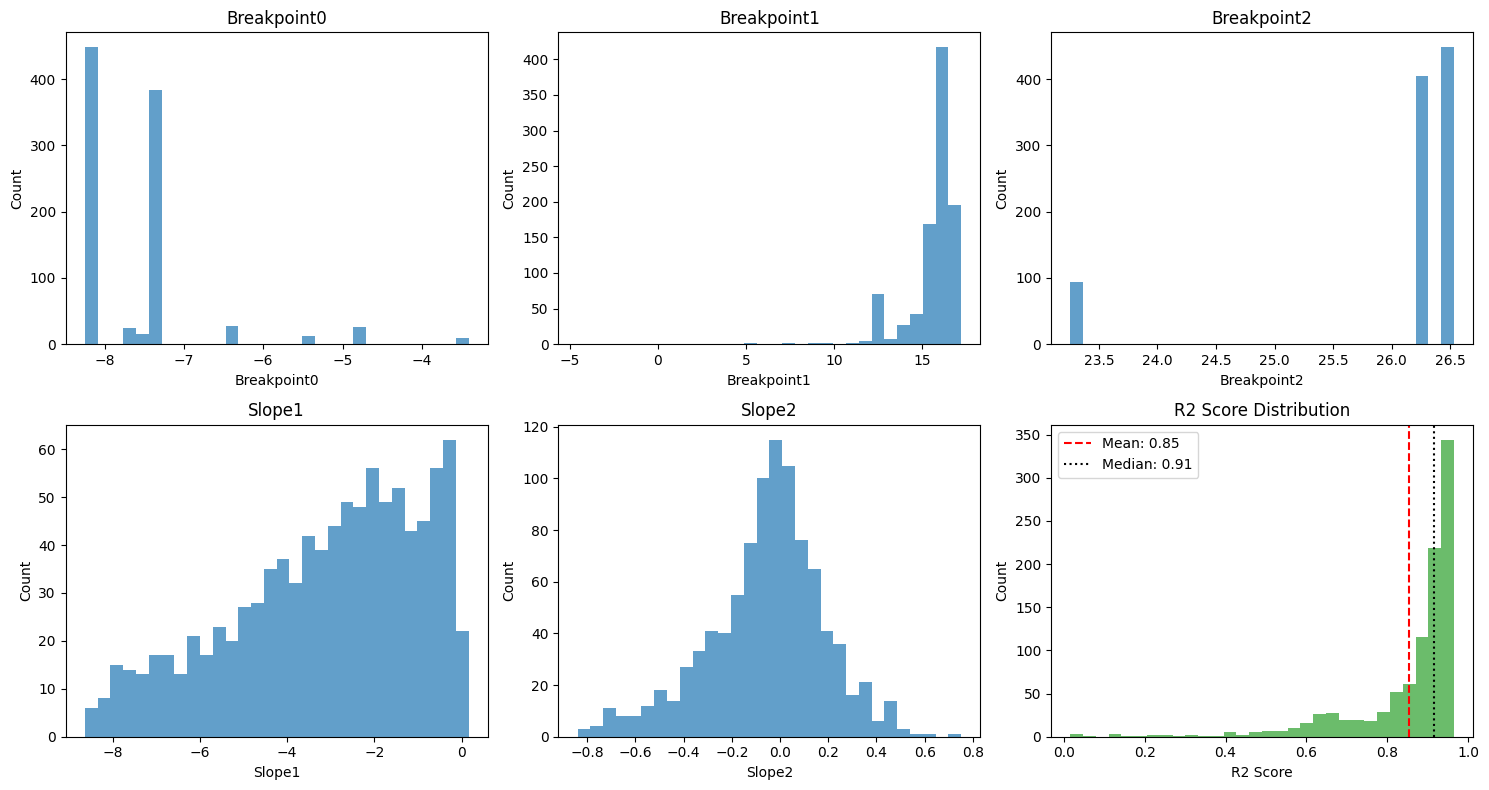

In [72]:
fig, axs = plt.subplots(2, 3, figsize=(15, 8))
axs = axs.flatten()

for i, col in enumerate(cols):
    ser = piece_lin_coeff_sub_df[col].dropna()
    ser = ser[np.abs(ser) < np.percentile(np.abs(ser), 95)]  # remove outliers for better visualization
    axs[i].hist(ser, bins=30, color='tab:blue', alpha=0.7)
    axs[i].set_title(col)
    axs[i].set_xlabel(col)
    axs[i].set_ylabel('Count')


r2_scores = r2_score_sub_df['R2_Score'].dropna()
ax = axs[i+1]
ax.hist(r2_scores, bins=30, color='tab:green', alpha=0.7)
ax.set_title('R2 Score Distribution')
ax.set_xlabel('R2 Score')
ax.set_ylabel('Count')
ax.axvline(r2_scores.mean(), color='red', linestyle='--', linewidth=1.5, label=f'Mean: {r2_scores.mean():.2f}')
ax.axvline(r2_scores.median(), color='black', linestyle=':', linewidth=1.5, label=f'Median: {r2_scores.median():.2f}')
ax.legend()
fig.tight_layout()
plt.show()

R² for delta_breakpoint_slope vs Simultaneous HP Peak: 0.798
1.550, 1.713


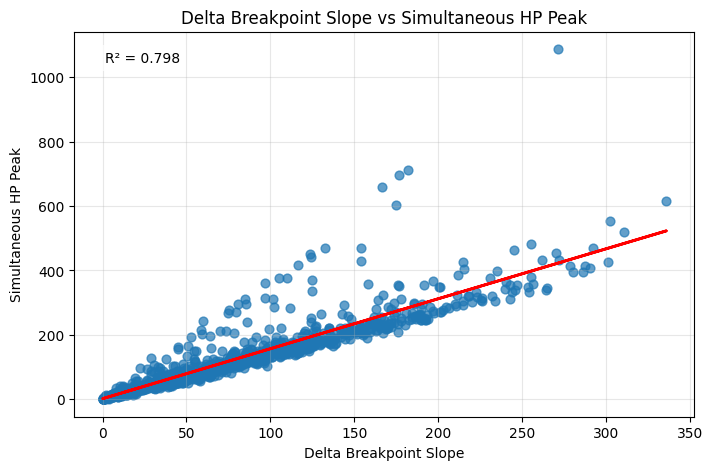

In [73]:
substations_df_train['Simult_HP_Peak'] = [substations_df_train.iloc[i]['HP_Load'].max() if hp_ratio > 0 else 0 for i, hp_ratio in enumerate(substations_df_train['HP_ratio'])]

data = piece_lin_coeff_sub_df[['Slope1']].join(substations_df_train[['Simult_HP_Peak']])
data['delta_breakpoint_slope'] = (piece_lin_coeff_sub_df['Breakpoint0'] - piece_lin_coeff_sub_df['Breakpoint1']) * piece_lin_coeff_sub_df['Slope1'] + (piece_lin_coeff_sub_df['Breakpoint1'] - piece_lin_coeff_sub_df['Breakpoint2']) * piece_lin_coeff_sub_df['Slope2']

lin = LinearRegression()
lin.fit(data[['delta_breakpoint_slope']], data['Simult_HP_Peak'])
r2 = lin.score(data[['delta_breakpoint_slope']], data['Simult_HP_Peak'])
print(f"R² for delta_breakpoint_slope vs Simultaneous HP Peak: {r2:.3f}")
print(f"{lin.coef_[0]:.3f}, {lin.intercept_:.3f}")

plt.figure(figsize=(8, 5))
plt.scatter(data['delta_breakpoint_slope'], data['Simult_HP_Peak'], alpha=0.7, s=40)
plt.plot(data['delta_breakpoint_slope'], lin.predict(data[['delta_breakpoint_slope']]), color='red', linewidth=2, label=f'Linear Fit (R²={r2:.3f})')
plt.text(0.05, 0.95, f'R² = {r2:.3f}', transform=plt.gca().transAxes, fontsize=10, va='top', bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))
plt.xlabel('Delta Breakpoint Slope')
plt.ylabel('Simultaneous HP Peak')
plt.title('Delta Breakpoint Slope vs Simultaneous HP Peak')
plt.grid(alpha=0.3)
plt.show()

R² for delta_breakpoint_slope vs Non-Simultaneous HP Peak: 0.935
2.442, -5.312


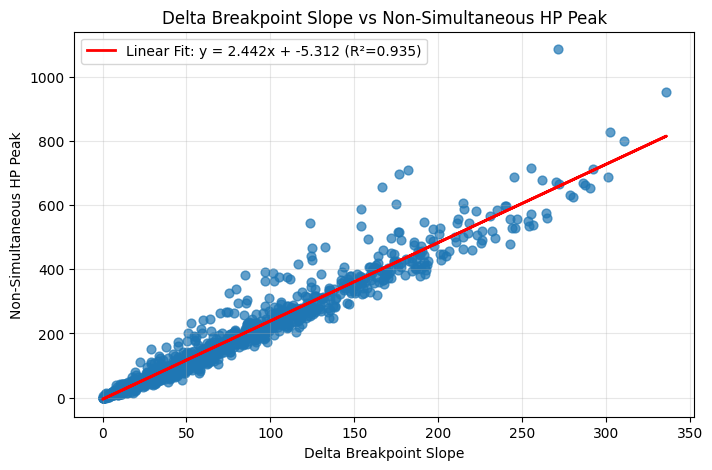

In [74]:
data = piece_lin_coeff_sub_df[['Slope1']].join(substations_df_train[['HP_Peak']])
data['delta_breakpoint_slope'] = (piece_lin_coeff_sub_df['Breakpoint0'] - piece_lin_coeff_sub_df['Breakpoint1']) * piece_lin_coeff_sub_df['Slope1'] + (piece_lin_coeff_sub_df['Breakpoint1'] - piece_lin_coeff_sub_df['Breakpoint2']) * piece_lin_coeff_sub_df['Slope2']

nonSimDeltaFit = LinearRegression()
nonSimDeltaFit.fit(data[['delta_breakpoint_slope']], data['HP_Peak'])
r2 = nonSimDeltaFit.score(data[['delta_breakpoint_slope']], data['HP_Peak'])
print(f"R² for delta_breakpoint_slope vs Non-Simultaneous HP Peak: {r2:.3f}")
print(f"{nonSimDeltaFit.coef_[0]:.3f}, {nonSimDeltaFit.intercept_:.3f}")

plt.figure(figsize=(8, 5))
plt.scatter(data['delta_breakpoint_slope'], data['HP_Peak'], alpha=0.7, s=40)
plt.plot(data['delta_breakpoint_slope'], nonSimDeltaFit.predict(data[['delta_breakpoint_slope']]), color='red', linewidth=2, label=f'Linear Fit: y = {nonSimDeltaFit.coef_[0]:.3f}x + {nonSimDeltaFit.intercept_:.3f} (R²={r2:.3f})')
# plt.text(0.05, 0.95, f'R² = {r2:.3f}', transform=plt.gca().transAxes, fontsize=10, va='top', bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))
# plt.text(0.05, 0.90, f'y = {nonSimDeltaFit.coef_[0]:.3f}x + {nonSimDeltaFit.intercept_:.3f}', transform=plt.gca().transAxes, fontsize=10, va='top', bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))
plt.xlabel('Delta Breakpoint Slope')
plt.ylabel('Non-Simultaneous HP Peak')
plt.title('Delta Breakpoint Slope vs Non-Simultaneous HP Peak')
plt.grid(alpha=0.3)
plt.legend()
plt.show()

In [69]:
piece_lin_coeff_test = []
r2_score_test = []

for id in tqdm(substations_df_test.index, desc='Fitting piecewise linear functions for substations'):
    try:
        sm_data = pd.DataFrame({
            'Temperature_avg_hourly': substations_df_test.loc[id, 'Temperature'].resample('D').mean(),
            'Total_Load': substations_df_test.loc[id, 'Total_Load'].resample('D').mean()
        }).dropna()

        x = sm_data['Temperature_avg_hourly'].values
        y = sm_data['Total_Load'].values

        plin = pwlf.PiecewiseLinFit(x, y)
        breakpoints = plin.fit(2)
        
        r2_score_test.append((id, plin.r_squared()))

        if plin.r_squared() > 0.1:  # only keep good fits for test set
            piece_lin_coeff_test.append((id, *breakpoints, *plin.slopes))
        else:
            piece_lin_coeff_test.append((id, *breakpoints, 0, 0))

    except:
        pass

Fitting piecewise linear functions for substations: 100%|██████████| 1000/1000 [00:22<00:00, 44.31it/s]


R² for delta_breakpoint_slope vs Non-Simultaneous HP Peak on test set: 0.933


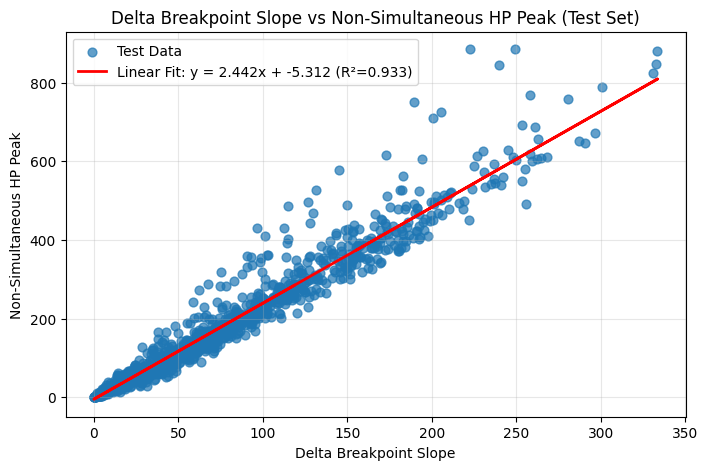

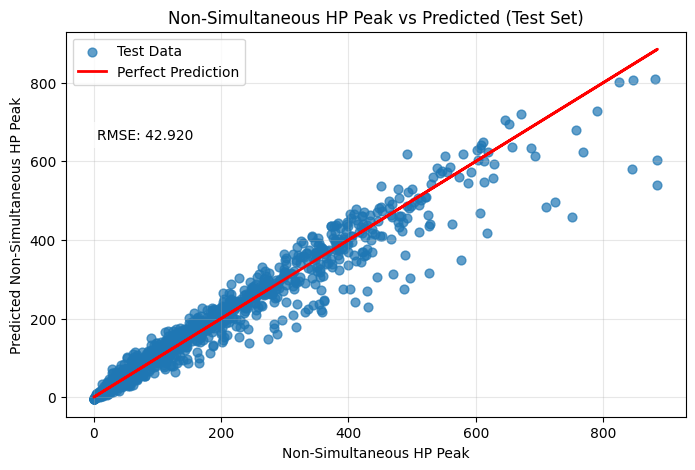

In [75]:
piece_lin_coeff_test_df = pd.DataFrame(piece_lin_coeff_test, columns=['Substation_ID', 'Breakpoint0', 'Breakpoint1', 'Breakpoint2', 'Slope1', 'Slope2'])
piece_lin_coeff_test_df.set_index('Substation_ID', inplace=True)

r2_score_test_df = pd.DataFrame(r2_score_test, columns=['Substation_ID', 'R2_Score'])
r2_score_test_df.set_index('Substation_ID', inplace=True)

delta_breakpoint_test = (piece_lin_coeff_test_df['Breakpoint0'] - piece_lin_coeff_test_df['Breakpoint1']) * piece_lin_coeff_test_df['Slope1'] + (piece_lin_coeff_test_df['Breakpoint1'] - piece_lin_coeff_test_df['Breakpoint2']) * piece_lin_coeff_test_df['Slope2']
data_test = pd.DataFrame({
    'delta_breakpoint_slope': delta_breakpoint_test,
    'HP_Peak': substations_df_test.loc[piece_lin_coeff_test_df.index, 'HP_Peak']
})

nonSimTestPred = nonSimDeltaFit.predict(data_test[['delta_breakpoint_slope']])
r2_nonSimTest = r2_score(data_test['HP_Peak'], nonSimTestPred)
print(f"R² for delta_breakpoint_slope vs Non-Simultaneous HP Peak on test set: {r2_nonSimTest:.3f}")

plt.figure(figsize=(8, 5))
plt.scatter(data_test['delta_breakpoint_slope'], data_test['HP_Peak'], alpha=0.7, s=40, label='Test Data')
plt.plot(data_test['delta_breakpoint_slope'], nonSimTestPred, color='red', linewidth=2, label=f'Linear Fit: y = {nonSimDeltaFit.coef_[0]:.3f}x + {nonSimDeltaFit.intercept_:.3f} (R²={r2_nonSimTest:.3f})')
plt.xlabel('Delta Breakpoint Slope')
plt.ylabel('Non-Simultaneous HP Peak')
plt.title('Delta Breakpoint Slope vs Non-Simultaneous HP Peak (Test Set)')
plt.grid(alpha=0.3)
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.scatter(data_test['HP_Peak'], nonSimTestPred, alpha=0.7, s=40, label='Test Data')
plt.plot(data_test['HP_Peak'], data_test['HP_Peak'], color='red', linewidth=2, label='Perfect Prediction')
plt.xlabel('Non-Simultaneous HP Peak')
plt.ylabel('Predicted Non-Simultaneous HP Peak')
plt.title('Non-Simultaneous HP Peak vs Predicted (Test Set)')
plt.text(0.05, 0.75, f'RMSE: {np.sqrt(mean_squared_error(data_test["HP_Peak"], nonSimTestPred)):.3f}', transform=plt.gca().transAxes, fontsize=10, va='top', bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))
plt.grid(alpha=0.3)
plt.legend()
plt.show()

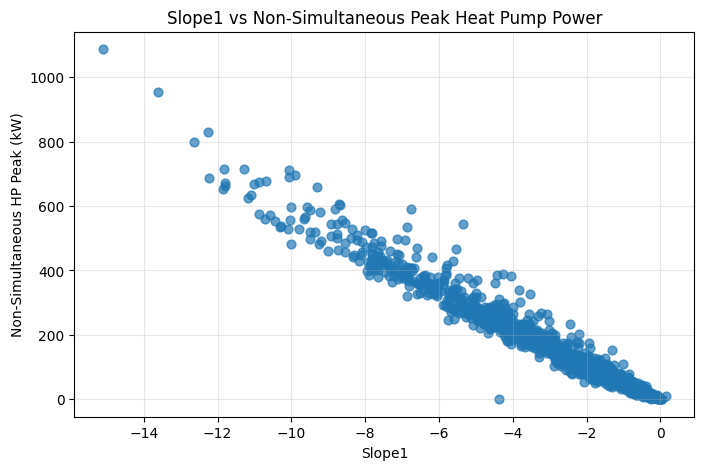

In [76]:
data_plot = piece_lin_coeff_sub_df[['Slope1']].join(substations_df_train['HP_Peak'], how='inner')

plt.figure(figsize=(8, 5))
plt.scatter(data_plot['Slope1'], data_plot['HP_Peak'], alpha=0.7, s=40)
plt.xlabel('Slope1')
plt.ylabel('Non-Simultaneous HP Peak (kW)')
plt.title('Slope1 vs Non-Simultaneous Peak Heat Pump Power')
plt.grid(alpha=0.3)
plt.show()

Training R²: 0.955
Test R²: 0.958
Test RMSE: 34.073 kW
Test MAPE: 16.68%
Linear model: HP_Peak = -59.560 * Slope1 + -10.704


c:\Users\VENANCIA\OneDrive - VITO\Desktop\NILM\.venv\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


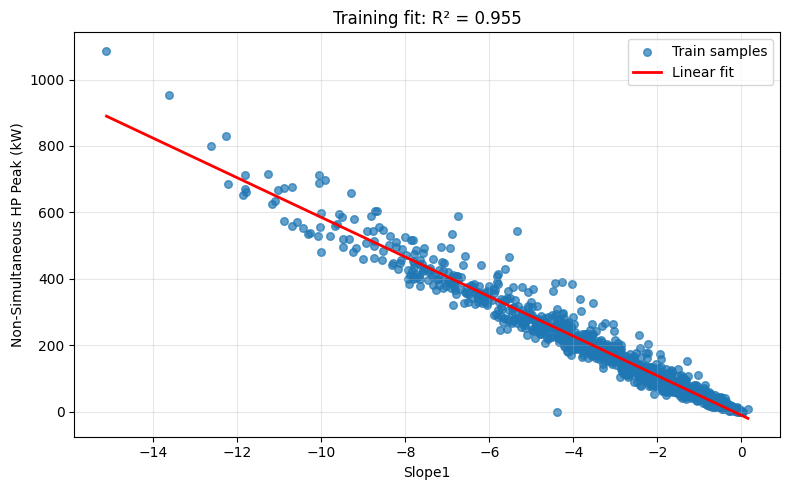

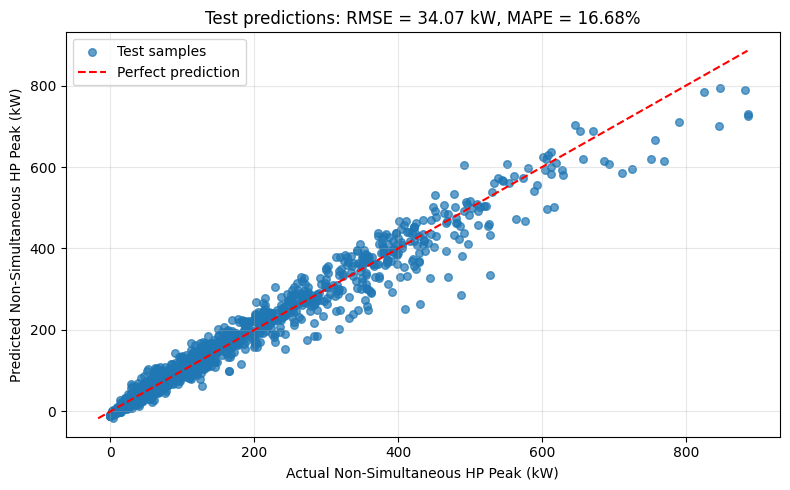

In [77]:
train_data = piece_lin_coeff_sub_df[['Slope1']].join(substations_df_train['HP_Peak'], how='inner').dropna()

model = LinearRegression()
model.fit(train_data[['Slope1']], train_data['HP_Peak'])

test_data = piece_lin_coeff_test_df[['Slope1']].join(substations_df_test['HP_Peak'], how='inner').dropna()
test_data['Predicted_HP_Peak'] = model.predict(test_data[['Slope1']])

r2_train = model.score(train_data[['Slope1']], train_data['HP_Peak'])
r2_test = r2_score(test_data['HP_Peak'], test_data['Predicted_HP_Peak'])
rmse_test = root_mean_squared_error(test_data['HP_Peak'], test_data['Predicted_HP_Peak'])
small_y_threshold = 10.0
mask = test_data['HP_Peak'].abs() > small_y_threshold
mape_test = mean_absolute_percentage_error(
    test_data.loc[mask, 'HP_Peak'],
    test_data.loc[mask, 'Predicted_HP_Peak']
) * 100

print(f"Training R²: {r2_train:.3f}")
print(f"Test R²: {r2_test:.3f}")
print(f"Test RMSE: {rmse_test:.3f} kW")
print(f"Test MAPE: {mape_test:.2f}%")
print(f"Linear model: HP_Peak = {model.coef_[0]:.3f} * Slope1 + {model.intercept_:.3f}")

# Plot training set in its own figure
fig_train, ax_train = plt.subplots(figsize=(8, 5))
ax_train.scatter(train_data['Slope1'], train_data['HP_Peak'], alpha=0.7, s=30, label='Train samples')
x_line = np.linspace(train_data['Slope1'].min(), train_data['Slope1'].max(), 100)
ax_train.plot(x_line, model.predict(x_line.reshape(-1, 1)), color='red', linewidth=2, label='Linear fit')
ax_train.set_xlabel('Slope1')
ax_train.set_ylabel('Non-Simultaneous HP Peak (kW)')
ax_train.set_title(f'Training fit: R² = {r2_train:.3f}')
ax_train.grid(alpha=0.3)
ax_train.legend()
fig_train.tight_layout()
plt.show()

# Plot test set in its own figure
min_val = min(test_data['HP_Peak'].min(), test_data['Predicted_HP_Peak'].min())
max_val = max(test_data['HP_Peak'].max(), test_data['Predicted_HP_Peak'].max())

fig_test, ax_test = plt.subplots(figsize=(8, 5))
ax_test.scatter(test_data['HP_Peak'], test_data['Predicted_HP_Peak'], alpha=0.7, s=30, label='Test samples')
ax_test.plot([min_val, max_val], [min_val, max_val], 'r--', label='Perfect prediction')
ax_test.set_xlabel('Actual Non-Simultaneous HP Peak (kW)')
ax_test.set_ylabel('Predicted Non-Simultaneous HP Peak (kW)')
ax_test.set_title(f'Test predictions: RMSE = {rmse_test:.2f} kW, MAPE = {mape_test:.2f}%')
ax_test.grid(alpha=0.3)
ax_test.legend()
fig_test.tight_layout()
plt.show()

### Fit piecewise function to time-of-day indexed data

In [30]:
piece_lin_coeff_hourly = {}
r2_score_hourly = {}
delta_breakpoint_slope_hourly = {}

for id in tqdm(substations_df_train.index, desc='Fitting piecewise linear functions for substations'):
    try:
        sm_data = pd.DataFrame({
            'Temperature': substations_df_train.loc[id, 'Temperature'].resample('h').mean(),
            'Total_Load': substations_df_train.loc[id, 'Total_Load'].resample('h').mean()
        }, index=substations_df_train.loc[id, 'Temperature'].resample('h').mean().index).dropna()

        sm_data['Date'] = sm_data.index.date
        sm_data['Time'] = sm_data.index.time

        sm_data_hourly_load = sm_data.pivot(index='Date', columns='Time', values='Total_Load').ffill()
        sm_data_hourly_temp = sm_data.pivot(index='Date', columns='Time', values='Temperature').ffill()

        piece_lin_coeff_hourly[id] = {}
        r2_score_hourly[id] = {}
        delta_breakpoint_slope_hourly[id] = {}

        for col in sm_data_hourly_load.columns:

            x = sm_data_hourly_temp[col].values
            y = sm_data_hourly_load[col].values

            plin = pwlf.PiecewiseLinFit(x, y)
            breakpoints = plin.fit(2)
            piece_lin_coeff_hourly[id][col.strftime("%H") + 'B0'] = breakpoints[0]
            piece_lin_coeff_hourly[id][col.strftime("%H") + 'B1'] = breakpoints[1]
            piece_lin_coeff_hourly[id][col.strftime("%H") + 'B2'] = breakpoints[2]
            piece_lin_coeff_hourly[id][col.strftime("%H") + 'S1'] = plin.slopes[0]
            piece_lin_coeff_hourly[id][col.strftime("%H") + 'S2'] = plin.slopes[1]
            r2_score_hourly[id][col] = plin.r_squared()

            delta_breakpoint_slope_hourly[id][col] = (breakpoints[0] - breakpoints[1]) * plin.slopes[0] + (breakpoints[1] - breakpoints[2]) * plin.slopes[1]

    except:
        pass

Fitting piecewise linear functions for substations: 100%|██████████| 1000/1000 [07:41<00:00,  2.17it/s]


In [31]:
piece_lin_coeff_hourly_df = pd.DataFrame.from_dict(piece_lin_coeff_hourly, orient='index')
piece_lin_coeff_hourly_df.index.name = 'Substation_ID'

r2_score_hourly_df = pd.DataFrame.from_dict(r2_score_hourly, orient='index')
r2_score_hourly_df.index.name = 'Substation_ID'

delta_breakpoint_slope_hourly_df = pd.DataFrame.from_dict(delta_breakpoint_slope_hourly, orient='index')
delta_breakpoint_slope_hourly_df.index.name = 'Substation_ID'

Text(0.5, 1.0, 'R2 Score Distribution by Hour')

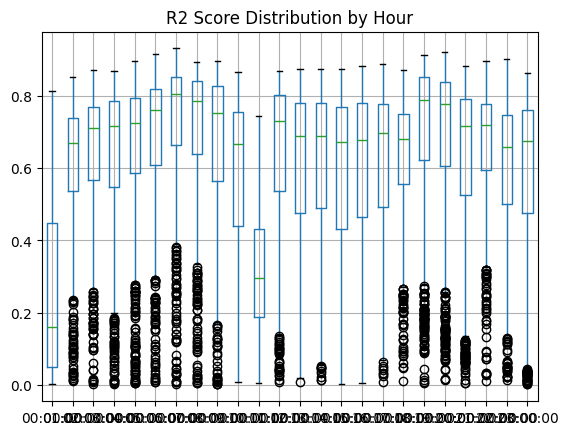

In [32]:
r2_score_hourly_df.boxplot()
plt.title('R2 Score Distribution by Hour')

Text(0.5, 1.0, 'Delta Breakpoint Slope Distribution by Hour')

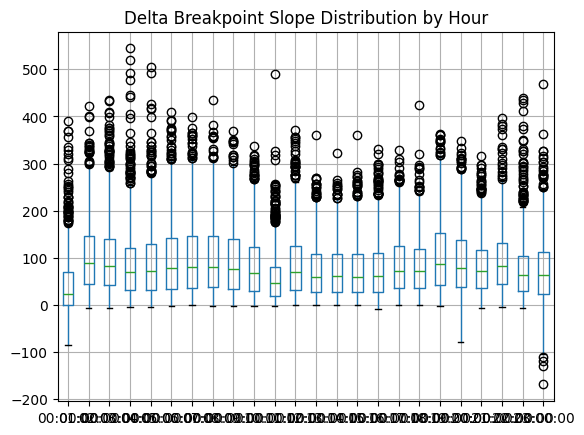

In [33]:
delta_breakpoint_slope_hourly_df.boxplot()
plt.title('Delta Breakpoint Slope Distribution by Hour')

In [34]:
# Assuming delta_breakpoint_slope_hourly_df and substations_df_train are available from previous cells
# Join the DataFrames on index
combined_df = delta_breakpoint_slope_hourly_df.join(substations_df_train['HP_Peak'])

# Compute correlation matrix
correlation_matrix = combined_df.corr()

# Extract correlations with HP_Peak
hp_peak_correlations = correlation_matrix['HP_Peak'].drop('HP_Peak')  # Drop self-correlation

# Display as a table
print("Correlation of delta_breakpoint_slope_hourly_df elements with HP_Peak:")
display(hp_peak_correlations.to_frame().T.style.background_gradient(cmap='RdYlGn', axis=1))

Correlation of delta_breakpoint_slope_hourly_df elements with HP_Peak:


,00:00:00,01:00:00,02:00:00,03:00:00,04:00:00,05:00:00,06:00:00,07:00:00,08:00:00,09:00:00,10:00:00,11:00:00,12:00:00,13:00:00,14:00:00,15:00:00,16:00:00,17:00:00,18:00:00,19:00:00,20:00:00,21:00:00,22:00:00,23:00:00
HP_Peak,0.808667,0.945853,0.920266,0.936505,0.963760,0.946405,0.958229,0.961743,0.928617,0.960586,0.879528,0.909808,0.949093,0.959694,0.956587,0.953580,0.931846,0.962632,0.941106,0.912708,0.947267,0.940989,0.913110,0.830780


### Feature Extraction

In [35]:
X_train = substations_df_train[[col for col in substations_df_train.columns if 'Feature' in col]]
y_train = substations_df_train[['HP_Peak']]

X_test = substations_df_test[[col for col in substations_df_test.columns if 'Feature' in col]]
y_test = substations_df_test[['HP_Peak']]

In [36]:
X_val = substations_val_df[[col for col in substations_val_df.columns if 'Feature' in col]]
y_val = substations_val_df[['HP_Peak']]

### Feature Plots

In [37]:
# for column in X_train.columns:
#     plt.figure()
#     plt.scatter(X_train[column], y_train['HP_Peak'], marker='o')
#     plt.xlabel(column)
#     plt.ylabel('Peak Heat Pump Load (kW)')
#     plt.title(f'Scatter plot of {column} vs Peak Heat Pump Load')
#     plt.show()

## Baseline (Peak Net Load = Simultaneous HP Peak Load)

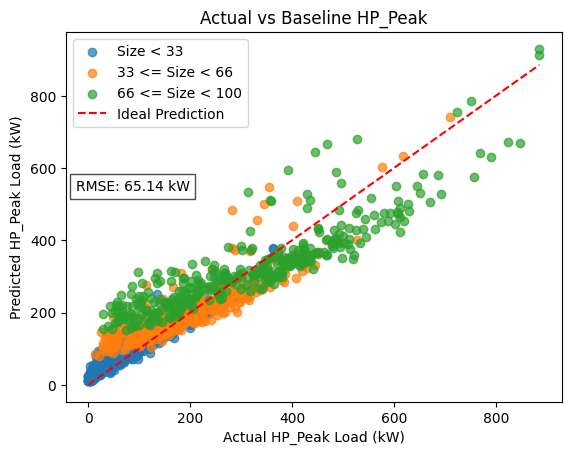

In [38]:
baseline_pred = X_test['Feature_Max_Max']
col = 'HP_Peak'

fig, ax = plt.subplots()
ax.scatter(y_test[substations_df_test['size'] < 33][col], baseline_pred[substations_df_test['size'] < 33], alpha=0.7)
ax.scatter(y_test[(substations_df_test['size'] >= 33) & (substations_df_test['size'] < 66)][col], baseline_pred[(substations_df_test['size'] >= 33) & (substations_df_test['size'] < 66)], alpha=0.7)
ax.scatter(y_test[(substations_df_test['size'] >= 66) & (substations_df_test['size'] < 100)][col], baseline_pred[(substations_df_test['size'] >= 66) & (substations_df_test['size'] < 100)], alpha=0.7)
ax.plot([y_test[col].min(), y_test[col].max()], [y_test[col].min(), y_test[col].max()], 'r--')
ax.set_xlabel(f'Actual {col} Load (kW)')
ax.set_ylabel(f'Predicted {col} Load (kW)')
ax.set_title(f'Actual vs Baseline {col}')
mape = mean_absolute_percentage_error(y_test[col].values, baseline_pred) * 100
rmse = root_mean_squared_error(y_test[col].values, baseline_pred)
ax.text(0.02, 0.6, f'RMSE: {rmse:.2f} kW', transform=ax.transAxes, va='top', bbox=dict(facecolor='white', alpha=0.7))
plt.legend(['Size < 33', '33 <= Size < 66', '66 <= Size < 100', 'Ideal Prediction'])
plt.show()

## Non-filtered

### XGBoost

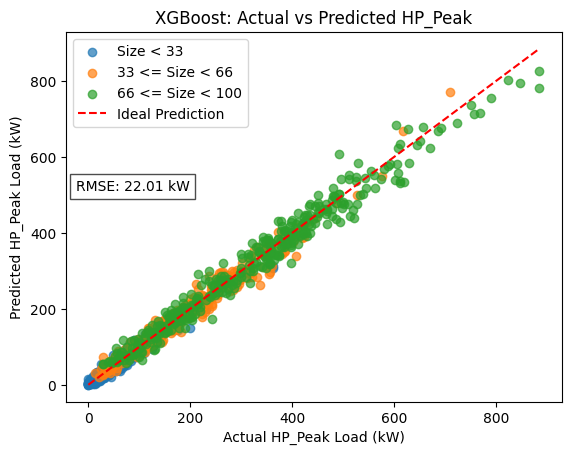

In [39]:
for col in y_train.columns:
    xgb_model = xgb.XGBRegressor()
    xgb_model.fit(X_train, y_train[col])

    xgb_pred = xgb_model.predict(X_test)

    xgb_pred = np.maximum(xgb_pred, 0) # ensure non-negative predictions

    fig, ax = plt.subplots()
    ax.scatter(y_test[substations_df_test['size'] < 33][col], xgb_pred[substations_df_test['size'] < 33], alpha=0.7)
    ax.scatter(y_test[(substations_df_test['size'] >= 33) & (substations_df_test['size'] < 66)][col], xgb_pred[(substations_df_test['size'] >= 33) & (substations_df_test['size'] < 66)], alpha=0.7)
    ax.scatter(y_test[(substations_df_test['size'] >= 66) & (substations_df_test['size'] < 100)][col], xgb_pred[(substations_df_test['size'] >= 66) & (substations_df_test['size'] < 100)], alpha=0.7)
    ax.plot([y_test[col].min(), y_test[col].max()], [y_test[col].min(), y_test[col].max()], 'r--')
    ax.set_xlabel(f'Actual {col} Load (kW)')
    ax.set_ylabel(f'Predicted {col} Load (kW)')
    ax.set_title(f'XGBoost: Actual vs Predicted {col}')
    mape = mean_absolute_percentage_error(y_test[col].values, xgb_pred) * 100
    rmse = root_mean_squared_error(y_test[col].values, xgb_pred)
    ax.text(0.02, 0.6, f'RMSE: {rmse:.2f} kW', transform=ax.transAxes, va='top', bbox=dict(facecolor='white', alpha=0.7))
    plt.legend(['Size < 33', '33 <= Size < 66', '66 <= Size < 100', 'Ideal Prediction'])
    plt.show()

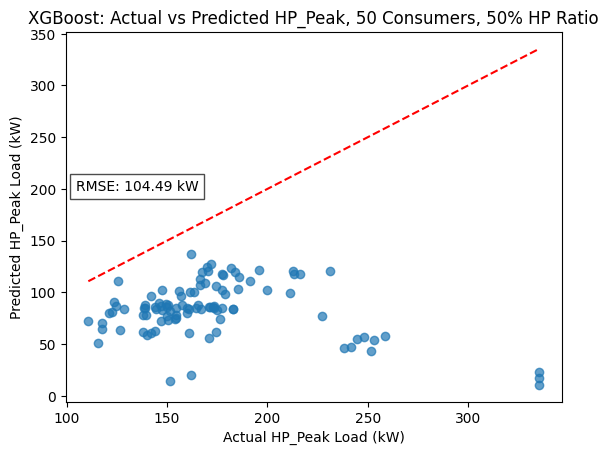

In [40]:
for col in y_train.columns:
    xgb_model = xgb.XGBRegressor()
    xgb_model.fit(X_train, y_train[col])

    xgb_pred = xgb_model.predict(X_val)

    xgb_pred = np.maximum(xgb_pred, 0) # ensure non-negative predictions

    fig, ax = plt.subplots()
    ax.scatter(y_val[col], xgb_pred, alpha=0.7)
    ax.plot([y_val[col].min(), y_val[col].max()], [y_val[col].min(), y_val[col].max()], 'r--')
    ax.set_xlabel(f'Actual {col} Load (kW)')
    ax.set_ylabel(f'Predicted {col} Load (kW)')
    ax.set_title(f'XGBoost: Actual vs Predicted {col}, 50 Consumers, 50% HP Ratio')
    rmse = root_mean_squared_error(y_val[col].values, xgb_pred)
    ax.text(0.02, 0.6, f'RMSE: {rmse:.2f} kW', transform=ax.transAxes, va='top', bbox=dict(facecolor='white', alpha=0.7))
    plt.show()

### Linear Regression

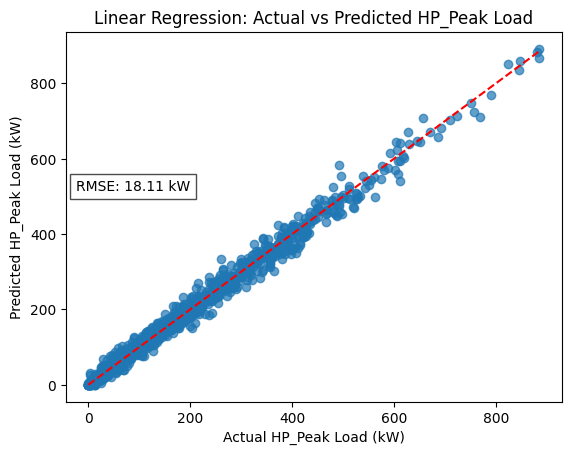

In [41]:
for col in y_train.columns:
    model = LinearRegression()
    model.fit(X_train, y_train[col])

    linreg_pred = model.predict(X_test)

    linreg_pred = np.maximum(linreg_pred, 0) # ensure no negative predictions

    fig, ax = plt.subplots()
    ax.scatter(y_test[col], linreg_pred, alpha=0.7)
    ax.plot([0, y_test[col].max()], [0, y_test[col].max()], 'r--')
    ax.set_xlabel(f'Actual {col} Load (kW)')
    ax.set_ylabel(f'Predicted {col} Load (kW)')
    ax.set_title(f'Linear Regression: Actual vs Predicted {col} Load')
    rmse = root_mean_squared_error(y_test[col].values, linreg_pred)
    ax.text(0.02, 0.6, f'RMSE: {rmse:.2f} kW', transform=ax.transAxes, va='top', bbox=dict(facecolor='white', alpha=0.7))
    plt.show()

## Temperature Filtered

In [42]:
substations_filt = {}

threshold_temp = 15  # degreesC

for i in range(len(substations_df)):

    loadDict = {
        'Total_Load': substations_df.iloc[i]['Total_Load'].values,
        'Date': substations_df.iloc[i]['Total_Load'].index.date,
        'Time': substations_df.iloc[i]['Total_Load'].index.time
    }

    weather_dict = {
        'Temperature': substations_df.iloc[i]['Temperature'].values,
        'Date': substations_df.iloc[i]['Temperature'].index.date,
        'Time': substations_df.iloc[i]['Temperature'].index.time
    }

    loadDf = pd.DataFrame(loadDict, columns=['Total_Load', 'Date', 'Time'])

    weatherDf = pd.DataFrame(weather_dict, columns=['Temperature', 'Date', 'Time'])

    dailyLoad = loadDf.pivot(index='Date', columns='Time', values='Total_Load').ffill()

    dailyWeather = weatherDf.pivot(index='Date', columns='Time', values='Temperature').ffill()
    dailyWeather = dailyWeather[dailyWeather.index.isin(dailyLoad.index)]

    tempMask = (dailyWeather.mean(axis=1) < threshold_temp)  # example: filter days with average temperature below 15 degreesC

    dailyLoadCold = dailyLoad[tempMask]
    dailyWeather = dailyWeather[tempMask]

    dailyFeatures = {}
    dailyFeatures['Mean'] = dailyLoadCold.mean(axis=1)
    dailyFeatures['Std'] = dailyLoadCold.std(axis=1)
    dailyFeatures['Min'] = dailyLoadCold.min(axis=1)
    dailyFeatures['Max'] = dailyLoadCold.max(axis=1)
    dailyFeatures['Skew'] = dailyLoadCold.skew(axis=1)
    dailyFeatures['Kurtosis'] = dailyLoadCold.kurtosis(axis=1)
    dailyFeatures['Max-Min'] = dailyLoadCold.max(axis=1) - dailyLoadCold.min(axis=1)
    dailyFeatures['Cov'] = np.array([np.cov(dailyLoadCold.iloc[i], dailyWeather.iloc[i])[0][1] 
                                            for i in range(len(dailyLoadCold))])
    dailyFeatures['Corr_Pearson'] = pearsonr(x=dailyLoadCold, y=dailyWeather, axis=1).statistic
    dailyFeaturesDf = pd.DataFrame(dailyFeatures)

    features = {}
    features['Mean'] = dailyFeaturesDf.mean()
    features['Std'] = dailyFeaturesDf.std()
    features['Min'] = dailyFeaturesDf.min()
    features['Max'] = dailyFeaturesDf.max()
    features['Median'] = dailyFeaturesDf.median()

    substations_filt[i] = {}
    for key_main in features.keys():
        for key_sub in features[key_main].index:
            substations_filt[i][f'Feature_{key_main}_{key_sub}'] = features[key_main][key_sub]

substations_filt_df = pd.DataFrame.from_dict(substations_filt, orient='index')
pickle.dump(substations_filt_df, open('data/substations_filt_data.pkl', 'wb'))

In [43]:
substations_filt_df = pickle.load(open('data/substations_filt_data.pkl', 'rb'))
substations_filt_df = substations_filt_df.fillna(0)
substations_filt_df_train, substations_filt_df_test = train_test_split(substations_filt_df, test_size=0.5, random_state=42)

X_train_filt = substations_filt_df_train[[col for col in substations_filt_df_train.columns if 'Feature' in col]]
y_train_filt = substations_df_train[['HP_Peak']]

X_test_filt = substations_filt_df_test[[col for col in substations_filt_df_test.columns if 'Feature' in col]]
y_test_filt = substations_df_test[['HP_Peak']]

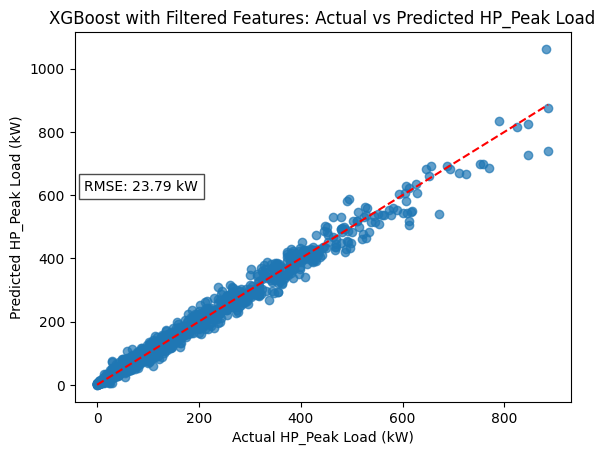

In [44]:
for col in y_train_filt.columns:
    model = xgb.XGBRegressor()
    model.fit(X_train_filt, y_train_filt[col])
    
    xgb_pred_filt = model.predict(X_test_filt)
    xgb_pred_filt = np.maximum(xgb_pred_filt, 0) # ensure non-negative predictions

    fig, ax = plt.subplots()
    ax.scatter(y_test_filt[col], xgb_pred_filt, alpha=0.7)
    ax.plot([y_test_filt[col].min(), y_test_filt[col].max()], [y_test_filt[col].min(), y_test_filt[col].max()], 'r--')
    ax.set_xlabel(f'Actual {col} Load (kW)')
    ax.set_ylabel(f'Predicted {col} Load (kW)')
    ax.set_title(f'XGBoost with Filtered Features: Actual vs Predicted {col} Load')
    rmse = root_mean_squared_error(y_test_filt[col].values, xgb_pred_filt)
    ax.text(0.02, 0.6, f'RMSE: {rmse:.2f} kW', transform=ax.transAxes, va='top', bbox=dict(facecolor='white', alpha=0.7))
    plt.show()


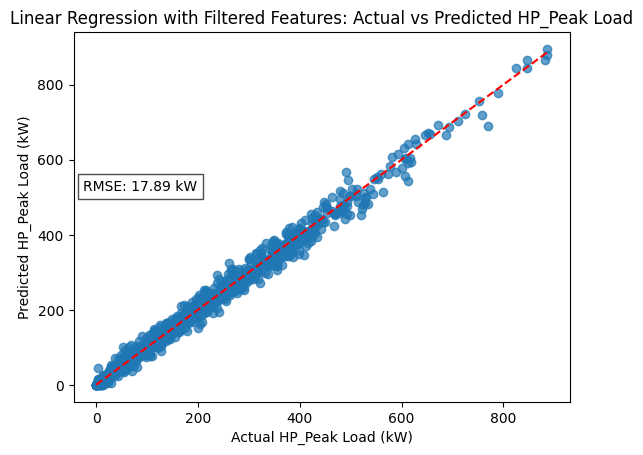

In [45]:
for col in y_train_filt.columns:
    model = LinearRegression()
    model.fit(X_train_filt, y_train_filt[col])

    linreg_pred_filt = model.predict(X_test_filt)

    linreg_pred_filt = np.maximum(linreg_pred_filt, 0) # ensure no negative predictions

    fig, ax = plt.subplots()
    ax.scatter(y_test_filt[col], linreg_pred_filt, alpha=0.7)
    ax.plot([0, y_test_filt[col].max()], [0, y_test_filt[col].max()], 'r--')
    ax.set_xlabel(f'Actual {col} Load (kW)')
    ax.set_ylabel(f'Predicted {col} Load (kW)')
    ax.set_title(f'Linear Regression with Filtered Features: Actual vs Predicted {col} Load')
    rmse = root_mean_squared_error(y_test_filt[col].values, linreg_pred_filt)
    ax.text(0.02, 0.6, f'RMSE: {rmse:.2f} kW', transform=ax.transAxes, va='top', bbox=dict(facecolor='white', alpha=0.7))
    plt.show()

## Time Based Features

In [46]:
substations_time = {}

resolution = 15  # in minutes

for i in range(len(substations_df)):

    sub_df = substations_df.iloc[i]['Total_Load'].resample(f'{resolution}min').mean().ffill()
    weather_df = substations_df.iloc[i]['Temperature'].resample(f'{resolution}min').mean().ffill()

    loadDict = {
        'Total_Load': sub_df.values,
        'Date': sub_df.index.date,
        'Time': sub_df.index.time
    }

    weatherDict = {
        'Temperature': weather_df.values,
        'Date': weather_df.index.date,
        'Time': weather_df.index.time
    }

    loadDf = pd.DataFrame(loadDict, columns=['Total_Load', 'Date', 'Time'])

    weather_data = pd.DataFrame(weatherDict, columns=['Temperature', 'Date', 'Time'])

    dailyLoad = loadDf.pivot(index='Date', columns='Time', values='Total_Load').ffill()
    dailyWeather = weather_data.pivot(index='Date', columns='Time', values='Temperature').ffill()
    dailyWeather = dailyWeather[dailyWeather.index.isin(dailyLoad.index)]

    dailyFeatures = {}
    dailyFeatures['Mean'] = dailyLoad.mean(axis=0)
    dailyFeatures['Std'] = dailyLoad.std(axis=0)
    dailyFeatures['Min'] = dailyLoad.min(axis=0)
    dailyFeatures['Max'] = dailyLoad.max(axis=0)
    dailyFeatures['Skew'] = dailyLoad.skew(axis=0)
    dailyFeatures['Kurtosis'] = dailyLoad.kurtosis(axis=0)
    dailyFeatures['Max-Min'] = dailyLoad.max(axis=0) - dailyLoad.min(axis=0)
    dailyFeatures['Cov'] = np.array([np.cov(dailyLoad.iloc[:,i], dailyWeather.iloc[:,i])[0][1] 
                                            for i in range(dailyLoad.shape[1])])
    dailyFeatures['Corr_Pearson'] = pearsonr(x=dailyLoad, y=dailyWeather, axis=0).statistic

    dailyFeaturesDf = pd.DataFrame(dailyFeatures)
    
    # features = {}
    # features['Mean'] = dailyFeaturesDf.mean()
    # features['Std'] = dailyFeaturesDf.std()
    # features['Min'] = dailyFeaturesDf.min()
    # features['Max'] = dailyFeaturesDf.max()
    # features['Median'] = dailyFeaturesDf.median()

    substations_time[i] = {}
    # for key_main in features.keys():
    #     for key_sub in features[key_main].index:
    #         substations_time[i][f'Feature_{key_main}_{key_sub}'] = features[key_main][key_sub]

    for key_main in dailyFeaturesDf.keys():
        for key_sub in dailyFeaturesDf.index:
            substations_time[i][f'Feature {key_main}_{key_sub}'] = dailyFeaturesDf[key_main][key_sub]

substations_time_df = pd.DataFrame.from_dict(substations_time, orient='index')
pickle.dump(substations_time_df, open('data/substations_time_data.pkl', 'wb'))

In [47]:
substations_time_df = pickle.load(open('data/substations_time_data.pkl', 'rb'))
substations_time_df = substations_time_df.fillna(0)
substations_time_df_train, substations_time_df_test = train_test_split(substations_time_df, test_size=0.5, random_state=42)

X_train_time = substations_time_df_train
y_train_time = substations_df_train[['HP_Peak']]

X_test_time = substations_time_df_test
y_test_time = substations_df_test[['HP_Peak']]

In [48]:
def objectiveMC(space):
    reg=xgb.XGBRegressor(learning_rate = space['eta'], n_estimators = int(space['n_estimators']), max_depth = int(space['max_depth']), gamma = space['gamma'],
                        subsample = space['subsample'], reg_alpha = space['reg_alpha'], reg_lambda = space['reg_lambda'], 
                        min_child_weight = int(space['min_child_weight']), colsample_bytree = space['colsample_bytree'], eval_metric = "mae")
    
    accuracy = -np.mean(cross_val_score(reg, X_train_time, y_train_time, scoring='neg_mean_squared_error', cv=5))
    
    
    return {'loss': accuracy, 'status': STATUS_OK }
    

def tune_and_train_xgb(XIrrTrain_MC, yIrrTrain_MC):
    space={ 'eta': hp.uniform('eta', 0, 1),                                     # Learning Rate
        'max_depth': hp.quniform("max_depth", 3, 18, 1),                        # Maximum Tree depth
        'gamma': hp.quniform ('gamma', 0, 100, 1),                                  # Pruning parameter (node gain < gamma -> Prune)
        'subsample': hp.uniform('subsample', 0, 1),                             # Fraction of observations to be randomly sampled for each tree
        'reg_alpha' : hp.uniform('reg_alpha', 0, 1),                            # L1-norm (Lasso) Regularization 
        'reg_lambda' : hp.quniform('reg_lambda', 0, 100, 1),                        # L2-norm (Ridge) Regularization 
        'colsample_bytree' : hp.uniform('colsample_bytree', 0.1, 1),            # Ratio of randomly sampled features to use for each tree
        'min_child_weight' : hp.quniform('min_child_weight', 0, 100, 1),        # Minimum sum of weights of all observations required in a child (in regression: weight = 1)
        'n_estimators': hp.quniform('n_estimators', 50, 1000, 10),               # Number of trees
    }

    trials = Trials()

    start_time_ht = time.time()
    best_hyperparams_MC = fmin(fn = objectiveMC,
                            space = space,
                            algo = tpe.suggest,
                            max_evals = 1000,
                            trials = trials)
    end_time_ht = time.time()
    print("Hyperparameter tuning took " + str(end_time_ht - start_time_ht) + " seconds")

    xgb_model_MC = xgb.XGBRegressor(
        learning_rate=best_hyperparams_MC['eta'],
        n_estimators=int(best_hyperparams_MC['n_estimators']),
        max_depth=int(best_hyperparams_MC['max_depth']),
        gamma=best_hyperparams_MC['gamma'],
        subsample=best_hyperparams_MC['subsample'],
        reg_alpha=best_hyperparams_MC['reg_alpha'],
        reg_lambda=best_hyperparams_MC['reg_lambda'],
        min_child_weight=int(best_hyperparams_MC['min_child_weight']),
        colsample_bytree=best_hyperparams_MC['colsample_bytree'],
        eval_metric="mae"
    )

    start_time_fit = time.time()
    xgb_model_MC.fit(XIrrTrain_MC, yIrrTrain_MC)
    end_time_fit = time.time()
    
    print("Fitting took " + str(end_time_fit - start_time_fit) + " seconds")
    return xgb_model_MC, best_hyperparams_MC

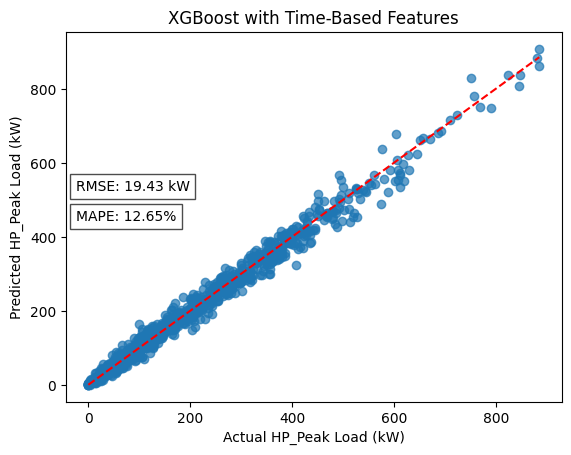

In [81]:
col = 'HP_Peak'

model = xgb.XGBRegressor()
model.fit(X_train_time, y_train_time[col])

xgb_pred_time = model.predict(X_test_time)
xgb_pred_time = np.maximum(xgb_pred_time, 0) # ensure non-negative predictions

fig, ax = plt.subplots()
ax.scatter(y_test_time[col], xgb_pred_time, alpha=0.7)
ax.plot([y_test_time[col].min(), y_test_time[col].max()], [y_test_time[col].min(), y_test_time[col].max()], 'r--')
ax.set_xlabel(f'Actual {col} Load (kW)')
ax.set_ylabel(f'Predicted {col} Load (kW)')
ax.set_title(f'XGBoost with Time-Based Features')
mask = y_test_time[col].values != 0
if mask.sum() > 0:
    mape = mean_absolute_percentage_error(y_test_time[col].values[mask], xgb_pred_time[mask]) * 100
    ax.text(0.02, 0.52, f'MAPE: {mape:.2f}%', transform=ax.transAxes, va='top', bbox=dict(facecolor='white', alpha=0.7))
else:
    ax.text(0.02, 0.52, 'MAPE: N/A', transform=ax.transAxes, va='top', bbox=dict(facecolor='white', alpha=0.7))
rmse = root_mean_squared_error(y_test_time[col].values, xgb_pred_time)
ax.text(0.02, 0.6, f'RMSE: {rmse:.2f} kW', transform=ax.transAxes, va='top', bbox=dict(facecolor='white', alpha=0.7))
plt.show()

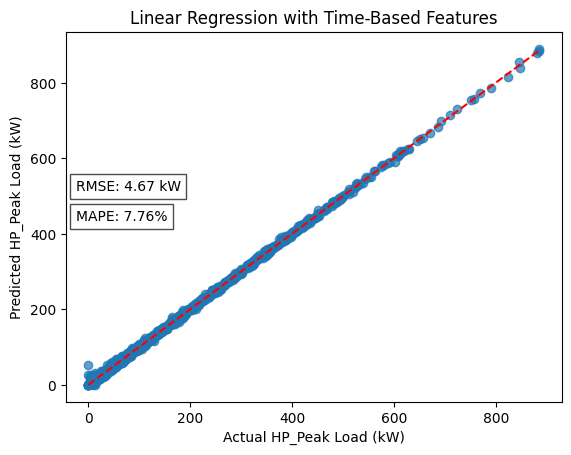

In [82]:
col = 'HP_Peak'

model = LinearRegression()
model.fit(X_train_time, y_train_time[col])
linreg_pred_time = model.predict(X_test_time)
linreg_pred_time = np.maximum(linreg_pred_time, 0) # ensure no negative predictions

fig, ax = plt.subplots()
ax.scatter(y_test_time[col], linreg_pred_time, alpha=0.7)
ax.plot([0, y_test_time[col].max()], [0, y_test_time[col].max()], 'r--')
ax.set_xlabel(f'Actual {col} Load (kW)')
ax.set_ylabel(f'Predicted {col} Load (kW)')
ax.set_title(f'Linear Regression with Time-Based Features')
mask = y_test_time[col].values != 0
if mask.sum() > 0:
    mape = mean_absolute_percentage_error(y_test_time[col].values[mask], linreg_pred_time[mask]) * 100
    ax.text(0.02, 0.52, f'MAPE: {mape:.2f}%', transform=ax.transAxes, va='top', bbox=dict(facecolor='white', alpha=0.7))
else:
    ax.text(0.02, 0.52, 'MAPE: N/A', transform=ax.transAxes, va='top', bbox=dict(facecolor='white', alpha=0.7))
rmse = root_mean_squared_error(y_test_time[col].values, linreg_pred_time)
ax.text(0.02, 0.6, f'RMSE: {rmse:.2f} kW', transform=ax.transAxes, va='top', bbox=dict(facecolor='white', alpha=0.7))
plt.show()

## HP Capacity From Annual Energy Estimation (Linear Regression, Full Time-based Statistical Distribution Features)

In [51]:
y_train_time['HP_Total_Energy'] = [substations_df_train['HP_Load'].iloc[i].sum() * 0.25 for i in range(len(substations_df_train))]
y_test_time['HP_Total_Energy'] = [substations_df_test['HP_Load'].iloc[i].sum() * 0.25 for i in range(len(substations_df_test))]

model = LinearRegression()
model.fit(X_train_time, y_train_time['HP_Total_Energy'])
linreg_pred_time = model.predict(X_test_time)
linreg_pred_time = np.maximum(linreg_pred_time, 0) # ensure no negative predictions

threshold_temps = [12.5, 15, 17.5, 20]  # degreesC

hybrid_preds = {}

resolution = 15  # in minutes
deltaT = resolution / 60  # convert minutes to hours

for threshold_temp in threshold_temps:
    hybrid_preds[threshold_temp] = []
    for i in range(len(substations_df_test)):
        
        temperature = substations_df_test.iloc[i]['Temperature']
        temperature = temperature.resample(f'{resolution}min').mean().ffill().values

        normalised_temp = (threshold_temp - temperature) / (threshold_temp - temperature.min())
        normalised_temp = np.clip(normalised_temp, 0, 1)

        hybrid_pred = linreg_pred_time[i] / (normalised_temp.sum() * deltaT)
        hybrid_preds[threshold_temp].append(hybrid_pred)
    
    hybrid_preds[threshold_temp] = np.array(hybrid_preds[threshold_temp])


C:\Users\VENANCIA\AppData\Local\Temp\ipykernel_52360\1458191917.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  y_train_time['HP_Total_Energy'] = [substations_df_train['HP_Load'].iloc[i].sum() * 0.25 for i in range(len(substations_df_train))]
C:\Users\VENANCIA\AppData\Local\Temp\ipykernel_52360\1458191917.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  y_test_time['HP_Total_Energy'] = [substations_df_test['HP_Load'].iloc[i].sum() * 0.25 for i in range(len(substations_df_test))]


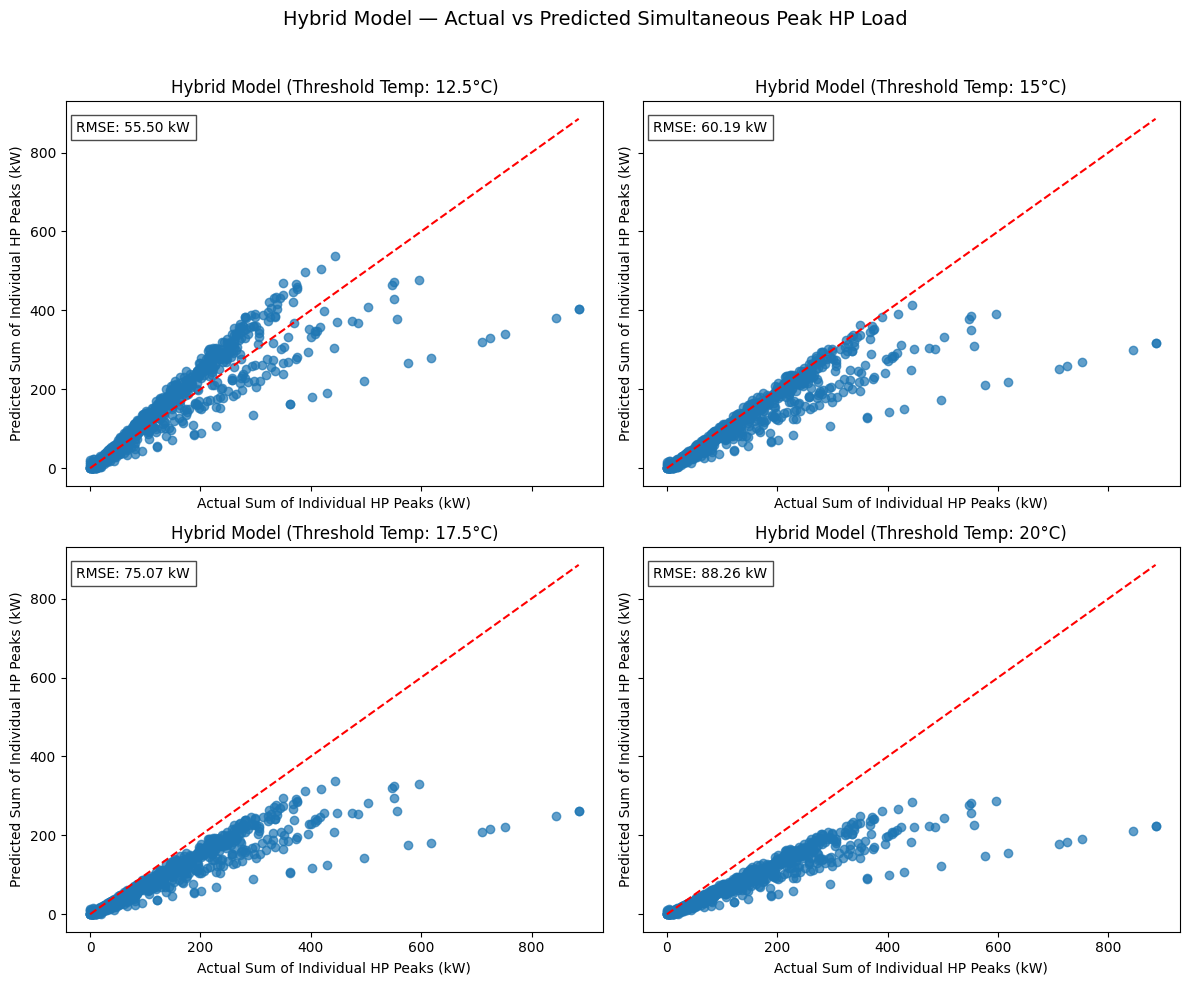

In [52]:
from math import ceil

temps = threshold_temps
n = len(temps)
cols = 2
rows = ceil(n / cols)

fig, axs = plt.subplots(rows, cols, figsize=(12, 5 * rows), sharex=True, sharey=True)
axs = axs.flatten()

# y_true = y_test_time['HP_Peak'].values

y_true = np.array([substations_df_test['HP_Load'].iloc[i].max() for i in range(len(substations_df_test))])
all_preds = np.concatenate([hybrid_preds[t] for t in temps])
vmin = y_true.min()
vmax = y_true.max()

for i, temp in enumerate(temps):
    ax = axs[i]
    preds = hybrid_preds[temp]
    ax.scatter(y_true, preds, alpha=0.7)
    ax.plot([vmin, vmax], [vmin, vmax], 'r--')
    ax.set_xlabel('Actual Sum of Individual HP Peaks (kW)')
    ax.set_ylabel('Predicted Sum of Individual HP Peaks (kW)')
    ax.set_title(f'Hybrid Model (Threshold Temp: {temp}°C)')
    rmse = root_mean_squared_error(y_true, preds)
    ax.text(0.02, 0.95, f'RMSE: {rmse:.2f} kW', transform=ax.transAxes, va='top', bbox=dict(facecolor='white', alpha=0.7))

# remove any unused subplots
for j in range(i + 1, rows * cols):
    fig.delaxes(axs[j])

fig.suptitle('Hybrid Model — Actual vs Predicted Simultaneous Peak HP Load', fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

### Hybrid with Piecewise Breakpoint as Threshold Temp.

In [53]:
y_train_time['HP_Total_Energy'] = [substations_df_train['HP_Load'].iloc[i].sum() * 0.25 for i in range(len(substations_df_train))]
y_test_time['HP_Total_Energy'] = [substations_df_test['HP_Load'].iloc[i].sum() * 0.25 for i in range(len(substations_df_test))]

model = LinearRegression()
model.fit(X_train_time, y_train_time['HP_Total_Energy'])
linreg_pred_time = model.predict(X_test_time)
linreg_pred_time = np.maximum(linreg_pred_time, 0) # ensure no negative predictions


hybrid_preds_pw = []

resolution = 60  # in minutes
deltaT = resolution / 60  # convert minutes to hours


for i in range(len(substations_df_test)):
    
    temperature = substations_df_test.iloc[i]['Temperature']
    temperature = temperature.resample(f'{resolution}min').mean().ffill().values

    threshold_temp = piece_lin_coeff_test_df['Breakpoint1'].iloc[i]  # using the Middle breakpoint as the threshold temperature

    normalised_temp = (threshold_temp - temperature) / (threshold_temp - temperature.min())
    normalised_temp = np.clip(normalised_temp, 0, 1)

    hybrid_pred = linreg_pred_time[i] / (normalised_temp.sum() * deltaT)
    hybrid_preds_pw.append(hybrid_pred)

hybrid_preds_pw = np.array(hybrid_preds_pw)

C:\Users\VENANCIA\AppData\Local\Temp\ipykernel_52360\93841307.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  y_train_time['HP_Total_Energy'] = [substations_df_train['HP_Load'].iloc[i].sum() * 0.25 for i in range(len(substations_df_train))]
C:\Users\VENANCIA\AppData\Local\Temp\ipykernel_52360\93841307.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  y_test_time['HP_Total_Energy'] = [substations_df_test['HP_Load'].iloc[i].sum() * 0.25 for i in range(len(substations_df_test))]


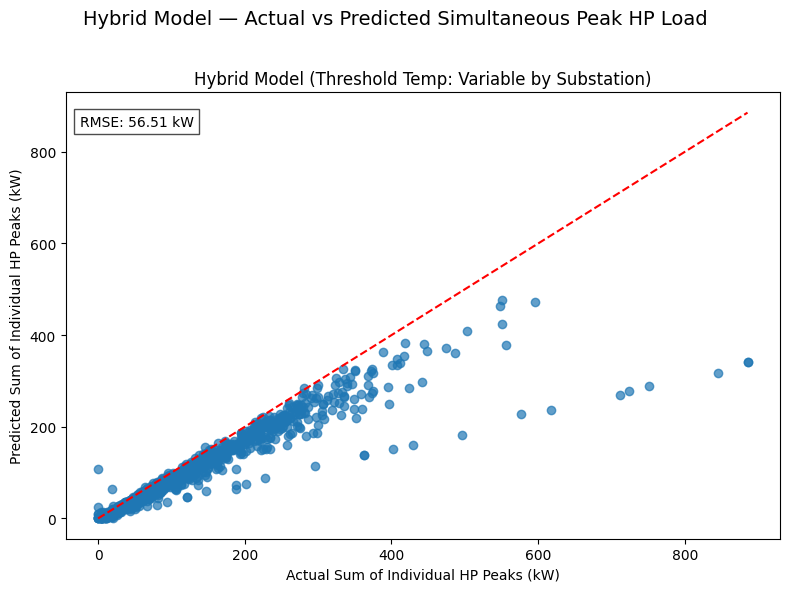

In [54]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111)


# y_true = y_test_time['HP_Peak'].values

y_true = np.array([substations_df_test['HP_Load'].iloc[i].max() for i in range(len(substations_df_test))])

vmin = y_true.min()
vmax = y_true.max()

preds = hybrid_preds_pw  # example scaling factor to adjust predictions to be in the same range as true values

ax.scatter(y_true, preds, alpha=0.7)
ax.plot([vmin, vmax], [vmin, vmax], 'r--')
ax.set_xlabel('Actual Sum of Individual HP Peaks (kW)')
ax.set_ylabel('Predicted Sum of Individual HP Peaks (kW)')
ax.set_title(f'Hybrid Model (Threshold Temp: Variable by Substation)')
rmse = root_mean_squared_error(y_true, preds)
ax.text(0.02, 0.95, f'RMSE: {rmse:.2f} kW', transform=ax.transAxes, va='top', bbox=dict(facecolor='white', alpha=0.7))

fig.suptitle('Hybrid Model — Actual vs Predicted Simultaneous Peak HP Load', fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

## PCA

### Time Series

Evaluating PCA components:  31%|███       | 154/499 [05:17<11:52,  2.06s/it]

RMSE below threshold at n_components=310, stopping early.
Best n_components: 310 with RMSE: 0.10 kW


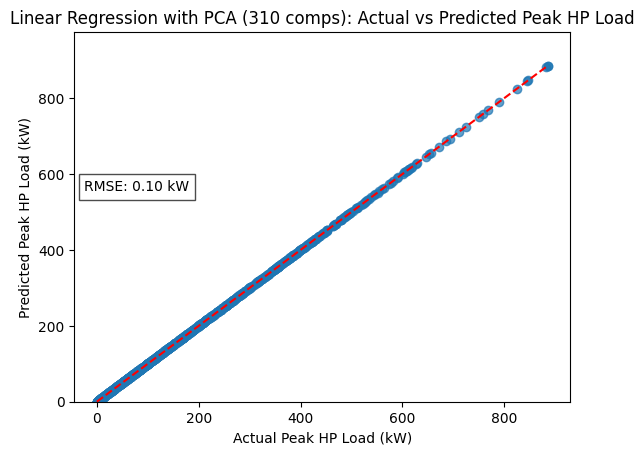

In [55]:
results_timeseries = {}
model = LinearRegression()

total_loads_train = {}
total_loads_test = {}


for i in range(len(substations_df_train)):
    total_loads_train[i] = substations_df_train.iloc[i]['Total_Load'].values

total_loads_train_df = pd.DataFrame.from_dict(total_loads_train, orient='index').ffill(axis=1)

for i in range(len(substations_df_test)):
    total_loads_test[i] = substations_df_test.iloc[i]['Total_Load'].values

total_loads_test_df = pd.DataFrame.from_dict(total_loads_test, orient='index').ffill(axis=1)

for n_comp in trange(2, 1000, 2, desc='Evaluating PCA components'):
    pca = PCA(n_components=n_comp)
    X_train_pca = pca.fit_transform(total_loads_train_df)
    X_test_pca = pca.transform(total_loads_test_df)

    model.fit(X_train_pca, y_train_time['HP_Peak'])
    lin_pred_pca = model.predict(X_test_pca)
    lin_pred_pca = np.maximum(lin_pred_pca, 0) # ensure non-negative predictions

    rmse = root_mean_squared_error(y_test_time['HP_Peak'].values, lin_pred_pca)
    results_timeseries[n_comp] = rmse

    if rmse < 0.1:  # arbitrary threshold for "good enough" performance to stop early
        print(f'RMSE below threshold at n_components={n_comp}, stopping early.')
        break

best_pred_pca = min(results_timeseries, key=results_timeseries.get)
print(f'Best n_components: {best_pred_pca} with RMSE: {results_timeseries[best_pred_pca]:.2f} kW')

pca = PCA(n_components=best_pred_pca)
X_train_pca = pca.fit_transform(total_loads_train_df)
X_test_pca = pca.transform(total_loads_test_df)

model.fit(X_train_pca, y_train_time['HP_Peak'])
lin_pred_pca = model.predict(X_test_pca)
lin_pred_pca = np.maximum(lin_pred_pca, 0) # ensure non-negative predictions

fig, ax = plt.subplots()
ax.scatter(y_test_time['HP_Peak'], lin_pred_pca, alpha=0.7)
ax.plot([y_test_time['HP_Peak'].min(), y_test_time['HP_Peak'].max()], [y_test_time['HP_Peak'].min(), y_test_time['HP_Peak'].max()], 'r--')
ax.set_xlabel('Actual Peak HP Load (kW)')
ax.set_ylabel('Predicted Peak HP Load (kW)')
ax.set_title(f'Linear Regression with PCA ({best_pred_pca} comps): Actual vs Predicted Peak HP Load')
rmse = root_mean_squared_error(y_test_time['HP_Peak'].values, lin_pred_pca)
ax.text(0.02, 0.6, f'RMSE: {rmse:.2f} kW', transform=ax.transAxes, va='top', bbox=dict(facecolor='white', alpha=0.7))
ax.set_ylim([0, y_test_time['HP_Peak'].max() * 1.1])
plt.show() 

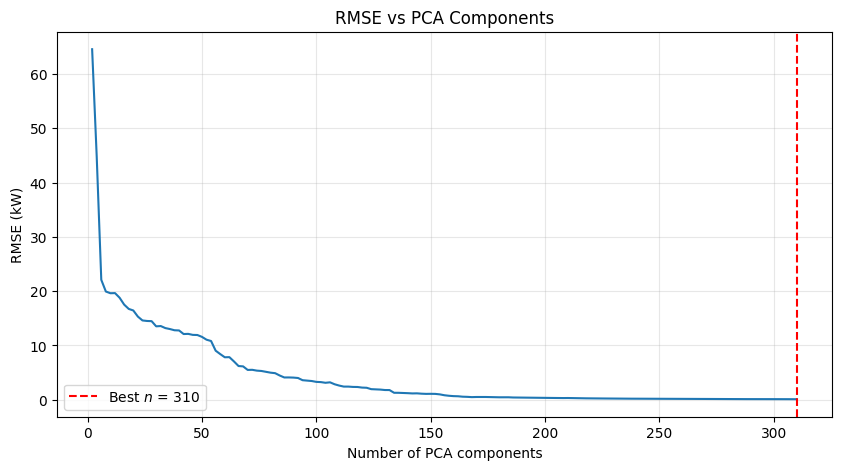

In [56]:
rmse_dict = results_timeseries

x = np.array(sorted(rmse_dict.keys()))
y = np.array([rmse_dict[k] for k in x])

plt.figure(figsize=(10, 5))
plt.plot(x, y, marker=' ', linestyle='-', color='tab:blue')
plt.xlabel('Number of PCA components')
plt.ylabel('RMSE (kW)')
plt.title('RMSE vs PCA Components')
plt.grid(alpha=0.3)

if 'best_pred_pca' in globals():
    plt.axvline(best_pred_pca, color='red', linestyle='--', label=f'Best $n$ = {best_pred_pca}')
    plt.legend()

plt.show()

### Features

Evaluating PCA components: 100%|██████████| 432/432 [02:31<00:00,  2.86it/s]


Best n_components: 628 with RMSE: 3.53 kW


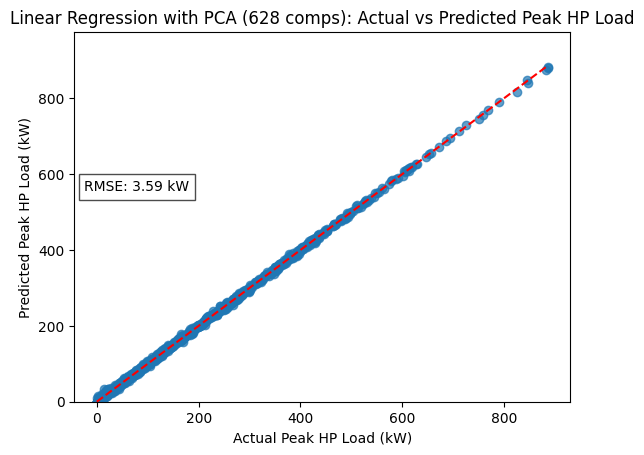

In [57]:
results_features = {}
model = LinearRegression()

for n_comp in trange(2, X_train_time.shape[1] + 1, 2, desc='Evaluating PCA components'):
    pca = PCA(n_components=n_comp)
    X_train_pca = pca.fit_transform(X_train_time)
    X_test_pca = pca.transform(X_test_time)
    
    model.fit(X_train_pca, y_train_time['HP_Peak'])
    lin_pred_pca = model.predict(X_test_pca)
    lin_pred_pca = np.maximum(lin_pred_pca, 0) # ensure non-negative predictions

    rmse = root_mean_squared_error(y_test_time['HP_Peak'].values, lin_pred_pca)
    results_features[n_comp] = rmse

best_pred_pca = min(results_features, key=results_features.get)
print(f'Best n_components: {best_pred_pca} with RMSE: {results_features[best_pred_pca]:.2f} kW')

pca = PCA(n_components=best_pred_pca)
X_train_pca = pca.fit_transform(X_train_time)
X_test_pca = pca.transform(X_test_time)

model.fit(X_train_pca, y_train_time['HP_Peak'])
lin_pred_pca = model.predict(X_test_pca)
lin_pred_pca = np.maximum(lin_pred_pca, 0) # ensure non-negative predictions

fig, ax = plt.subplots()
ax.scatter(y_test_time['HP_Peak'], lin_pred_pca, alpha=0.7)
ax.plot([y_test_time['HP_Peak'].min(), y_test_time['HP_Peak'].max()], [y_test_time['HP_Peak'].min(), y_test_time['HP_Peak'].max()], 'r--')
ax.set_xlabel('Actual Peak HP Load (kW)')
ax.set_ylabel('Predicted Peak HP Load (kW)')
ax.set_title(f'Linear Regression with PCA ({best_pred_pca} comps): Actual vs Predicted Peak HP Load')
rmse = root_mean_squared_error(y_test_time['HP_Peak'].values, lin_pred_pca)
ax.text(0.02, 0.6, f'RMSE: {rmse:.2f} kW', transform=ax.transAxes, va='top', bbox=dict(facecolor='white', alpha=0.7))
ax.set_ylim([0, y_test_time['HP_Peak'].max() * 1.1])
plt.show() 

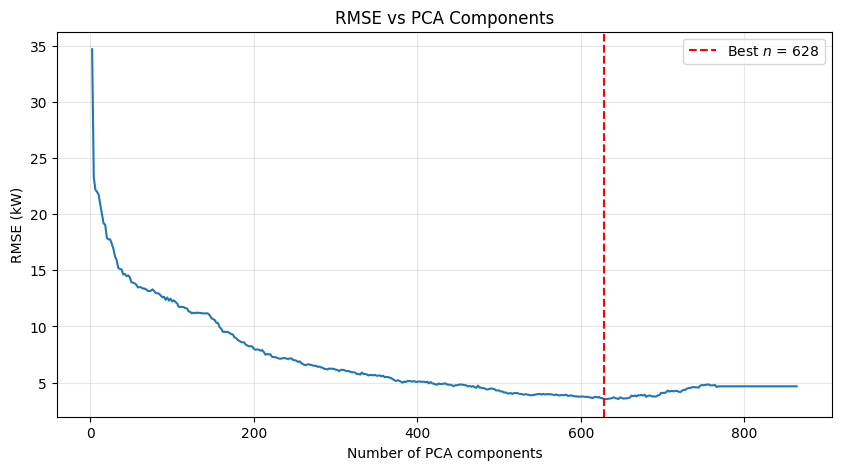

In [58]:
rmse_dict = results_features

x = np.array(sorted(rmse_dict.keys()))
y = np.array([rmse_dict[k] for k in x])

plt.figure(figsize=(10, 5))
plt.plot(x, y, marker=' ', linestyle='-', color='tab:blue')
plt.xlabel('Number of PCA components')
plt.ylabel('RMSE (kW)')
plt.title('RMSE vs PCA Components')
plt.grid(alpha=0.3)

if 'best_pred_pca' in globals():
    plt.axvline(best_pred_pca, color='red', linestyle='--', label=f'Best $n$ = {best_pred_pca}')
    plt.legend()

plt.show()

## HP Time Series

### Normalized Temperature

In [59]:
model = xgb.XGBRegressor()
model.fit(X_train, y_train['HP_Peak'])
xgb_pred = model.predict(X_test)
xgb_pred = np.maximum(xgb_pred, 0) # ensure non-negative predictions

model.fit(X_train_time, y_train_time['HP_Peak'])
xgb_pred_time = model.predict(X_test_time)
xgb_pred_time = np.maximum(xgb_pred_time, 0) # ensure non-negative predictions

X_train_pca = pd.DataFrame(pca_features_train[n_comp])
X_test_pca = pd.DataFrame(pca_features_test[n_comp])


model = LinearRegression()
model.fit(X_train_pca, y_train_time['HP_Peak'])
lin_pred_pca = model.predict(X_test_pca)
lin_pred_pca = np.maximum(lin_pred_pca, 0) # ensure non-negative predictions

threshold_temp = 15  # degreesC

resolution = 60  # in minutes

rmse_HP_time_series = {}
rmse_HP_time_series['Daily'] = {}
rmse_HP_time_series['Time-Based'] = {}
rmse_HP_time_series['PCA-Based'] = {}
rmse_HP_time_series['Hybrid'] = {}

for i in range(len(substations_df_test)):
    temperature = substations_df_test.iloc[i]['Temperature']
    temperature = temperature.resample(f'{resolution}min').mean().ffill()

    if substations_df_test.iloc[i]['size'] != 0:
        hp_load = substations_df_test.iloc[i]['HP_Load']
    else:
        hp_load = pd.Series(0, index=temperature.index)

    temp_load_df = pd.concat([temperature, hp_load], axis=1, join='inner')

    normalised_temp = (threshold_temp - temp_load_df['Temperature_avg_hourly'].values) / (threshold_temp - temp_load_df['Temperature_avg_hourly'].values.min())
    normalised_temp = np.clip(normalised_temp, 0, 1)

    rmse_HP_time_series['Daily'][i] = root_mean_squared_error(temp_load_df['kWh_received_HeatPump'].values, normalised_temp * xgb_pred[i])
    rmse_HP_time_series['Time-Based'][i] = root_mean_squared_error(temp_load_df['kWh_received_HeatPump'].values, normalised_temp * xgb_pred_time[i])
    rmse_HP_time_series['PCA-Based'][i] = root_mean_squared_error(temp_load_df['kWh_received_HeatPump'].values, normalised_temp * lin_pred_pca[i])
    rmse_HP_time_series['Hybrid'][i] = root_mean_squared_error(temp_load_df['kWh_received_HeatPump'].values, normalised_temp * hybrid_preds[threshold_temp][i])

NameError: name 'pca_features_train' is not defined

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


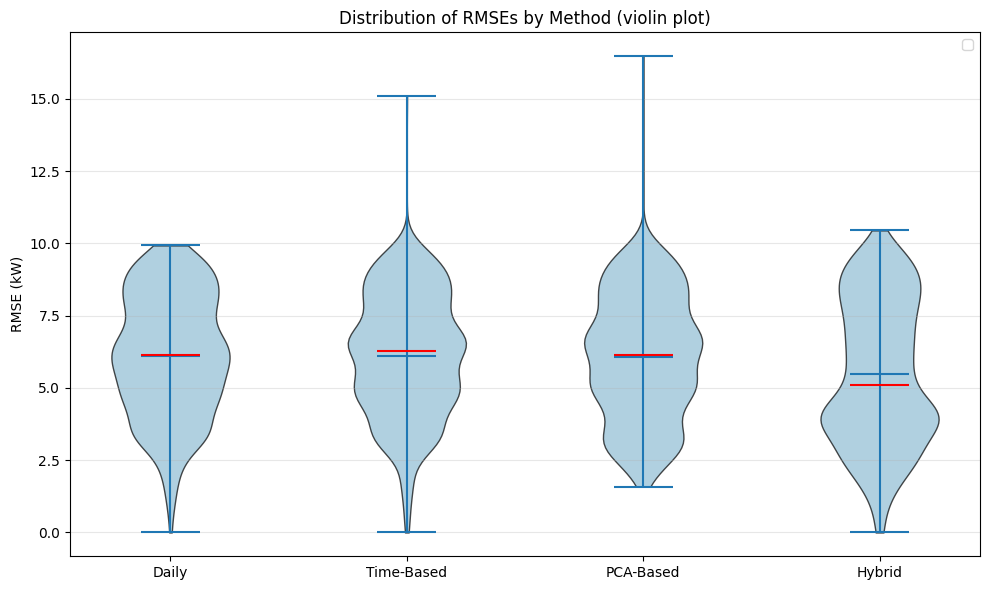

In [ ]:
# Violin plot of RMSEs (expects rmse_HP_time_series from previous cell)

# Prepare data
methods = ['Daily', 'Time-Based', 'PCA-Based', 'Hybrid']
data = []
labels = []
for m in methods:
    vals = rmse_HP_time_series.get(m, {})
    # if stored as dict of indices -> value
    if isinstance(vals, dict):
        vals_list = list(vals.values())
    else:
        vals_list = list(vals)
    # skip empty
    if len(vals_list) > 0:
        data.append(np.array(vals_list))
        labels.append(m)

if len(data) == 0:
    print("No RMSE data found to plot.")
else:
    fig, ax = plt.subplots(figsize=(10, 6))
    parts = ax.violinplot(data, showmeans=True, showmedians=True, showextrema=True)

    # style violins
    for pc in parts['bodies']:
        pc.set_facecolor('#8fbcd4')
        pc.set_edgecolor('black')
        pc.set_alpha(0.7)
    parts['cmedians'].set_color('red')
    parts['cmedians'].set_linewidth(1.5)

    # # overlay scatter of individual points (jittered)
    # for i, d in enumerate(data, start=1):
    #     x = np.random.normal(i, 0.08, size=len(d))
    #     ax.scatter(x, d, alpha=0.4, s=8, color='k')

    # # add mean markers and annotate summary stats
    # means = [np.mean(d) for d in data]
    # medians = [np.median(d) for d in data]
    # ax.scatter(range(1, len(data)+1), means, marker='D', color='white', edgecolors='black', zorder=3, label='Mean')
    # for i, (mn, md) in enumerate(zip(means, medians), start=1):
    #     ax.text(i + 0.12, mn, f'{mn:.2f}', verticalalignment='center', fontsize=9, color='black')
    #     ax.text(i + 0.12, md, f'{md:.2f}', verticalalignment='center', fontsize=9, color='red')

    ax.set_xticks(range(1, len(labels)+1))
    ax.set_xticklabels(labels)
    ax.set_ylabel('RMSE (kW)')
    ax.set_title('Distribution of RMSEs by Method (violin plot)')
    ax.grid(axis='y', alpha=0.3)
    ax.legend(loc='upper right')
    plt.tight_layout()
    plt.show()

Substation ID: 435
Real installed peak HP power: 16.42 kW
Substation size: 16
Number of Heat Pumps: 3
Threshold temperature: 15 °C
--------------------------------
RMSE (Daily features): 3.294 kW
RMSE (Time-based):    4.586 kW
RMSE (PCA-based):     3.915 kW
RMSE (Hybrid):        2.872 kW


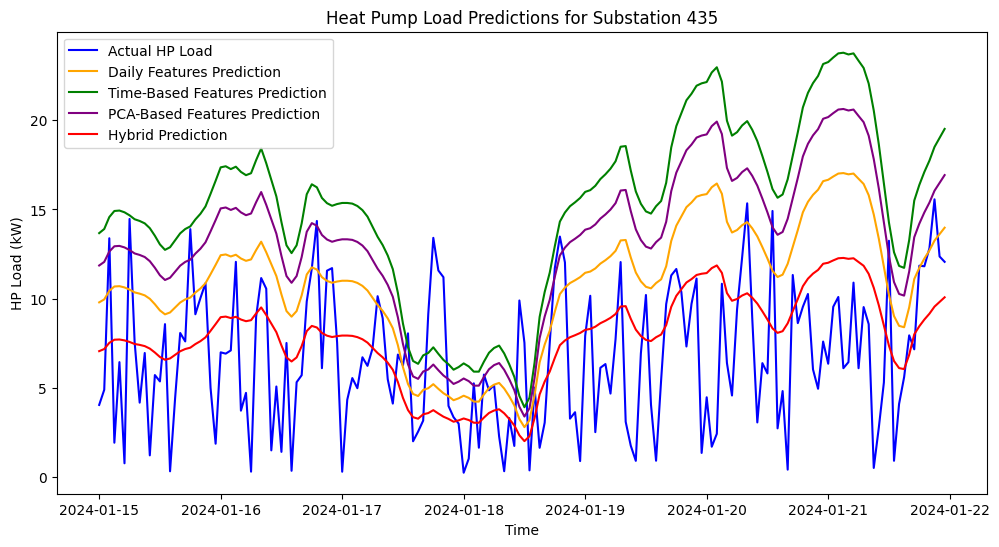

In [ ]:
i = randint(0, len(substations_df_test) - 1)  # example substation index
# Compute RMSEs for substation i and print real peak HP power
temperature = substations_df_test.iloc[i]['Temperature']
temperature = temperature.resample(f'{resolution}min').mean().ffill()

if substations_df_test.iloc[i]['size'] != 0:
    hp_load = substations_df_test.iloc[i]['HP_Load']
else:
    hp_load = pd.Series(0, index=temperature.index)


temp_load_df = pd.concat([temperature, hp_load], axis=1, join='inner')

normalised_temp = (threshold_temp - temp_load_df['Temperature_avg_hourly'].values) / (threshold_temp - temp_load_df['Temperature_avg_hourly'].values.min())
normalised_temp = np.clip(normalised_temp, 0, 1)

pred_daily_ts = normalised_temp * xgb_pred[i]
pred_time_ts = normalised_temp * xgb_pred_time[i]
pred_pca_ts = normalised_temp * xgb_pred_pca[i]
pred_hybrid_ts = normalised_temp * hybrid_preds[threshold_temp][i]

actual = temp_load_df['kWh_received_HeatPump'].values

rmse_daily = root_mean_squared_error(actual, pred_daily_ts)
rmse_time = root_mean_squared_error(actual, pred_time_ts)
rmse_pca = root_mean_squared_error(actual, pred_pca_ts)
rmse_hybrid = root_mean_squared_error(actual, pred_hybrid_ts)

real_peak = actual.max()

print(f"Substation ID: {substations_df_test.index[i]}")
print(f"Real installed peak HP power: {real_peak:.2f} kW")
print(f"Substation size: {substations_df_test.iloc[i]['size']}")
print(f"Number of Heat Pumps: {len(substations_df_test.iloc[i]['households_hp'])}")
print(f"Threshold temperature: {threshold_temp} °C")
print("--------------------------------")
print(f"RMSE (Daily features): {rmse_daily:.3f} kW")
print(f"RMSE (Time-based):    {rmse_time:.3f} kW")
print(f"RMSE (PCA-based):     {rmse_pca:.3f} kW")
print(f"RMSE (Hybrid):        {rmse_hybrid:.3f} kW")

winter_week = (temp_load_df['Temperature_avg_hourly'].index.month == 1) & (temp_load_df['Temperature_avg_hourly'].index.day >= 15) & (temp_load_df['Temperature_avg_hourly'].index.day < 22)
temp_load_df = temp_load_df[winter_week]
actual = temp_load_df['kWh_received_HeatPump'].values
normalised_temp = (threshold_temp - temp_load_df['Temperature_avg_hourly'].values) / (threshold_temp - temp_load_df['Temperature_avg_hourly'].values.min())
normalised_temp = np.clip(normalised_temp, 0, 1)

fig, ax = plt.subplots(figsize=(12, 6))
time_index = temp_load_df.index
ax.plot(time_index, actual, label='Actual HP Load', color='blue')
ax.plot(time_index, normalised_temp * xgb_pred[i], label='Daily Features Prediction', color='orange')
ax.plot(time_index, normalised_temp * xgb_pred_time[i], label='Time-Based Features Prediction', color='green')
ax.plot(time_index, normalised_temp * xgb_pred_pca[i], label='PCA-Based Features Prediction', color='purple')
ax.plot(time_index, normalised_temp * hybrid_preds[threshold_temp][i], label='Hybrid Prediction', color='red')
ax.set_xlabel('Time')
ax.set_ylabel('HP Load (kW)')
ax.set_title(f'Heat Pump Load Predictions for Substation {substations_df_test.index[i]}')
ax.legend()
plt.show()

## WPUQ Dataset

In [ ]:
wpuq_data = h5py.File('data\\2020_data_15min.hdf5', 'r')
wpuq_transf_df = pd.DataFrame(np.array(wpuq_data['MISC']['ES1']['TRANSFORMER']['table'])) 
wpuq_transf_df['index'] = pd.to_datetime(wpuq_transf_df['index'], utc=True, origin='unix', unit='s')
wpuq_transf_df['P_TOT'] = wpuq_transf_df['P_TOT'] / 1000  # Convert W to kW

substation_total = wpuq_transf_df.set_index('index')
substation_total['Date'] = substation_total.index.date
substation_total['Time'] = substation_total.index.time
substation_total = substation_total[['P_TOT', 'Date', 'Time']]

In [ ]:
wpuq_weather = h5py.File('data\\2020_weather.hdf5', 'r')
wpuq_weather_df = pd.DataFrame(np.array(wpuq_weather['WEATHER_SERVICE']['IN']['WEATHER_TEMPERATURE_TOTAL']['table']))
wpuq_weather_df['index'] = pd.to_datetime(wpuq_weather_df['index'], utc=True, origin='unix', unit='ns')

wpuq_weather_df = wpuq_weather_df.set_index('index').resample('15min').mean()[:-1]
wpuq_weather_df.index = wpuq_weather_df.index.shift(periods=1, freq='h')
wpuq_weather_df['Date'] = wpuq_weather_df.index.date
wpuq_weather_df['Time'] = wpuq_weather_df.index.time

In [ ]:
wpuq_hp_data = {}
wpuq_house_data = {}

for building in wpuq_data['NO_PV'].keys():
    hp_df = pd.DataFrame(np.array(wpuq_data['NO_PV'][building]['HEATPUMP']['table']))
    house_df = pd.DataFrame(np.array(wpuq_data['NO_PV'][building]['HOUSEHOLD']['table']))
    
    hp_df.dropna(inplace=True)
    house_df.dropna(inplace=True)

    print(f"Building: {building}, HP Peak: {hp_df['P_TOT'].max() / 1000:.2f} kW, HP 99.9th percentile: {hp_df['P_TOT'].quantile(0.999) / 1000:.2f} kW")
    if len(hp_df) >= 365 * 24 * 4 * 0.9:  # check if data has at least a year's worth of 15-min intervals
        wpuq_hp_data[building] = hp_df['P_TOT'].fillna(0) / 1000  # Convert W to kW
    if len(house_df) >= 365 * 24 * 4 * 0.9:
        wpuq_house_data[building] = house_df['P_TOT'].fillna(0) / 1000  # Convert W to kW

# --------------------------------

for building in wpuq_data['WITH_PV'].keys():
    hp_df = pd.DataFrame(np.array(wpuq_data['WITH_PV'][building]['HEATPUMP']['table']))
    house_df = pd.DataFrame(np.array(wpuq_data['WITH_PV'][building]['HOUSEHOLD']['table']))

    hp_df.dropna(inplace=True)
    house_df.dropna(inplace=True)

    print(f"Building: {building}, HP Peak: {hp_df['P_TOT'].max() / 1000:.2f} kW, HP 99.9th percentile: {hp_df['P_TOT'].quantile(0.999) / 1000:.2f} kW")
    if len(hp_df) >= 365 * 24 * 4 * 0.9:  # check if data has at least a year's worth of 15-min intervals
        wpuq_hp_data[building] = hp_df['P_TOT'].fillna(0) / 1000  # Convert W to kW
    if len(house_df) >= 365 * 24 * 4 * 0.9:
        wpuq_house_data[building] = house_df['P_TOT'].fillna(0) / 1000  # Convert W to kW


Building: SFH10, HP Peak: 12.04 kW, HP 99.9th percentile: 2.32 kW
Building: SFH11, HP Peak: 7.42 kW, HP 99.9th percentile: 5.91 kW
Building: SFH12, HP Peak: 6.02 kW, HP 99.9th percentile: 5.83 kW
Building: SFH14, HP Peak: 8.70 kW, HP 99.9th percentile: 2.47 kW
Building: SFH16, HP Peak: 12.46 kW, HP 99.9th percentile: 11.06 kW
Building: SFH17, HP Peak: 3.07 kW, HP 99.9th percentile: 3.03 kW
Building: SFH18, HP Peak: 9.29 kW, HP 99.9th percentile: 5.91 kW
Building: SFH19, HP Peak: 2.63 kW, HP 99.9th percentile: 2.54 kW
Building: SFH20, HP Peak: 12.84 kW, HP 99.9th percentile: 11.49 kW
Building: SFH21, HP Peak: 2.85 kW, HP 99.9th percentile: 2.72 kW
Building: SFH22, HP Peak: 7.57 kW, HP 99.9th percentile: 5.85 kW
Building: SFH23, HP Peak: 2.48 kW, HP 99.9th percentile: 2.21 kW
Building: SFH27, HP Peak: 2.36 kW, HP 99.9th percentile: 2.20 kW
Building: SFH28, HP Peak: 7.89 kW, HP 99.9th percentile: 5.76 kW
Building: SFH29, HP Peak: 5.87 kW, HP 99.9th percentile: 4.31 kW
Building: SFH3, HP P

In [ ]:
wpuq_hp_df = pd.DataFrame(wpuq_hp_data)
wpuq_house_df = pd.DataFrame(wpuq_house_data)

wpuq_total_hp = wpuq_hp_df.sum(axis=1)
wpuq_total_house = wpuq_house_df.sum(axis=1)

wpuq_total = {}

wpuq_total['Load'] = wpuq_total_hp.values + wpuq_total_house.values
wpuq_total['Date'] = wpuq_weather_df['Date'].values
wpuq_total['Time'] = wpuq_weather_df['Time'].values

wpuq_total_df = pd.DataFrame(wpuq_total, index=wpuq_weather_df.index)

In [ ]:
wpuq_target = {}
wpuq_target['HP_Average'] = np.mean(wpuq_total_hp)
wpuq_target['HP_Peak'] = np.sum([wpuq_hp_df[hid].quantile(0.999) for hid in wpuq_hp_df.columns])
wpuq_target['HP_Simult_Peak'] = wpuq_total_hp.max()
wpuq_target['HP_Capacity_Factor'] = np.mean(wpuq_total_hp) / np.max(wpuq_total_hp)
wpuq_target['HP_Total_Energy'] = wpuq_total_hp.sum() / 4
wpuq_target['HP_Simult_Factor'] = np.max(wpuq_total_hp) / wpuq_target['HP_Peak']

In [ ]:
dailyLoad = wpuq_total_df.pivot(index='Date', columns='Time', values='Load').ffill()

dailyWeather = wpuq_weather_df.pivot(index='Date', columns='Time', values='TEMPERATURE:TOTAL').ffill()

dailyWeather = dailyWeather[dailyWeather.index.isin(dailyLoad.index)]

dailyFeatures = {}
dailyFeatures['Mean'] = dailyLoad.mean(axis=0)
dailyFeatures['Std'] = dailyLoad.std(axis=0)
dailyFeatures['Min'] = dailyLoad.min(axis=0)
dailyFeatures['Max'] = dailyLoad.max(axis=0)
dailyFeatures['Skew'] = dailyLoad.skew(axis=0)
dailyFeatures['Kurtosis'] = dailyLoad.kurtosis(axis=0)
dailyFeatures['Max-Min'] = dailyLoad.max(axis=0) - dailyLoad.min(axis=0)
dailyFeatures['Cov'] = np.array([np.cov(dailyLoad.iloc[:,i], dailyWeather.iloc[:,i])[0][1] 
                                            for i in range(dailyLoad.shape[1])])
dailyFeatures['Corr_Pearson'] = pearsonr(x=dailyLoad, y=dailyWeather, axis=0).statistic

dailyFeaturesDf = pd.DataFrame(dailyFeatures)

# features = {}
# features['Mean'] = dailyFeaturesDf.mean()
# features['Std'] = dailyFeaturesDf.std()
# features['Min'] = dailyFeaturesDf.min()
# features['Max'] = dailyFeaturesDf.max()
# features['Median'] = dailyFeaturesDf.median()

wpuq_features = {}

for key_main in dailyFeaturesDf.keys():
    for key_sub in dailyFeaturesDf.index:
        wpuq_features[f'Feature {key_main}_{key_sub}'] = dailyFeaturesDf[key_main][key_sub]

wpuq_featuresDf = pd.DataFrame.from_dict(wpuq_features, orient='index').T

In [ ]:
sm_data = pd.DataFrame({
            'Temperature_avg': wpuq_weather_df['TEMPERATURE:TOTAL'].resample('D').mean(),
            'Total_Load': wpuq_total_df['Load'].resample('D').mean()
        }).dropna()

x = sm_data['Temperature_avg'].values
y = sm_data['Total_Load'].values

plin_wpuq = pwlf.PiecewiseLinFit(x, y)
breakpoints_wpuq = plin_wpuq.fit(2)
slopes_wpuq = plin_wpuq.slopes

In [ ]:
delta_breakpoint_wpuq = np.array([[(breakpoints_wpuq[0] - breakpoints_wpuq[1]) * slopes_wpuq[0] + (breakpoints_wpuq[1] - breakpoints_wpuq[2]) * slopes_wpuq[1]]])

nonSimDeltaPred_wpuq = nonSimDeltaFit.predict(delta_breakpoint_wpuq)

print(nonSimDeltaPred_wpuq)
print(wpuq_target['HP_Simult_Peak'])

[74.44775399]
58.11023729789527


c:\Users\VENANCIA\OneDrive - VITO\Desktop\NILM\.venv\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


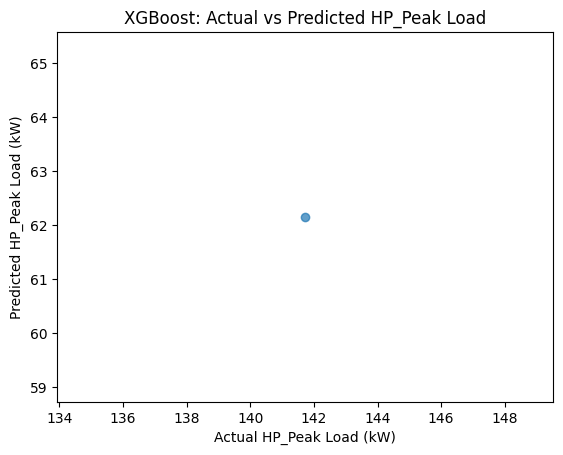

In [ ]:
for col in y_train.columns:
    xgb_model = xgb.XGBRegressor()
    xgb_model.fit(X_train_time, y_train_time[col])

    xgb_pred = xgb_model.predict(wpuq_featuresDf)

    xgb_pred = np.maximum(xgb_pred, 0) # ensure non-negative predictions

    fig, ax = plt.subplots()
    ax.scatter(wpuq_target[col], xgb_pred, alpha=0.7)
    # ax.plot([y_test[col].min(), y_test[col].max()], [y_test[col].min(), y_test[col].max()], 'r--')
    ax.set_xlabel(f'Actual {col} Load (kW)')
    ax.set_ylabel(f'Predicted {col} Load (kW)')
    ax.set_title(f'XGBoost: Actual vs Predicted {col} Load')
    plt.show()

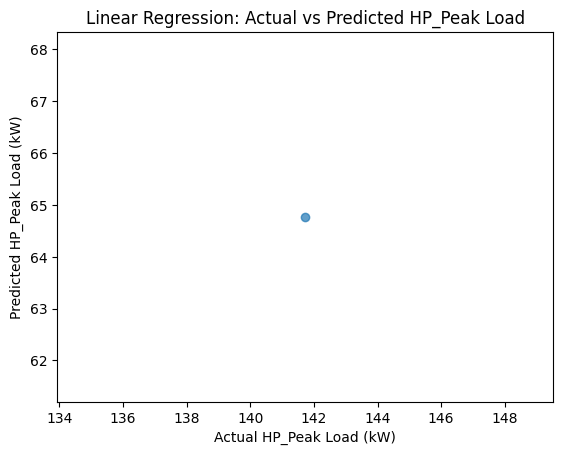

In [ ]:
col = 'HP_Peak'

model = LinearRegression()
model.fit(X_train_time, y_train_time[col])

linreg_pred = model.predict(wpuq_featuresDf)

linreg_pred = np.maximum(linreg_pred, 0) # ensure no negative predictions

fig, ax = plt.subplots()
ax.scatter(wpuq_target[col], linreg_pred, alpha=0.7)
# ax.plot([0, y_test[col].max()], [0, y_test[col].max()], 'r--')
ax.set_xlabel(f'Actual {col} Load (kW)')
ax.set_ylabel(f'Predicted {col} Load (kW)')
ax.set_title(f'Linear Regression: Actual vs Predicted {col} Load')
plt.show()

## Random Plots

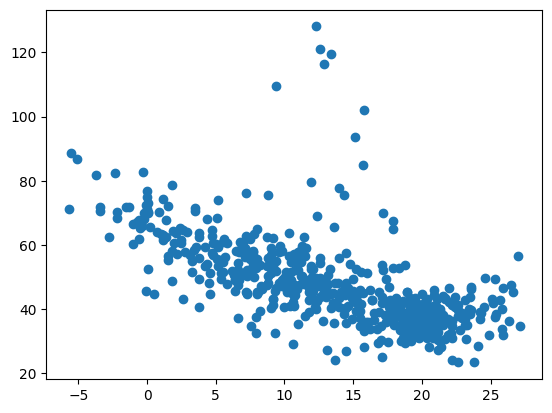

In [ ]:
id = datarangeDf.index[2]
weather_id = datarangeDf.loc[id, 'Weather_ID']

sm_data = heapo.load_smart_meter_and_weather_data_combined(id, smd_resolution='daily', weather_resolution='daily', interpolate_hourly=False)

plt.figure()
plt.plot(sm_data['Temperature_avg_daily'], sm_data['kWh_received_Total'], 'o')

ValueError: x and y must be the same size

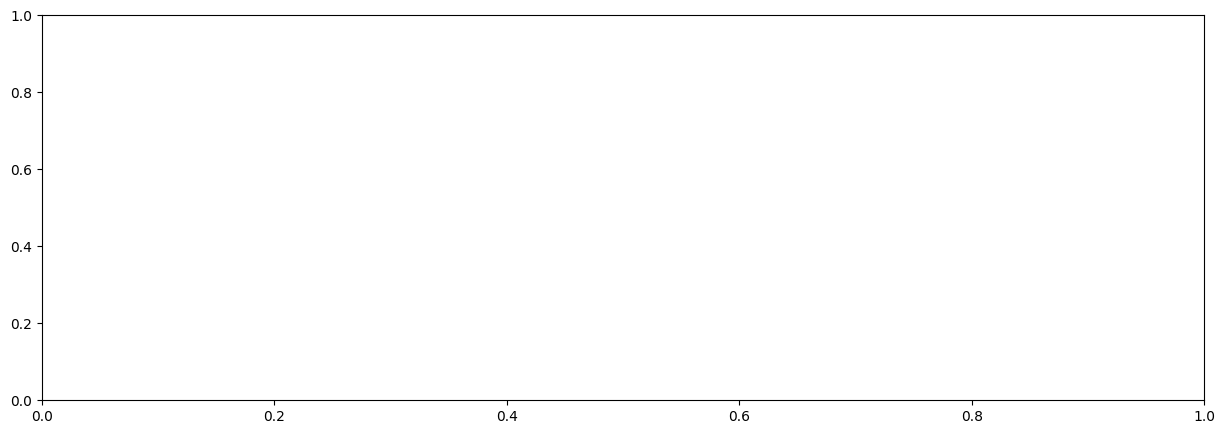

In [ ]:
i = 21

plt.figure(figsize=(15,5))
plt.scatter(substations_df.iloc[i]['Temperature'].values[:-97], substations_df.iloc[i]['HP_Load'].values, alpha=0.5)

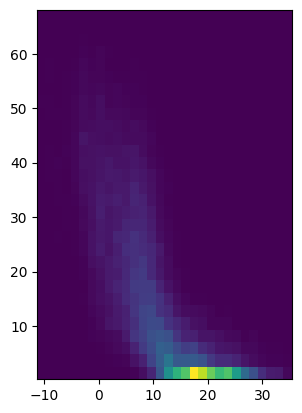

In [ ]:
heatmap, xedges, yedges = np.histogram2d(substations_df.iloc[i]['Temperature'].values[:-97], substations_df.iloc[i]['HP_Load'].values, bins=(30,30))
extent = [xedges[0], xedges[-1], yedges[0], yedges[-1]]

plt.clf()
plt.imshow(heatmap.T, extent=extent, origin='lower')
plt.show()

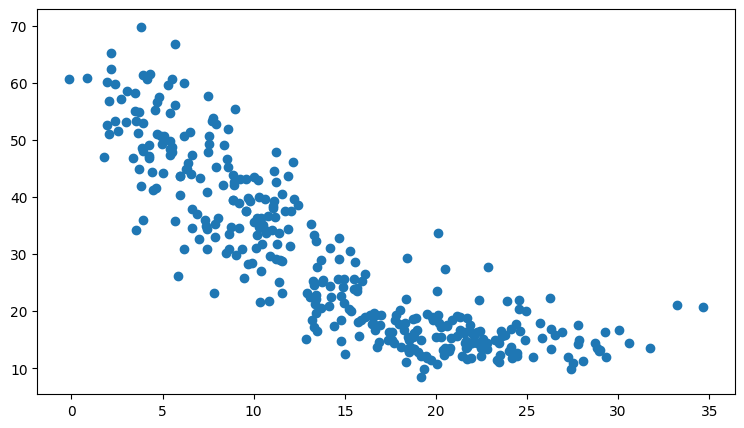

In [ ]:
plt.figure(figsize=(9,5))
plt.scatter(wpuq_weather_df['TEMPERATURE:TOTAL'][wpuq_weather_df['Time'] == pd.to_datetime('16:00').time()], 
            wpuq_total_df['Load'][wpuq_total_df['Time'] == pd.to_datetime('16:00').time()], alpha=1)

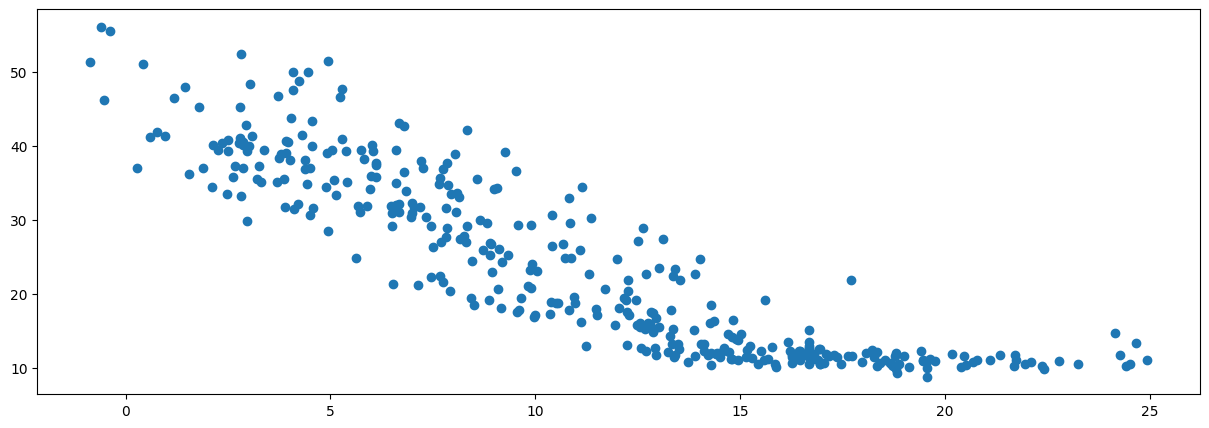

In [ ]:
dailyMeanTemp = dailyWeather.mean(axis=1)
dailyMeanLoad = dailyLoad.mean(axis=1)

plt.figure(figsize=(15,5))
plt.scatter(dailyMeanTemp, dailyMeanLoad)

# Rest

In [ ]:
df_meta_submetered = df_meta[df_meta['Household_ID'].isin(datarangeDf.index)]
df_protocols_submetered = df_protocols[df_protocols['Household_ID'].isin(datarangeDf.index)]

Check households with submetered PV

In [ ]:
for household_id in available_households:
    try:
        df_house = heapo.load_smart_meter_data(household_id, resolution='15min')
        #df_house = df_house[df_house['Timestamp'] >= pd.to_datetime(start_date)]
        df_house.dropna(subset=['kWh_returned_PV'],inplace=True)
        if len(df_house) > 0:
            print(f'Household {household_id} has submetered PV with {len(df_house)} data points.')
    except:
        pass

NameError: name 'available_households' is not defined

In [ ]:
df_meta = heapo.get_meta_data_overview()

households = heapo.get_all_households()
weather_stations = heapo.get_all_weather_ids()

df_features = heapo.prepare_features_from_protocols()

hp_installed_kW = df_features['HeatPump_Installation_HeatingCapacity'].dropna()

c:\Users\VENANCIA\OneDrive - VITO/Desktop/NILM/src\heapo.py:1480: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_protocols[col] = df_protocols[col].fillna(False).astype(int).astype(float)
c:\Users\VENANCIA\OneDrive - VITO/Desktop/NILM/src\heapo.py:1480: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_protocols[col] = df_protocols[col].fillna(False).astype(int).astype(float)
c:\Users\VENANCIA\OneDrive - VITO/Desktop/NILM/src\heapo.py:1480: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a futur

In [ ]:
df_protocols = heapo.get_all_protocols()

<Figure size 1500x500 with 0 Axes>

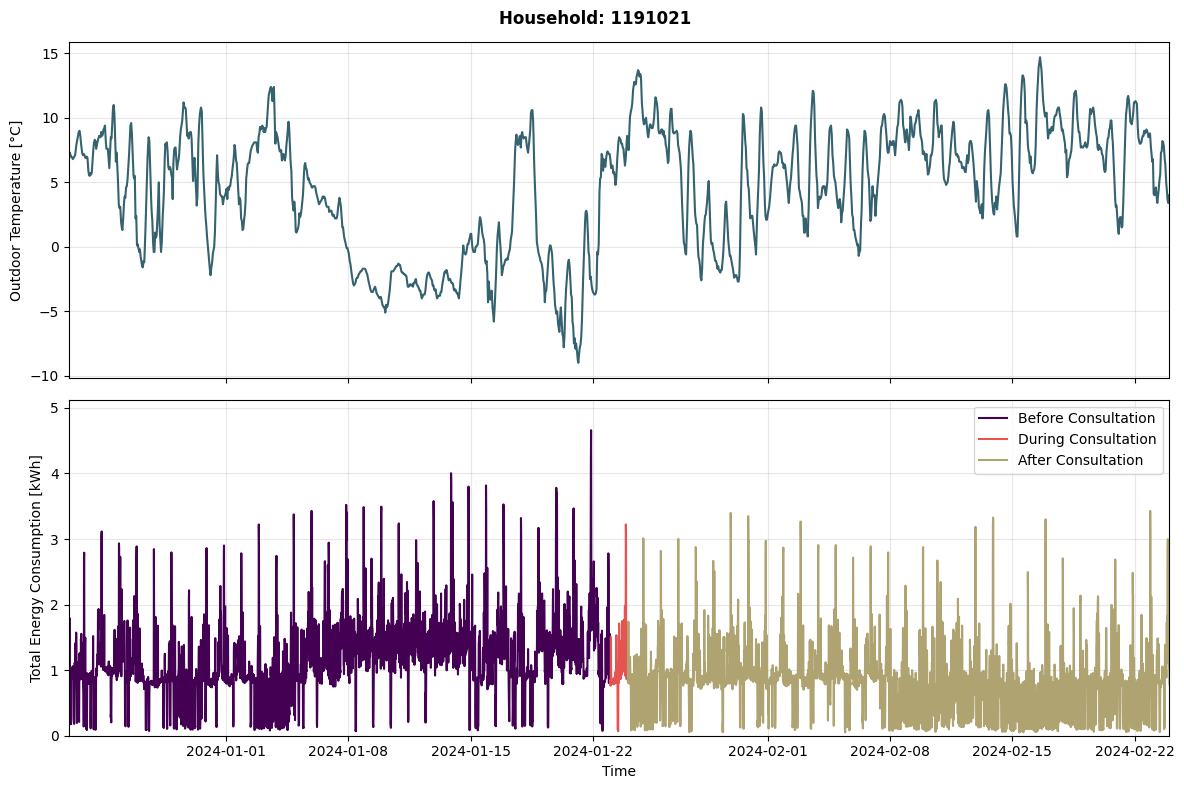

,Household_ID,Group,AffectsTimePoint,Timestamp,kWh_received_Total,kWh_received_HeatPump,kWh_received_Other,Temperature_avg_hourly,Temperature_max_daily,Temperature_min_daily,...,Spring,Summer,Autumn,TransitionPeriod,Cyclic_TimeOfDay_X,Cyclic_TimeOfDay_Y,Cyclic_DayOfYear_X,Cyclic_DayOfYear_Y,Cyclic_DayOfWeek_X,Cyclic_DayOfWeek_Y
32256,1191021,treatment,before visit,2023-12-23 00:00:00+00:00,0.842,NaN,NaN,7.400,9.1,6.6,...,False,False,False,False,0.000000,1.000000,-0.137279,0.990532,-0.974928,-0.222521
32257,1191021,treatment,before visit,2023-12-23 00:15:00+00:00,0.917,NaN,NaN,7.375,9.1,6.6,...,False,False,False,False,0.065403,0.997859,-0.137279,0.990532,-0.974928,-0.222521
32258,1191021,treatment,before visit,2023-12-23 00:30:00+00:00,0.883,NaN,NaN,7.350,9.1,6.6,...,False,False,False,False,0.130526,0.991445,-0.137279,0.990532,-0.974928,-0.222521
32259,1191021,treatment,before visit,2023-12-23 00:45:00+00:00,0.886,NaN,NaN,7.325,9.1,6.6,...,False,False,False,False,0.195090,0.980785,-0.137279,0.990532,-0.974928,-0.222521
32260,1191021,treatment,before visit,2023-12-23 01:00:00+00:00,0.859,NaN,NaN,7.300,9.1,6.6,...,False,False,False,False,0.258819,0.965926,-0.137279,0.990532,-0.974928,-0.222521
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38299,1191021,treatment,after visit,2024-02-23 22:45:00+00:00,2.069,NaN,NaN,3.850,8.9,2.7,...,False,False,False,False,-0.321439,0.946930,0.801361,0.598181,-0.433884,-0.900969
38300,1191021,treatment,after visit,2024-02-23 23:00:00+00:00,1.107,NaN,NaN,4.000,8.9,2.7,...,False,False,False,False,-0.258819,0.965926,0.801361,0.598181,-0.433884,-0.900969
38301,1191021,treatment,after visit,2024-02-23 23:15:00+00:00,1.030,NaN,NaN,3.825,8.9,2.7,...,False,False,False,False,-0.195090,0.980785,0.801361,0.598181,-0.433884,-0.900969
38302,1191021,treatment,after visit,2024-02-23 23:30:00+00:00,1.017,NaN,NaN,3.650,8.9,2.7,...,False,False,False,False,-0.130526,0.991445,0.801361,0.598181,-0.433884,-0.900969


In [ ]:
household_id = 1191021

fig = plt.figure(figsize=(15, 5))

df = heapo.load_smart_meter_and_weather_data_combined(household_id, smd_resolution='15min', weather_resolution='hourly_and_daily', interpolate_hourly=True)
df = heapo.add_temporal_information(df, inplace=True)

df_protocol = heapo.load_protocol_data(household_id)

# limit time series around report date 
report_date = df_protocol['Visit_Date'].iloc[0]
df = heapo.limit_time_series_around_date(df, report_date, months_before=1, months_after=1, inplace=True)

# split into before and after report date
df_before, df_during, df_after = heapo.split_time_series_around_consultation(df)

# --------------------------------
# EXAMPLE: PLOT ENERGY CONSUMPTION
# --------------------------------

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
fig.suptitle('Household: {}'.format(household_id), fontweight='bold')

# plot temperature 
ax = axes[0]
ax.plot(df['Timestamp'].values, df['Temperature_avg_hourly'].values, color=COLOR_DARK)
ax.set_ylabel('Outdoor Temperature [°C]')
ax.grid(alpha=0.3)

# plot energy consumption
ax = axes[1]
if len(df_before) > 0:
    ax.plot(df_before['Timestamp'].values, df_before['kWh_received_Total'].values, color=COLOR_PURPLE, label='Before Consultation')
if len(df_during) > 0:
    ax.plot(df_during['Timestamp'].values, df_during['kWh_received_Total'].values, color=COLOR_RED, label='During Consultation')
if len(df_after) > 0:
    ax.plot(df_after['Timestamp'].values, df_after['kWh_received_Total'].values, color=COLOR_YELLOW, label='After Consultation')
ax.set_xlabel('Time')
ax.set_ylabel('Total Energy Consumption [kWh]')
ax.set_xlim(df_before['Timestamp'].min(), df_after['Timestamp'].max())
ax.set_ylim(0, df['kWh_received_Total'].max() * 1.1)
ax.legend()
ax.grid(alpha=0.3)

fig.tight_layout()
plt.show()

display(df)

Text(0, 0.5, 'Daily Total Energy Consumption [kWh]')

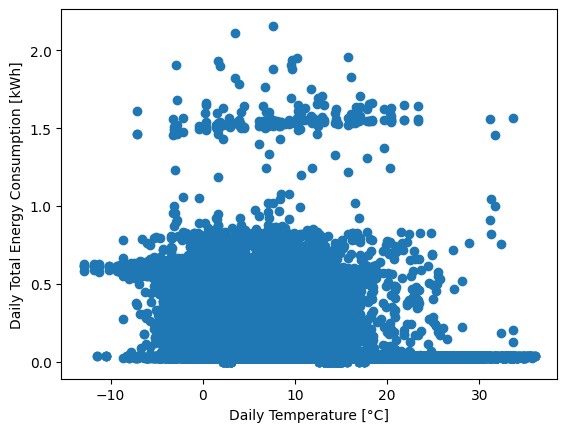

In [ ]:
df2 = heapo.load_smart_meter_and_weather_data_combined(856765, smd_resolution='15min', weather_resolution='hourly', interpolate_hourly=False)

#plt.scatter(df2['Temperature_min_daily'], df2['kWh_received_Total'])
#plt.scatter(df2['Temperature_max_daily'], df2['kWh_received_Total'])
plt.scatter(df2['Temperature_avg_hourly'], df2['kWh_received_HeatPump'])
plt.xlabel('Daily Temperature [°C]')
plt.ylabel('Daily Total Energy Consumption [kWh]')

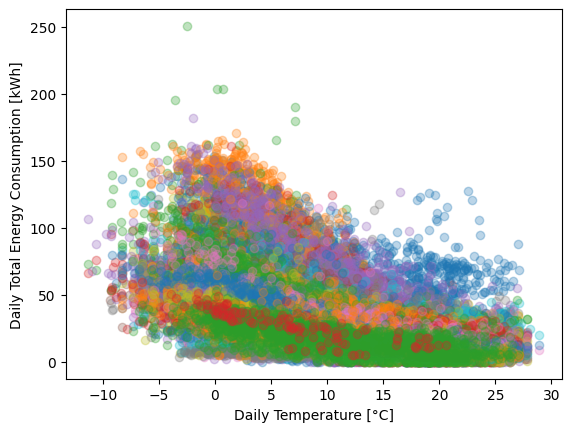

In [ ]:
df_meta = heapo.get_meta_data_overview()
df_meta = df_meta[df_meta['SmartMeterData_Available_Daily'] == True]

df_features = df_features[df_features['Household_ID'].isin(df_meta['Household_ID'])]

df_features.sort_values('HeatPump_Installation_HeatingCapacity', ascending=False, inplace=True)

for _,row in df_features.iterrows():
    household_id = row['Household_ID']
    df_house = heapo.load_smart_meter_and_weather_data_combined(household_id, smd_resolution='daily', weather_resolution='daily', interpolate_hourly=False)
    plt.scatter(df_house['Temperature_avg_daily'], df_house['kWh_received_Total'], alpha=0.3)
    plt.xlabel('Daily Temperature [°C]')
    plt.ylabel('Daily Total Energy Consumption [kWh]')
plt.show()

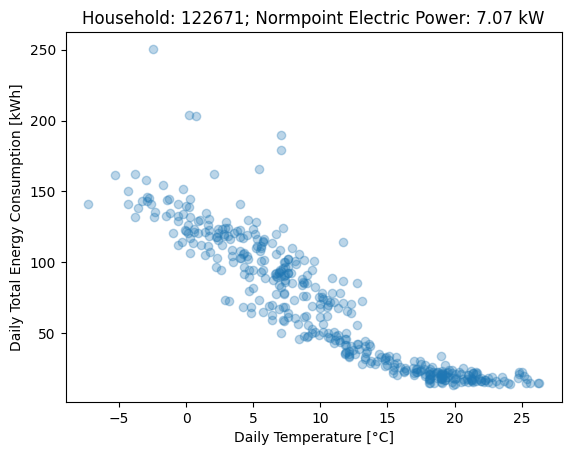

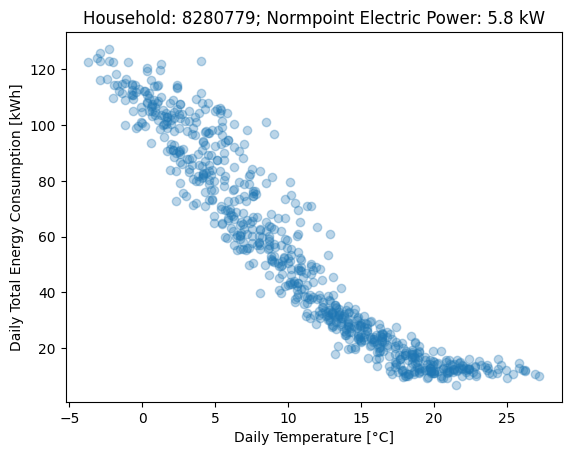

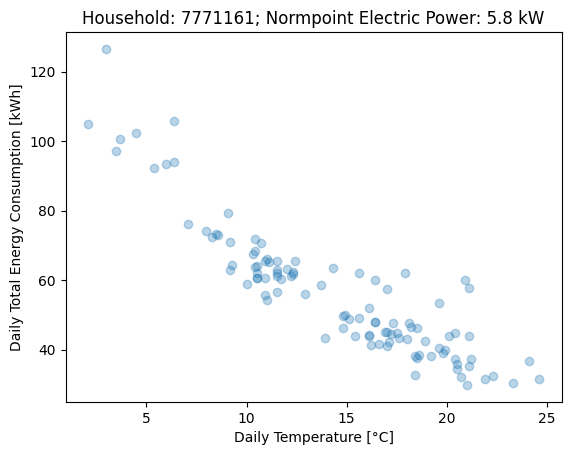

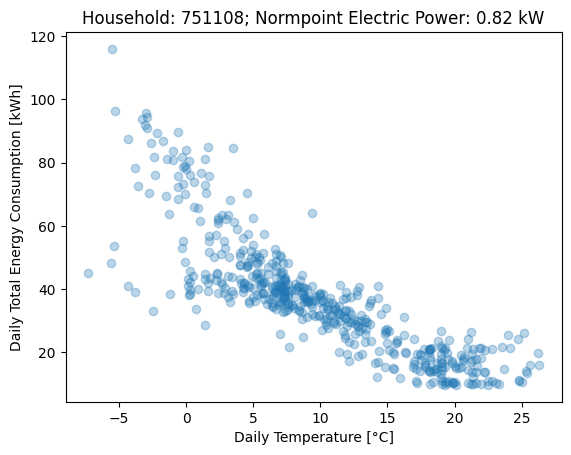

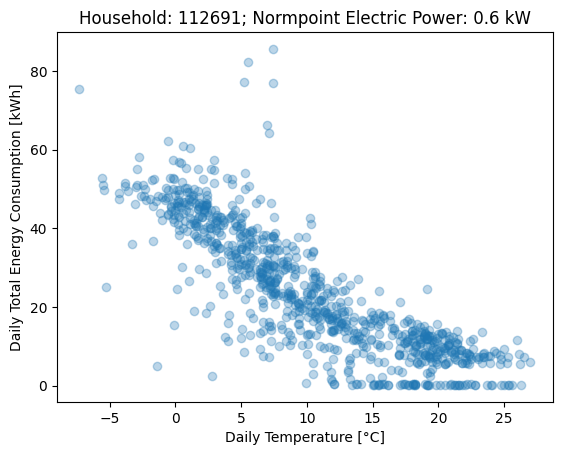

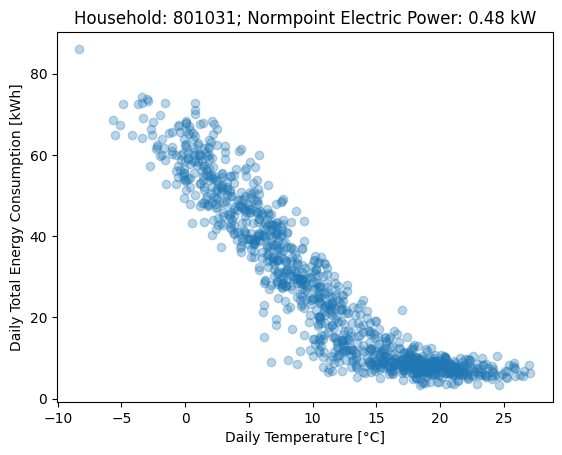

In [ ]:
df_features.sort_values('HeatPump_Installation_Normpoint_ElectricPower', ascending=False, inplace=True)
df_features.dropna(subset=['HeatPump_Installation_Normpoint_ElectricPower'], inplace=True)

households_test = [df_features['Household_ID'].iloc[0], df_features['Household_ID'].iloc[1], df_features['Household_ID'].iloc[2], df_features['Household_ID'].iloc[-3], df_features['Household_ID'].iloc[-2], df_features['Household_ID'].iloc[-1]]

for household_id in households_test:
    df_house = heapo.load_smart_meter_and_weather_data_combined(household_id, smd_resolution='daily', weather_resolution='daily', interpolate_hourly=False)
    plt.scatter(df_house['Temperature_avg_daily'], df_house['kWh_received_Total'], alpha=0.3)
    plt.xlabel('Daily Temperature [°C]')
    plt.ylabel('Daily Total Energy Consumption [kWh]')
    plt.title('Household: {}; Normpoint Electric Power: {} kW'.format(household_id, df_features.loc[df_features['Household_ID'] == household_id, 'HeatPump_Installation_Normpoint_ElectricPower'].values[0]))
    plt.show()


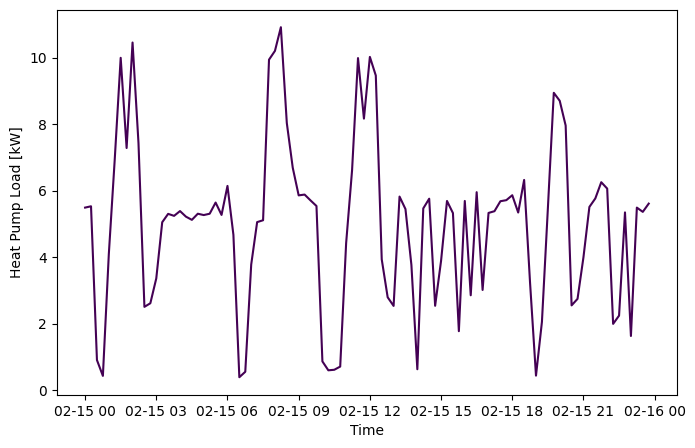

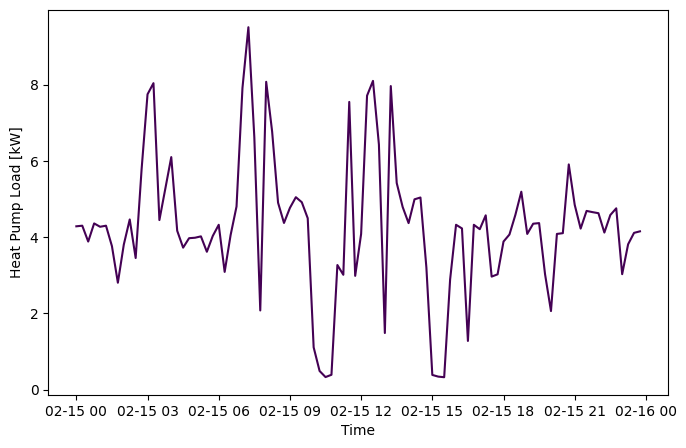

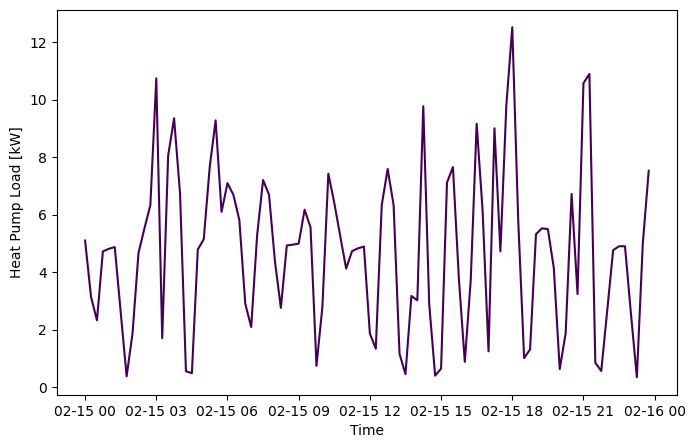

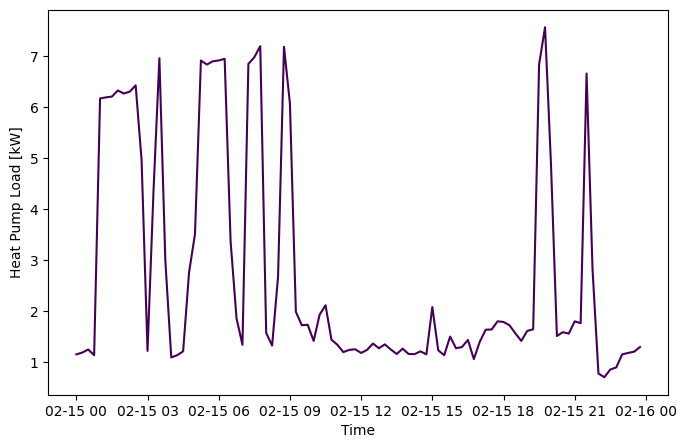

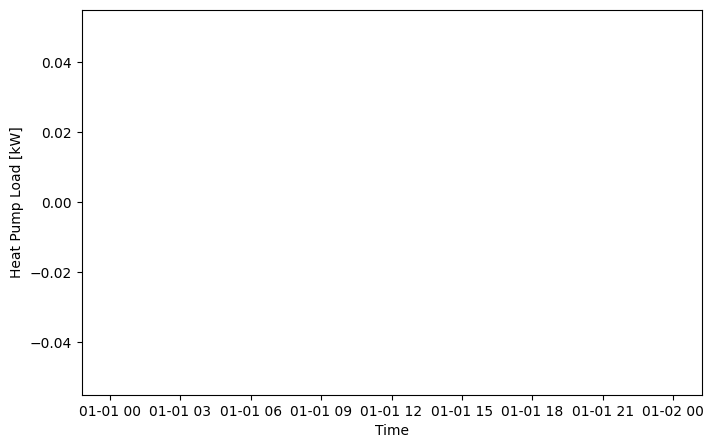

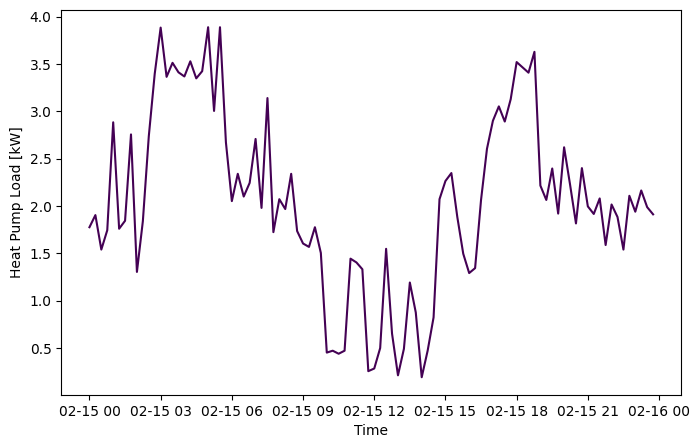

In [ ]:
date = '2023-02-15'

for house in households_test:
    df_house = heapo.load_smart_meter_data(house, resolution='15min')
    # df = heapo.limit_time_series_around_date(df_house, date, months_before=1, months_after=1, inplace=False)
    df = df_house[df_house['Timestamp'].dt.date == pd.to_datetime(date).date()]
    plt.figure(figsize=(8, 5))
    plt.plot(df['Timestamp'].values, df['kWh_received_Total'].values * 4, color=COLOR_PURPLE)
    plt.xlabel('Time')
    plt.ylabel('Heat Pump Load [kW]')
    # plt.title('Household: {}; Normpoint Electric Power: {} kW'.format(house, df_features.loc[df_features['Household_ID'] == house, 'HeatPump_Installation_Normpoint_ElectricPower'].values[0]))
    plt.show()

In [ ]:
df_features.sort_values('HeatPump_Installation_Normpoint_ElectricPower', ascending=False, inplace=True)
df_features.dropna(subset=['HeatPump_Installation_Normpoint_ElectricPower'], inplace=True)

model = LinearRegression()

coefs = []
powers = df_features['HeatPump_Installation_Normpoint_ElectricPower'][df_features['Household_ID'].isin(df_meta['Household_ID'][df_meta['SmartMeterData_Available_Daily'] == True])].values

for household_id in df_features['Household_ID'][df_features['Household_ID'].isin(df_meta['Household_ID'][df_meta['SmartMeterData_Available_Daily'] == True])]:
    df_house = heapo.load_smart_meter_and_weather_data_combined(household_id, smd_resolution='daily', weather_resolution='daily', interpolate_hourly=False)
    X = df_house['Temperature_avg_daily'][df_house['Temperature_avg_daily'] < 15].values.reshape(-1, 1)
    y = df_house['kWh_received_Total'][df_house['Temperature_avg_daily'] < 15].values

    model.fit(X, y)
    coefs.append(model.coef_[0])

Text(0.5, 1.0, 'Coefficient of Linear Regression Model vs. Normpoint Electric Power')

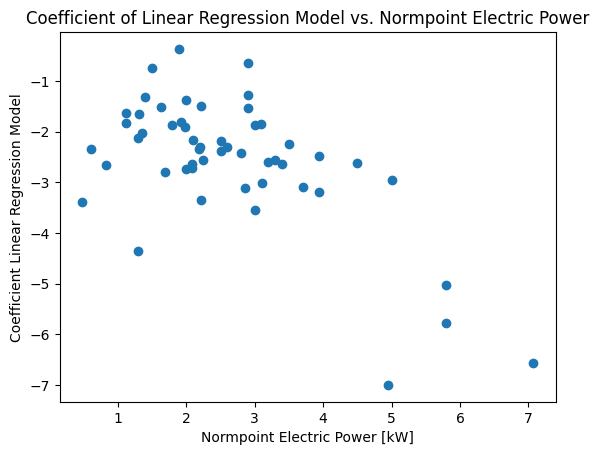

In [ ]:
plt.scatter(powers, coefs)
plt.xlabel('Normpoint Electric Power [kW]')
plt.ylabel('Coefficient Linear Regression Model')
plt.title('Coefficient of Linear Regression Model vs. Normpoint Electric Power')

In [ ]:
energies = []

for household_id in df_features['Household_ID'][df_features['Household_ID'].isin(df_meta['Household_ID'][df_meta['SmartMeterData_Available_15min'] == True])]:
    df_house = heapo.load_smart_meter_data(household_id, resolution='15min')
    
    energies.append(df_house[df_house['Timestamp'].dt.year == 2024]['kWh_received_Total'].sum())

Text(0.5, 1.0, 'Total Energy Consumption vs. Normpoint Electric Power')

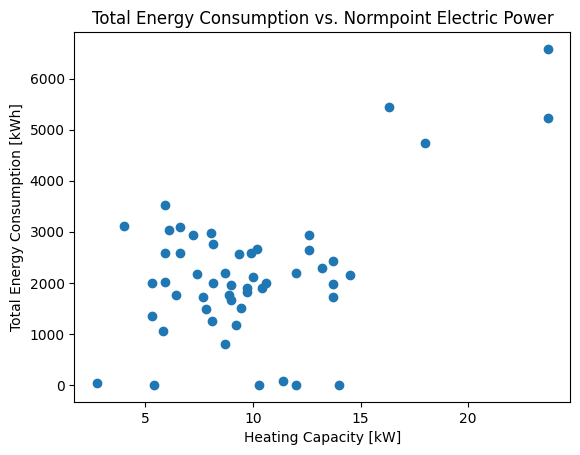

In [ ]:
powers = df_features['HeatPump_Installation_HeatingCapacity'][df_features['Household_ID'].isin(df_meta['Household_ID'][df_meta['SmartMeterData_Available_15min'] == True])].values

plt.scatter(powers, energies)
plt.xlabel('Heating Capacity [kW]')
plt.ylabel('Total Energy Consumption [kWh]')
plt.title('Total Energy Consumption vs. Normpoint Electric Power')


In [ ]:
lens = {}

for household_id in households:
    try:
        df_house = heapo.load_smart_meter_data(household_id, resolution='15min')
        df_house.dropna(subset=['kWh_received_HeatPump'],inplace=True)
        if len(df_house) > 0 and df_house['Household_ID'].iloc[0] in df_features['Household_ID'].values:
            lens[household_id] = len(df_house)
    except:
        pass

In [ ]:
sub_meter_ids = pd.DataFrame.from_dict(lens, orient='index', columns=['Length']).sort_values('Length', ascending=False).index.tolist()

house_id = sub_meter_ids[0]

df_house = heapo.load_smart_meter_data(house_id, resolution='15min')
# df_house.dropna(subset=['kWh_received_HeatPump'],inplace=True)


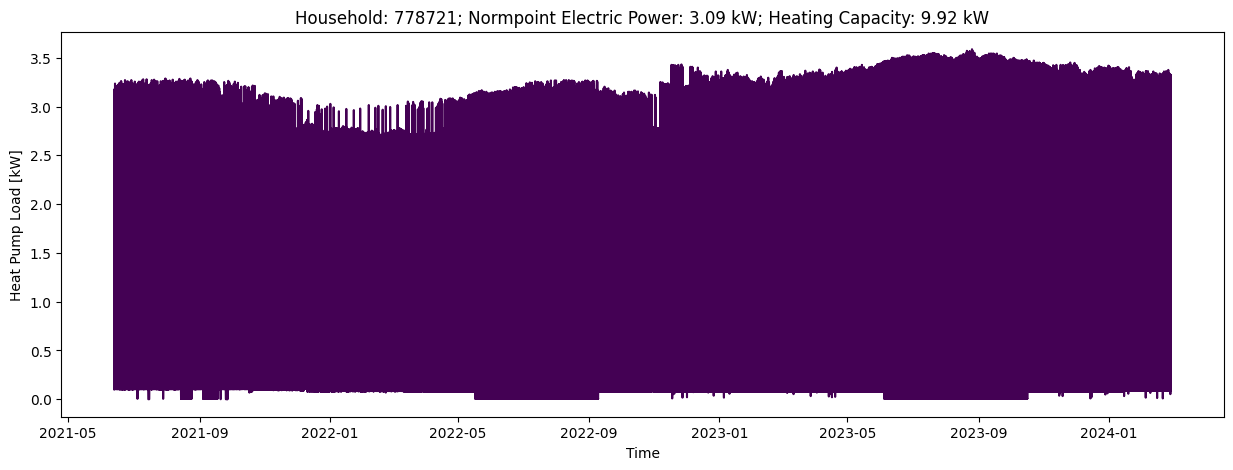

In [ ]:

for house in sub_meter_ids:
    df_house = heapo.load_smart_meter_data(house, resolution='15min')
    hp_load = df_house.set_index('Timestamp')['kWh_received_HeatPump'] * 4
    df_protocol = heapo.load_protocol_data(house)
    hp_power = df_protocol['HeatPump_Installation_Normpoint_ElectricPower'].values[0]
    hp_capacity = df_protocol['HeatPump_Installation_HeatingCapacity'].values[0]

    fig,ax1 = plt.subplots(figsize=(15,5))
    plt.plot(hp_load, color=COLOR_PURPLE)
    plt.ylabel('Heat Pump Load [kW]')
    plt.title('Household: {}; Normpoint Electric Power: {} kW; Heating Capacity: {} kW'.format(house, hp_power, hp_capacity))
    plt.xlabel('Time')
    plt.show()


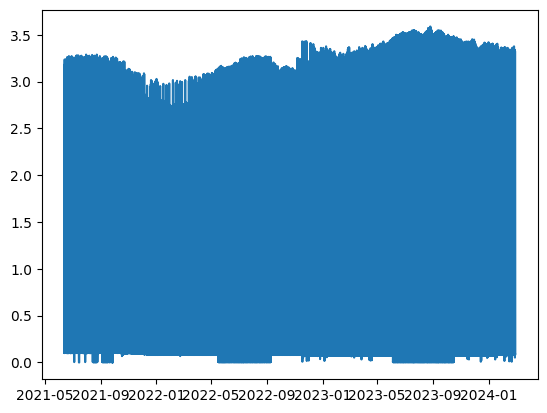

In [ ]:
hp_load = df_house.set_index('Timestamp')['kWh_received_HeatPump'] * 4
plt.plot(hp_load)

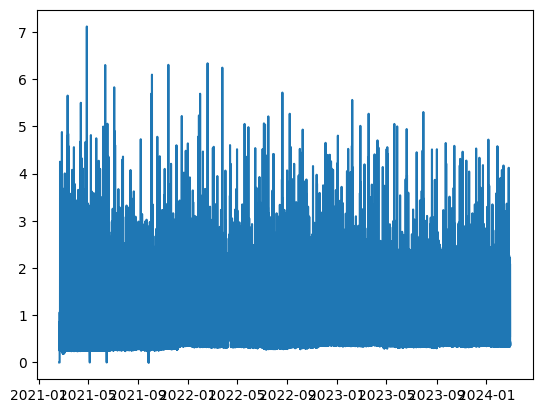

In [ ]:
other_load = df_house.set_index('Timestamp')['kWh_received_Other'] * 4
plt.plot(other_load)

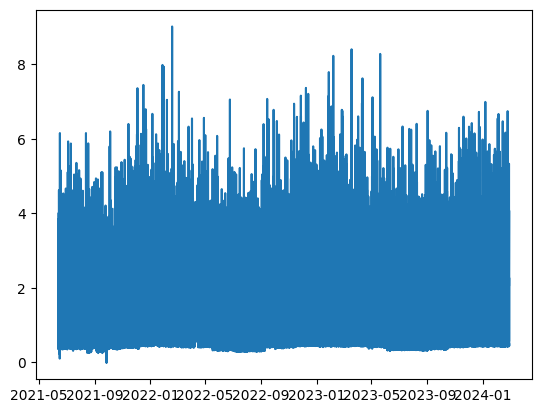

In [ ]:
total_load = df_house.set_index('Timestamp')['kWh_received_Total'] * 4
plt.plot(total_load)

In [ ]:
household_id = 115116
df_house = heapo.load_smart_meter_data(household_id, resolution='15min')

WPuQ Data

In [ ]:
wpuq_data = h5py.File('data\\2020_data_15min.hdf5', 'r')
wpuq_data['NO_PV']['SFH10']['HOUSEHOLD'].keys()

<KeysViewHDF5 ['table']>

In [ ]:
wpuq_transf_df = pd.DataFrame(np.array(wpuq_data['MISC']['ES1']['TRANSFORMER']['table']))
wpuq_transf_df['index'] = pd.to_datetime(wpuq_transf_df['index'], utc=True, origin='unix', unit='s')

Text(0, 0.5, 'Transformer Active Power [kW]')

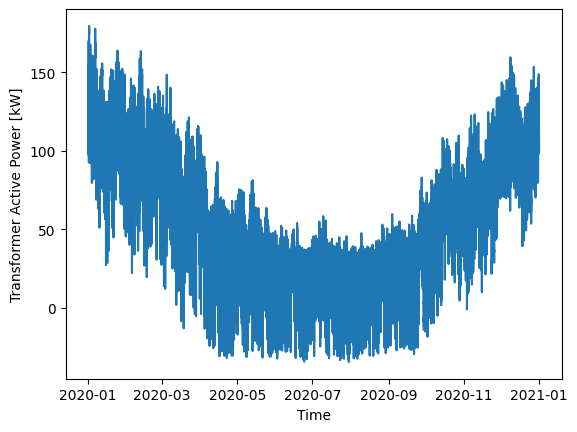

In [ ]:
plt.plot(wpuq_transf_df['index'], wpuq_transf_df['P_TOT'] / 1000)  # Convert W to kW
plt.xlabel('Time')
plt.ylabel('Transformer Active Power [kW]')


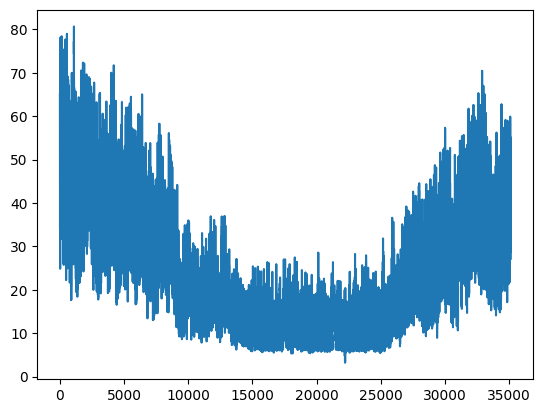

In [ ]:
plt.plot(wpuq_total_df['Load'])

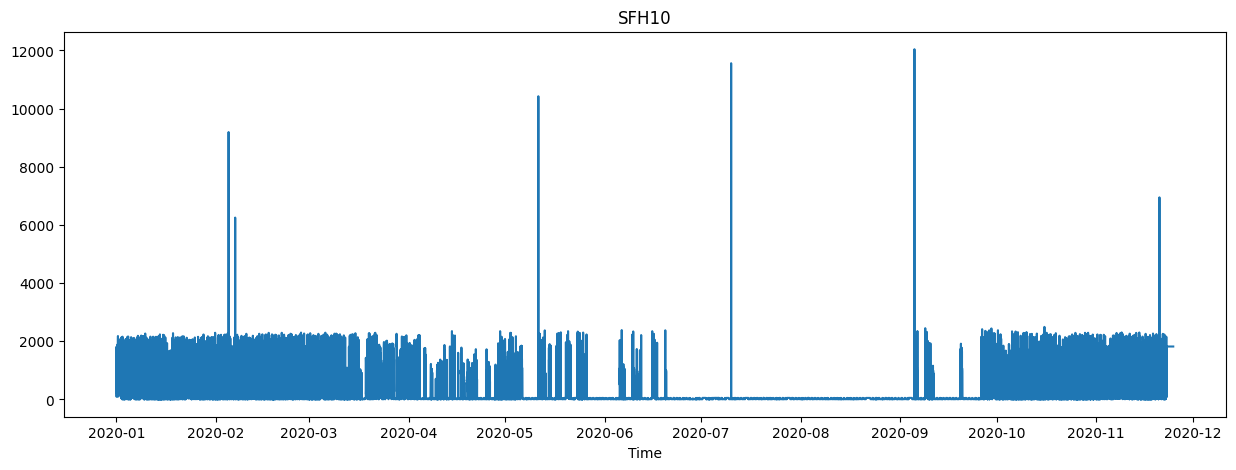

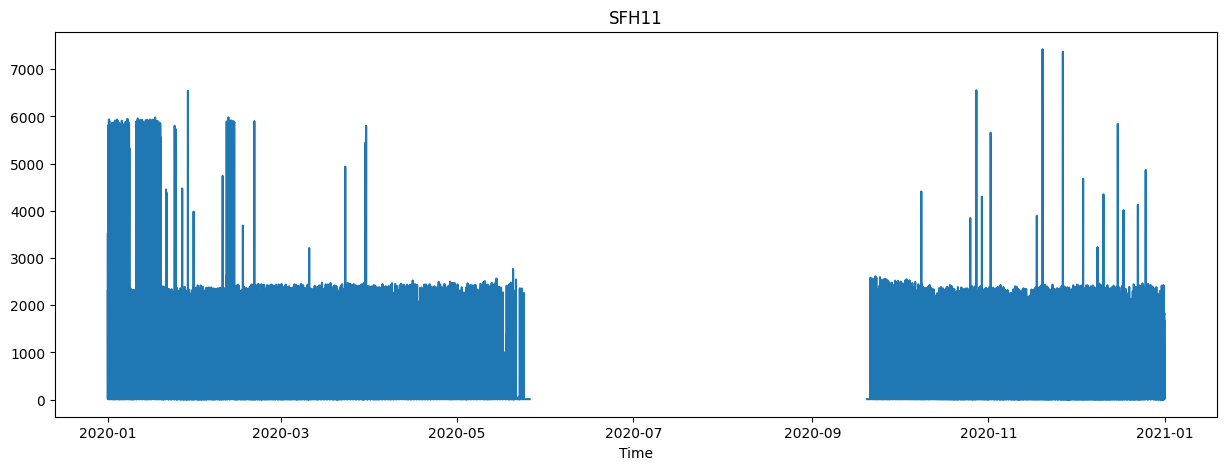

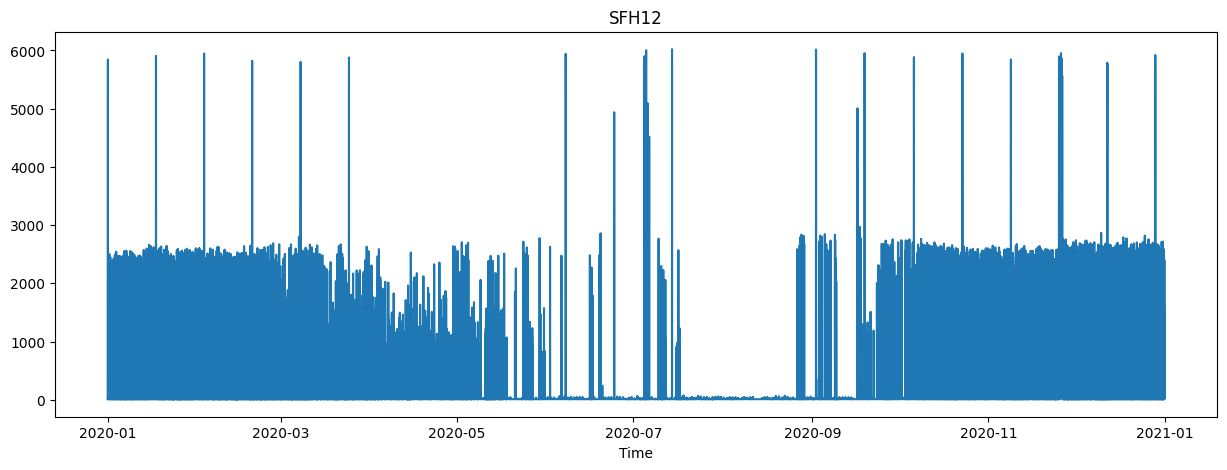

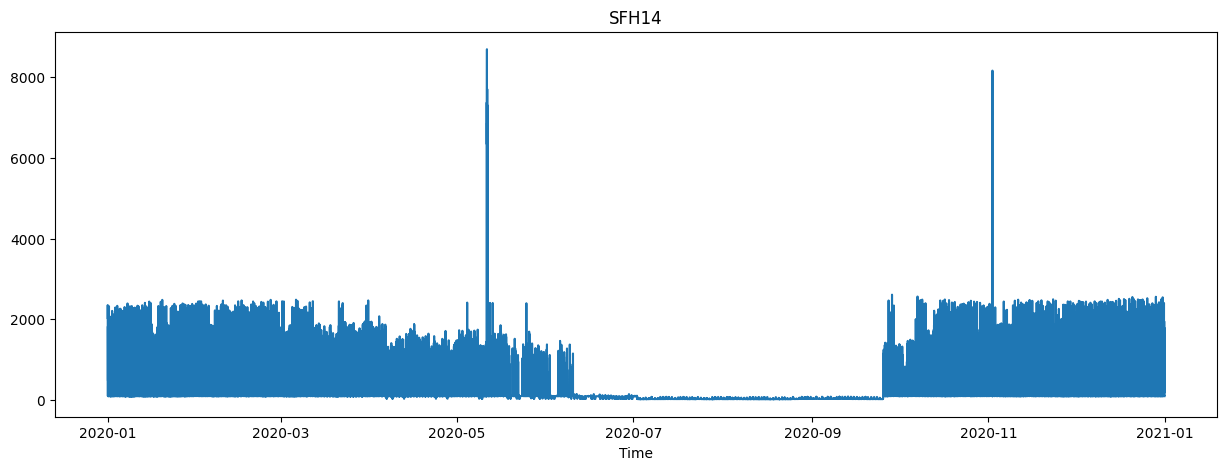

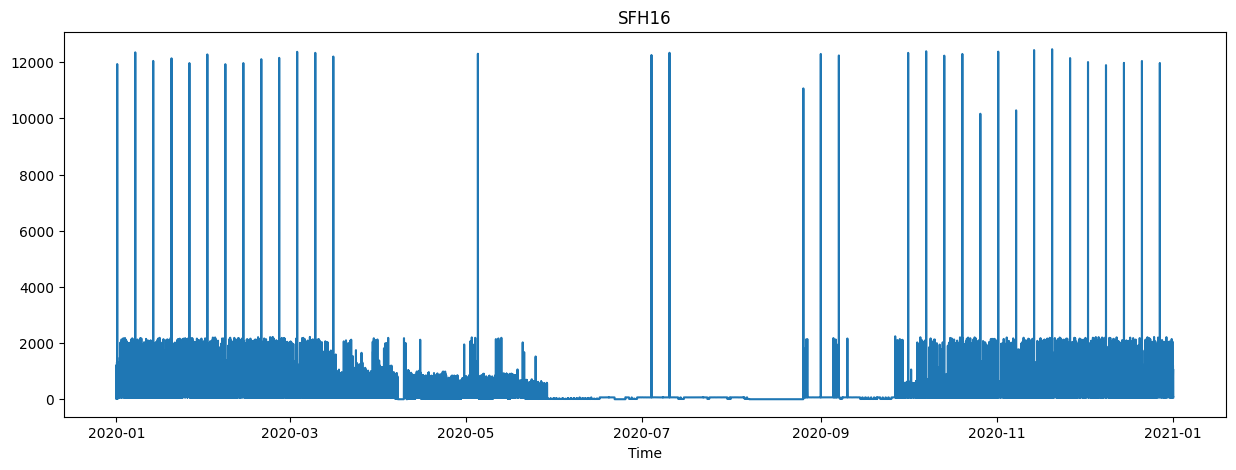

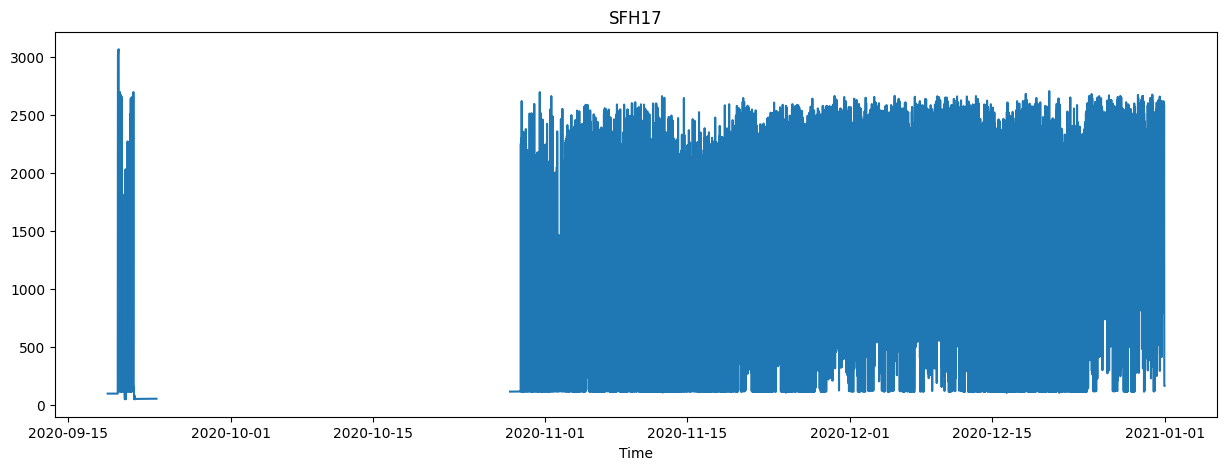

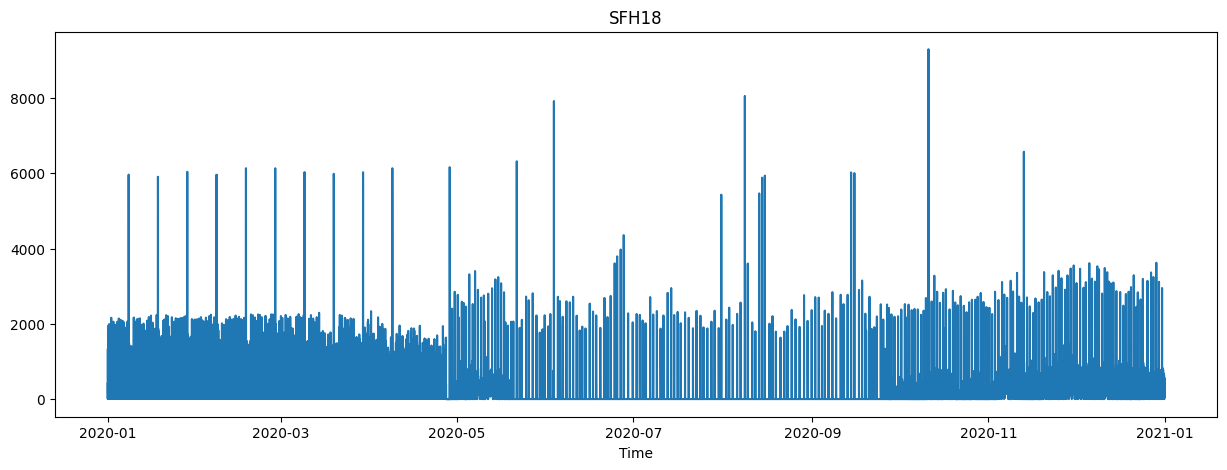

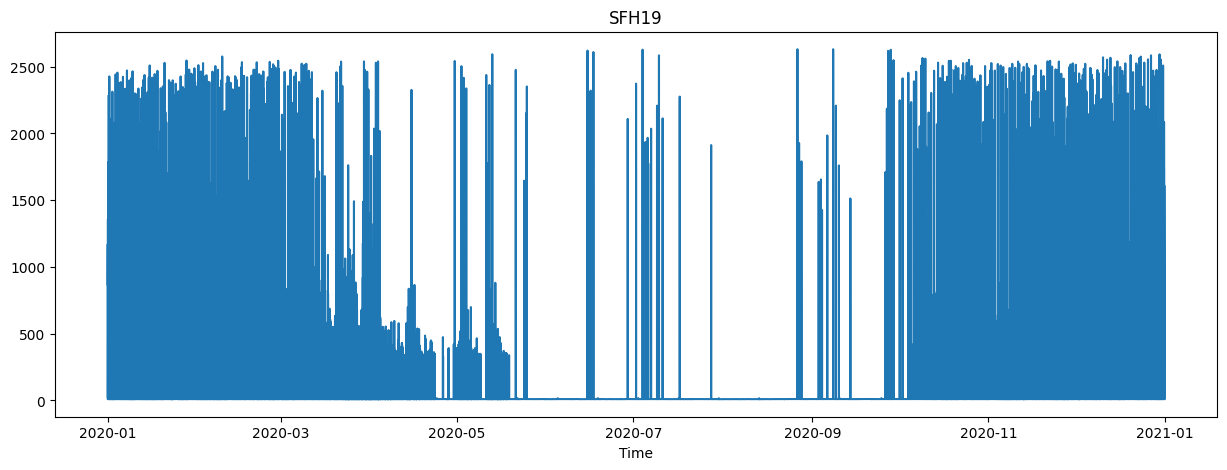

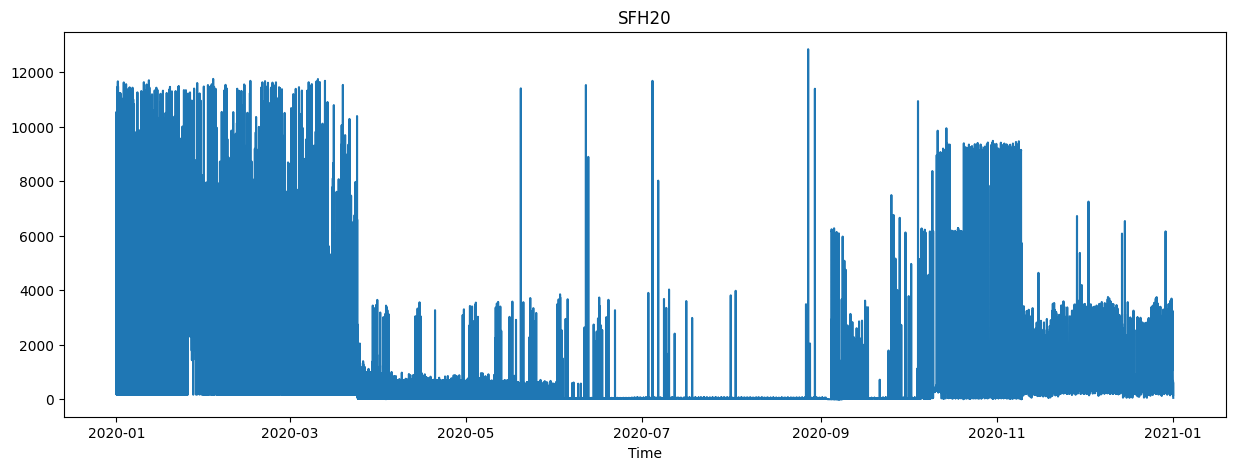

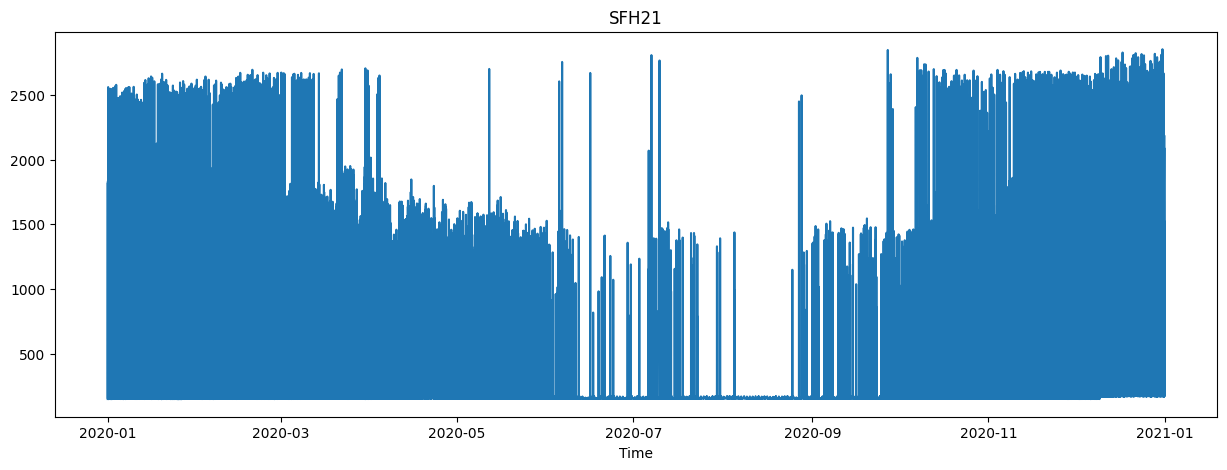

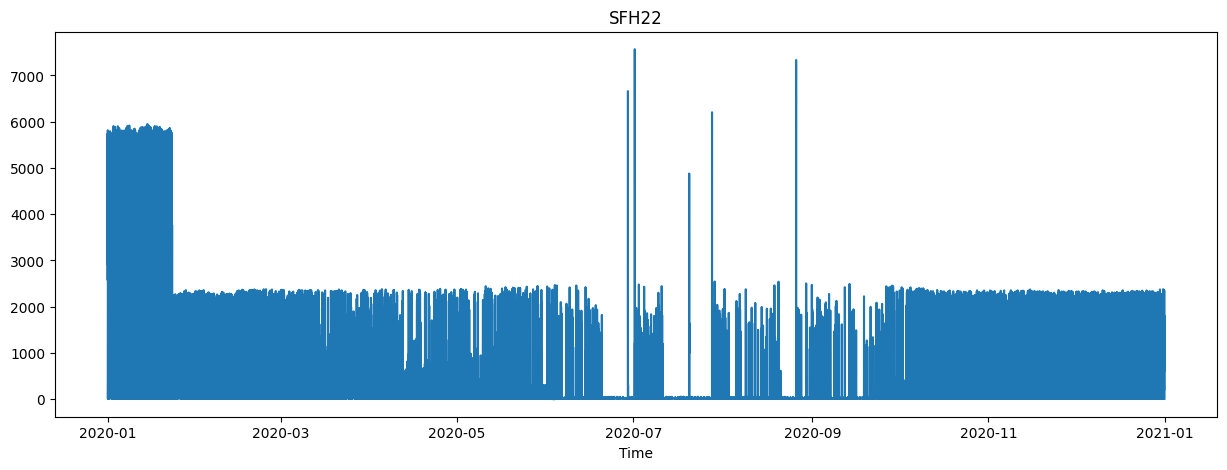

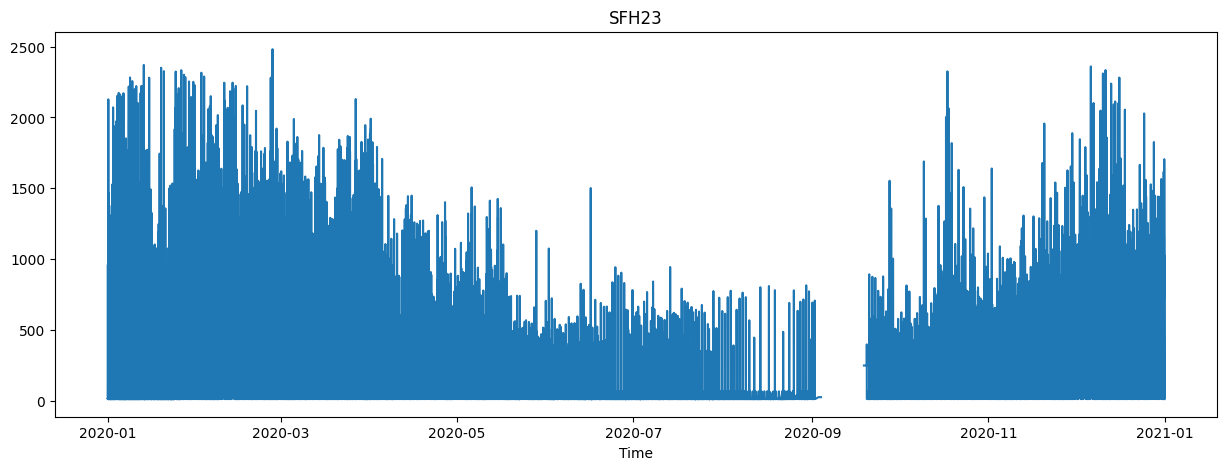

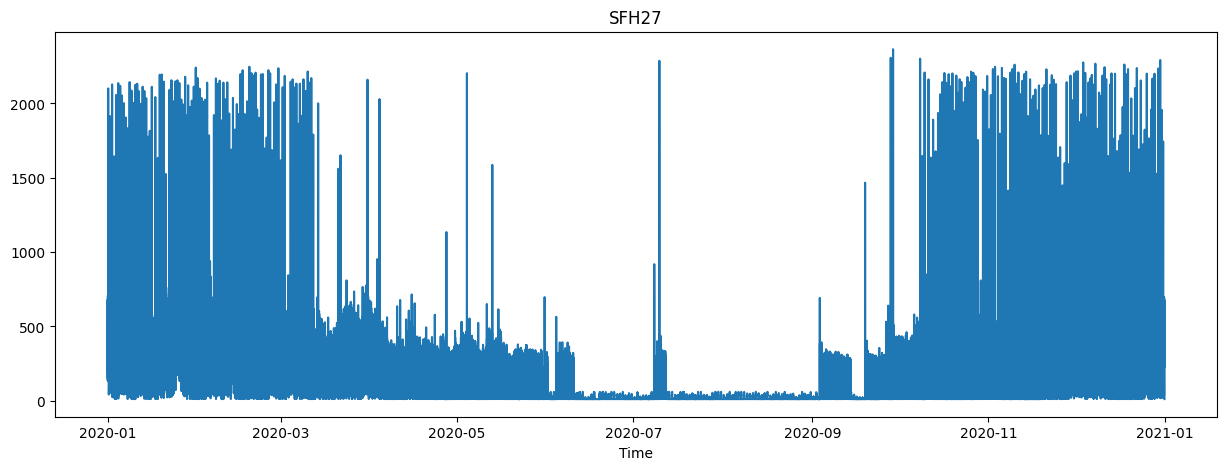

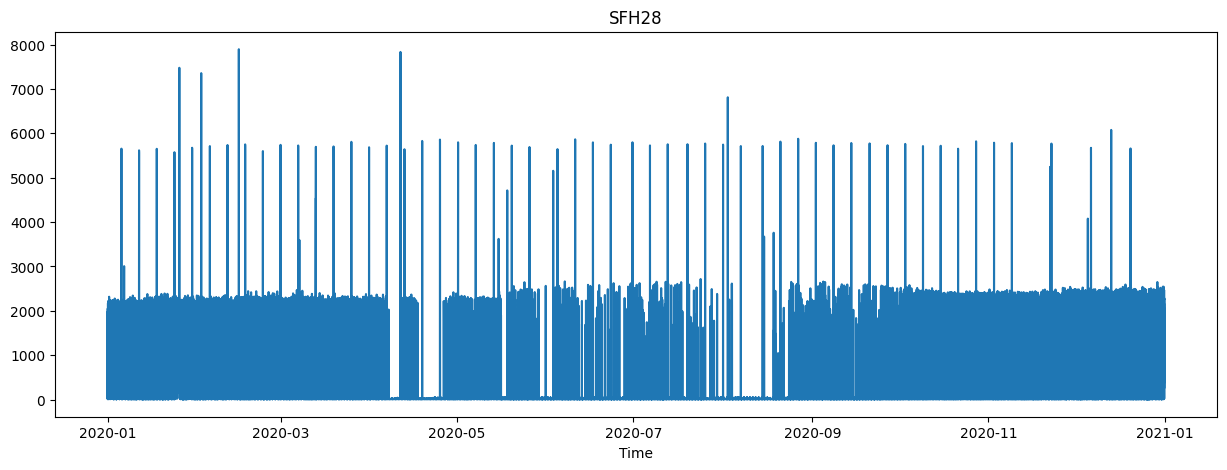

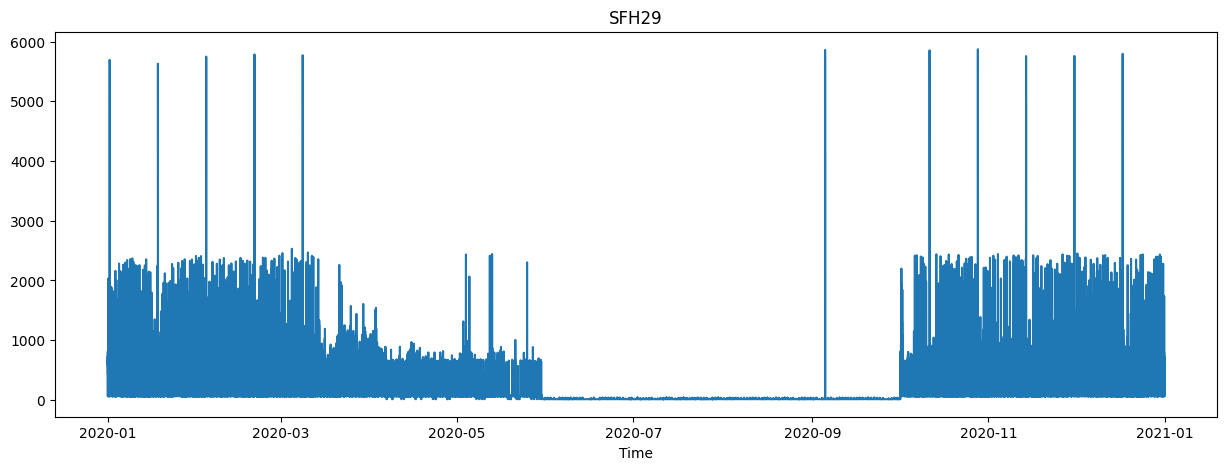

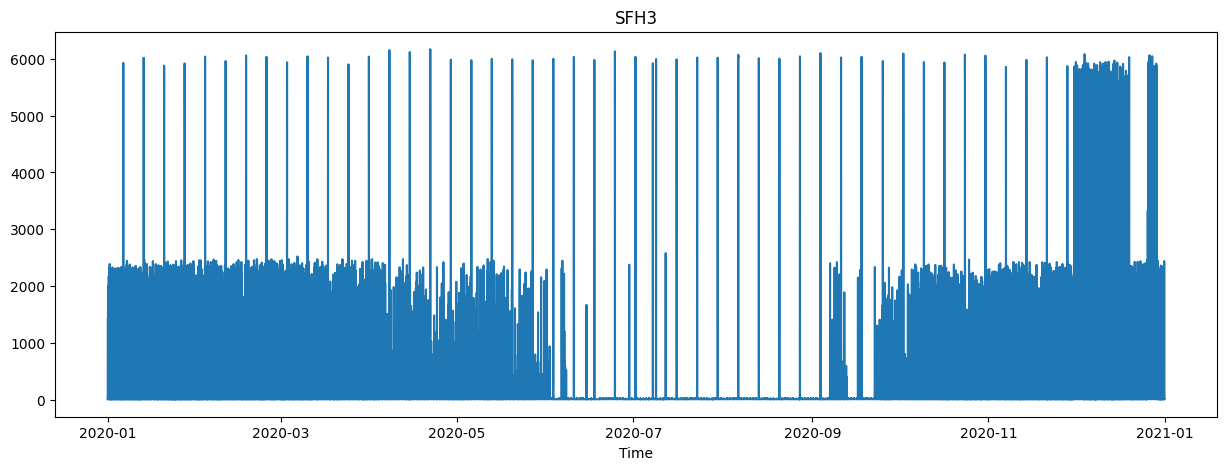

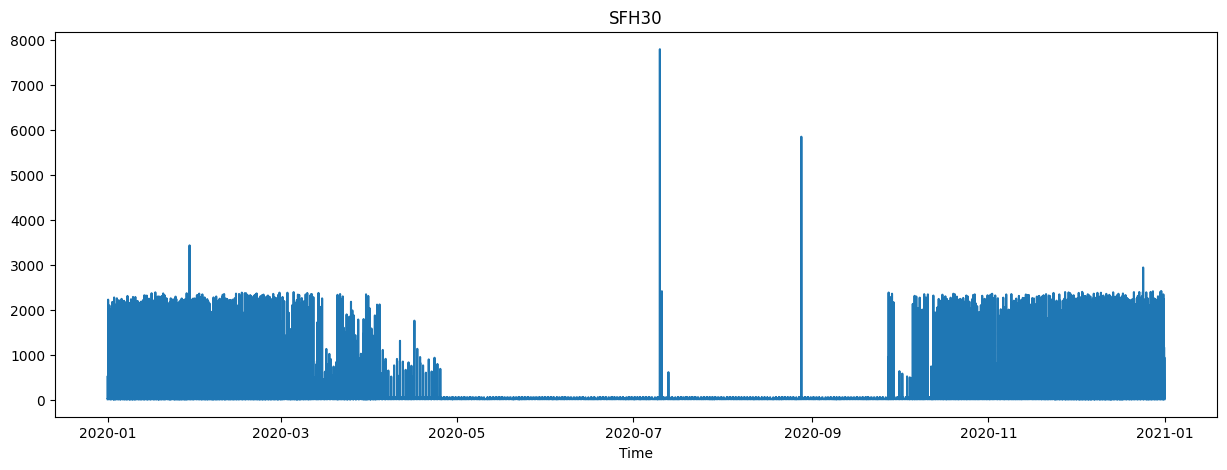

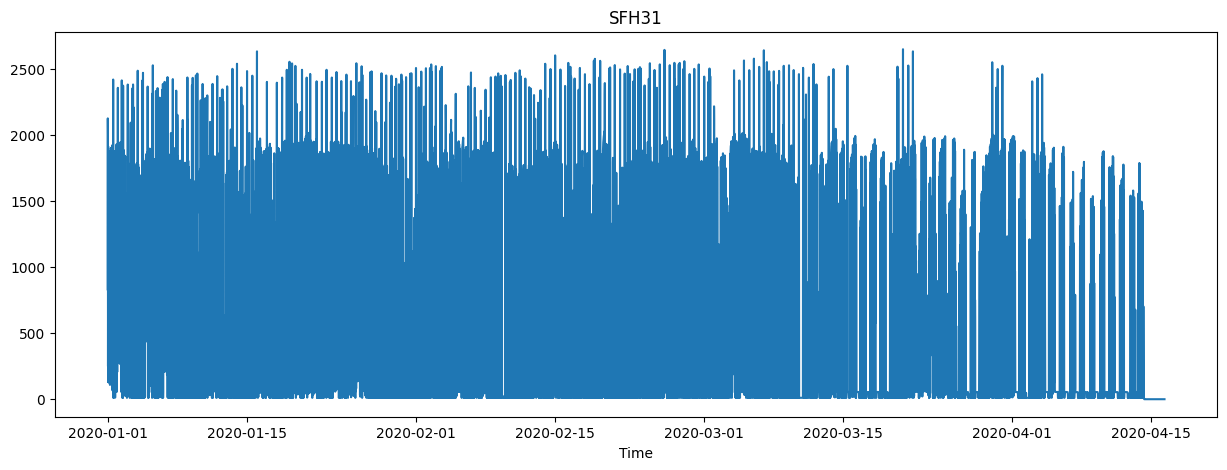

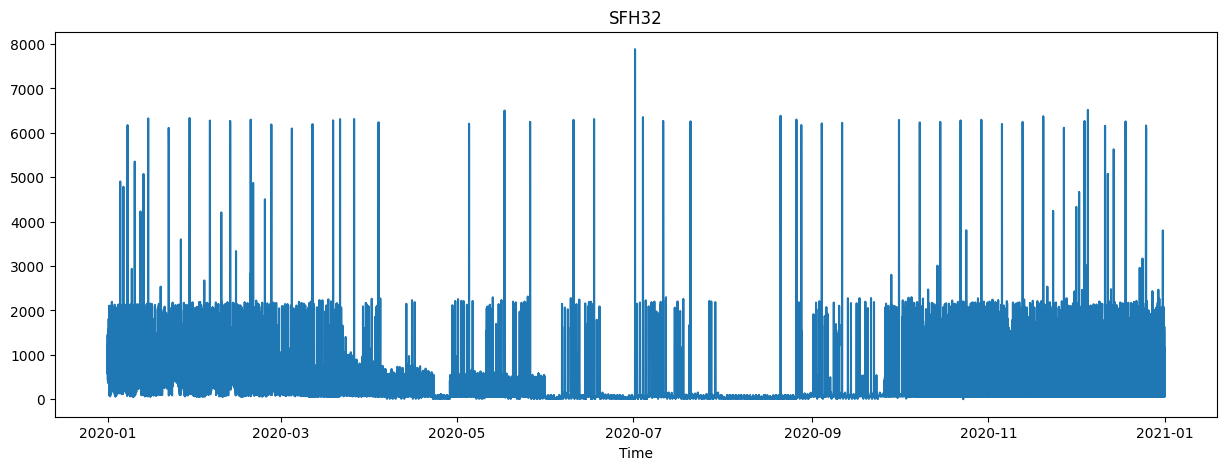

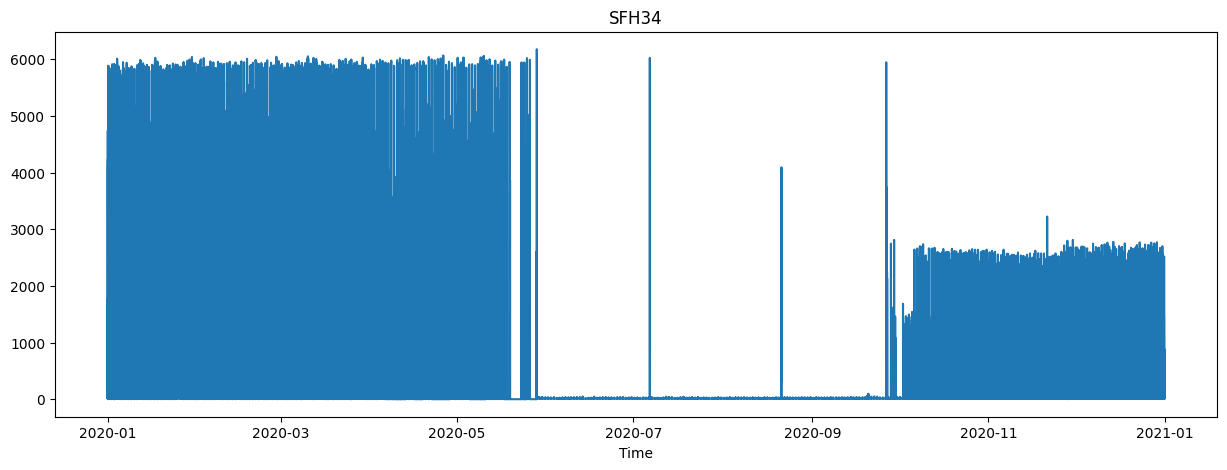

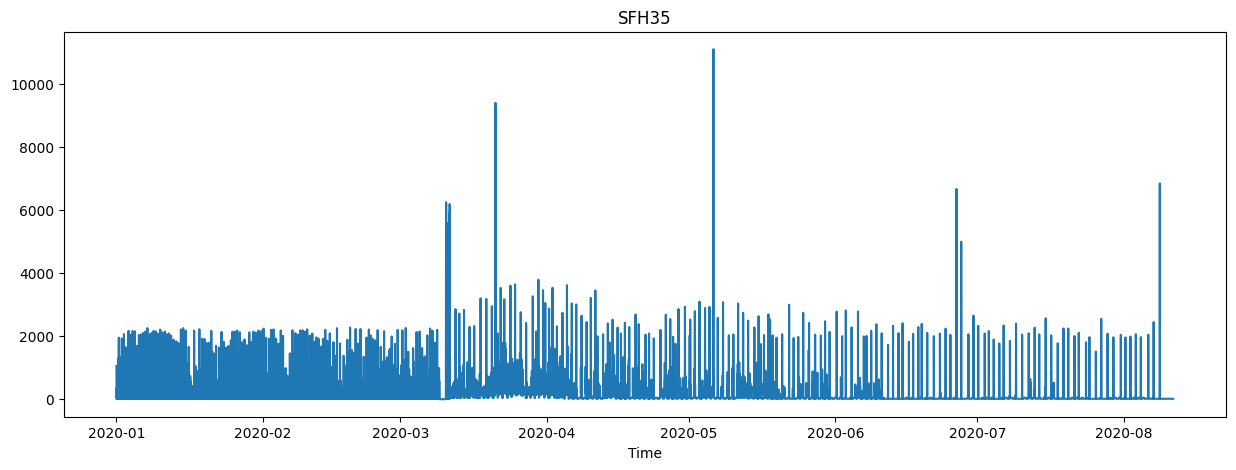

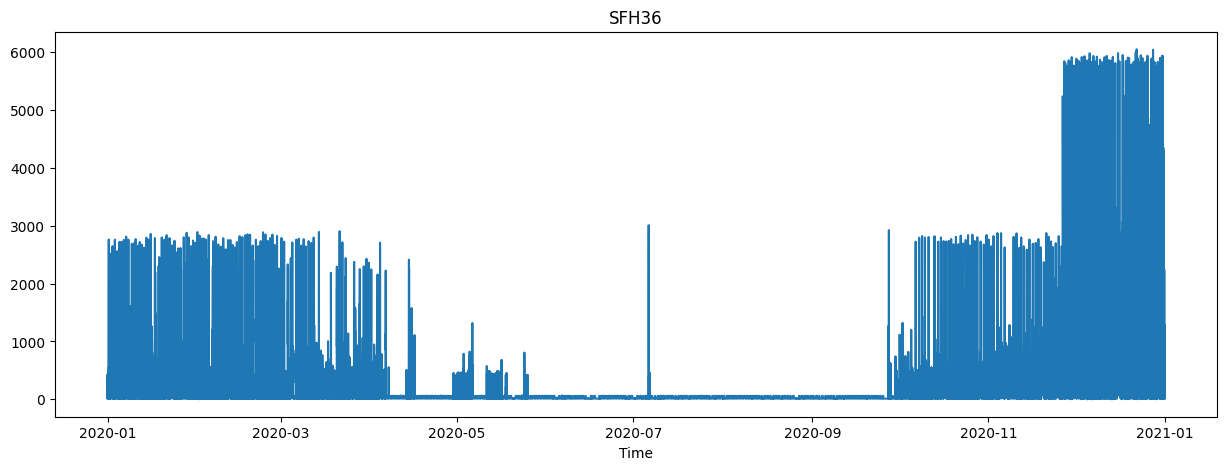

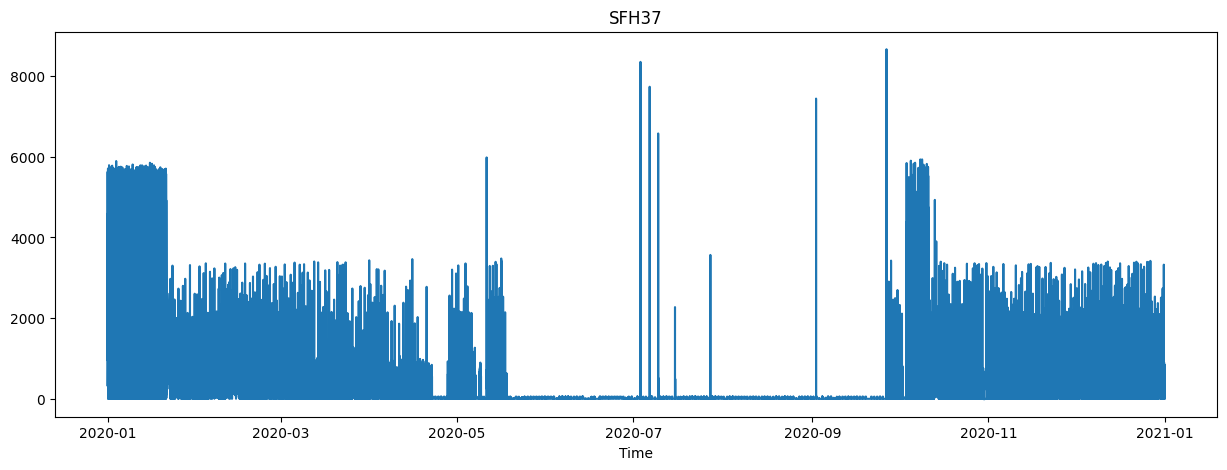

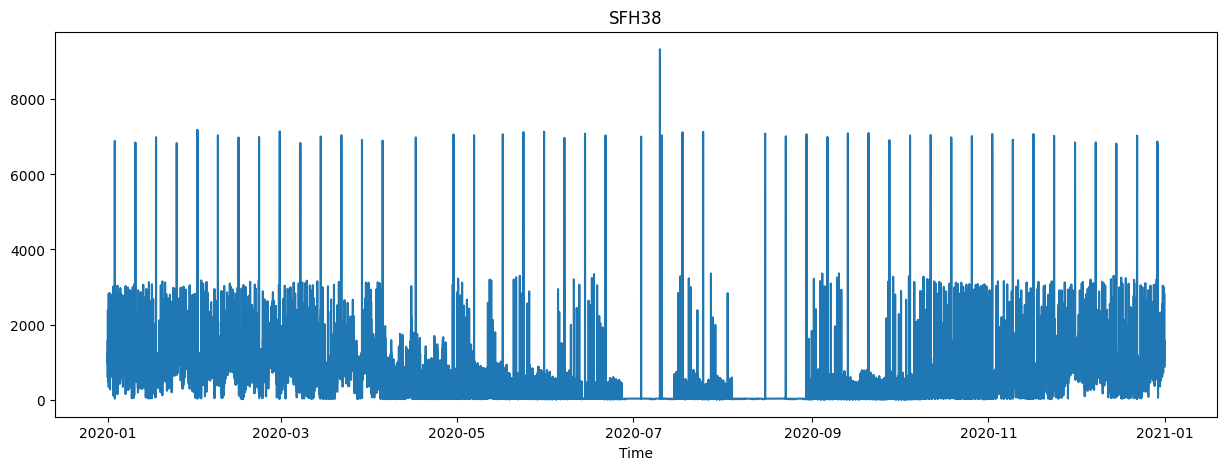

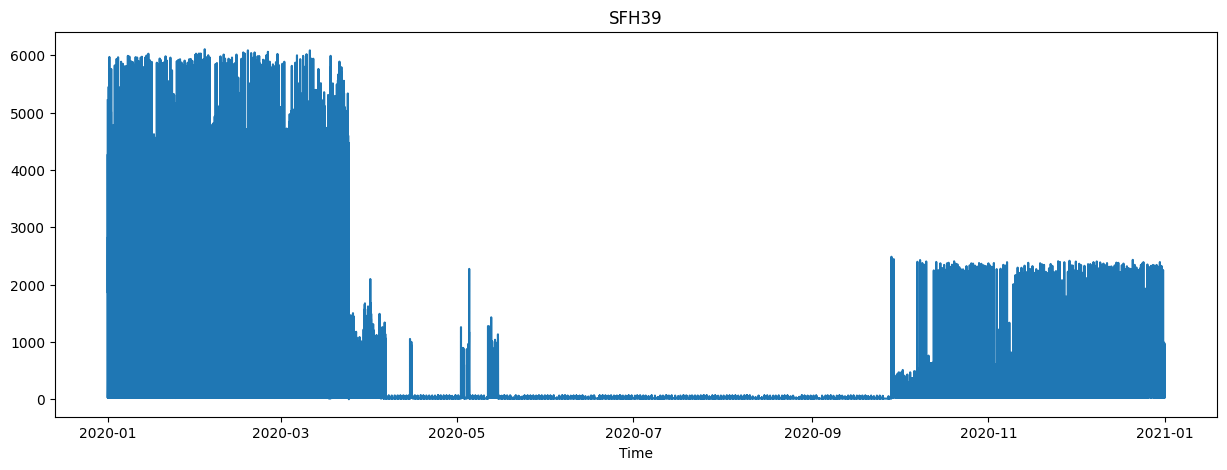

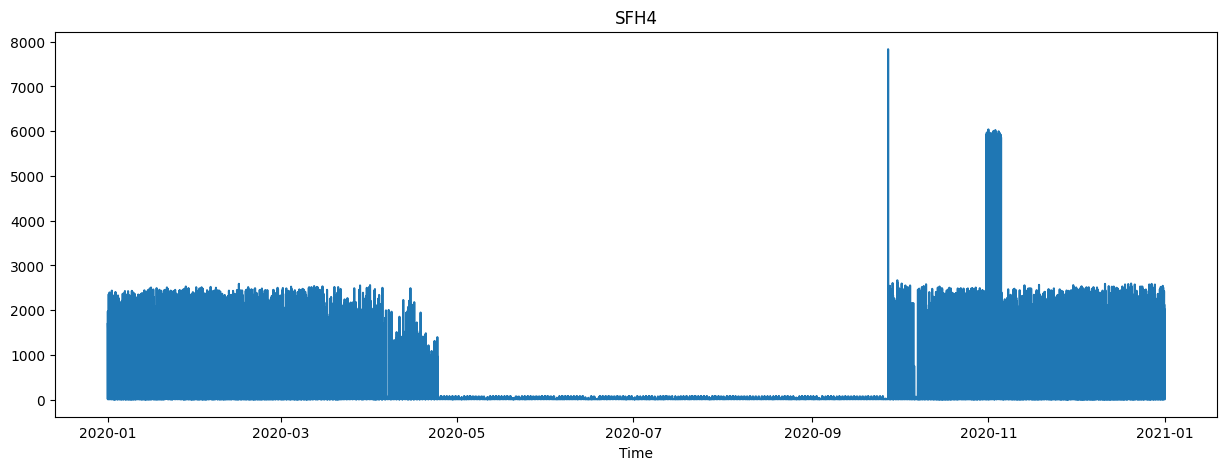

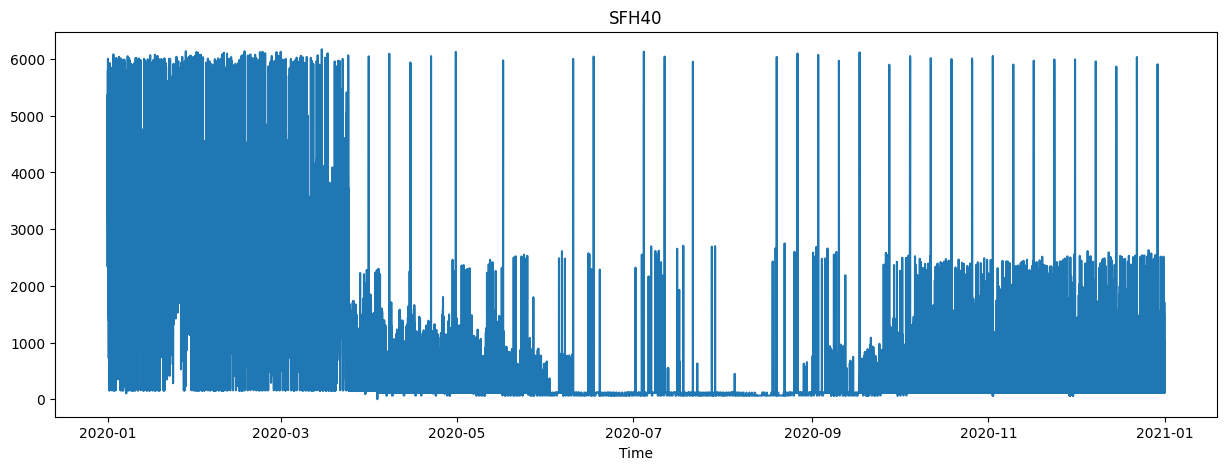

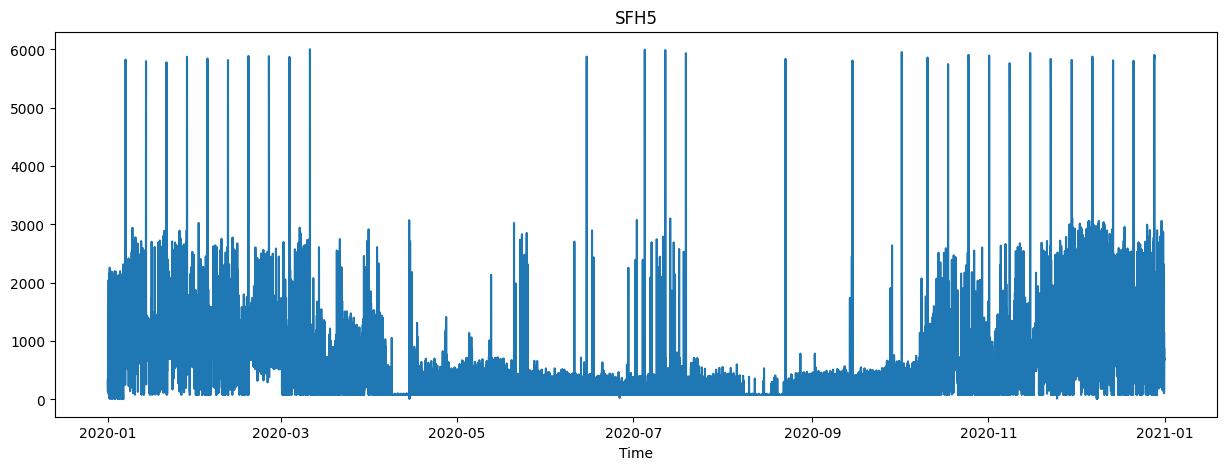

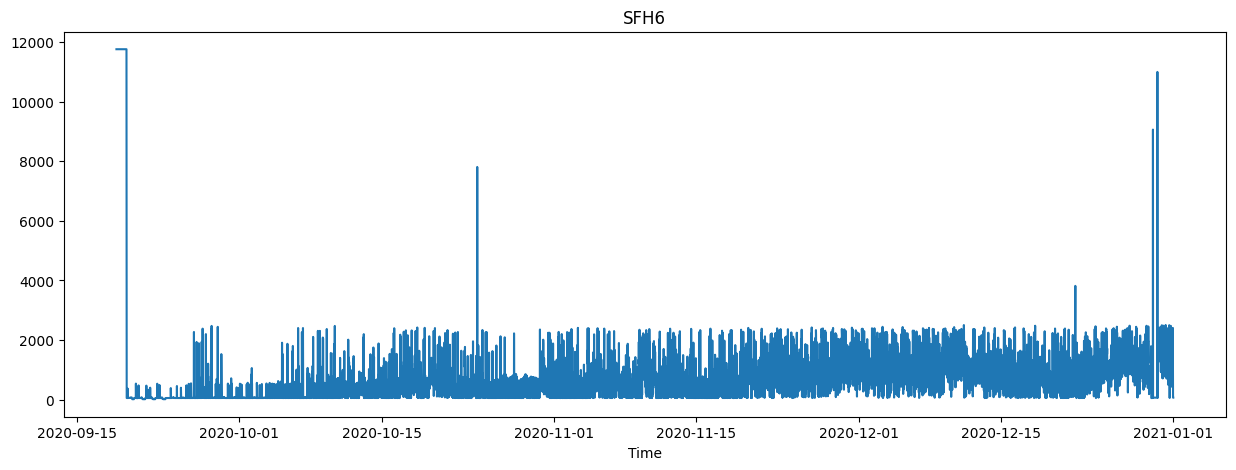

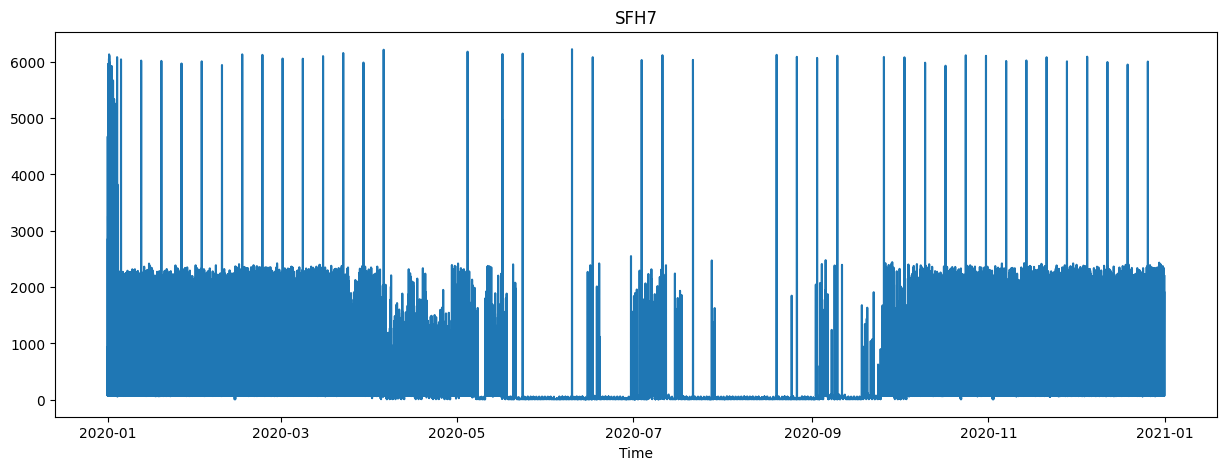

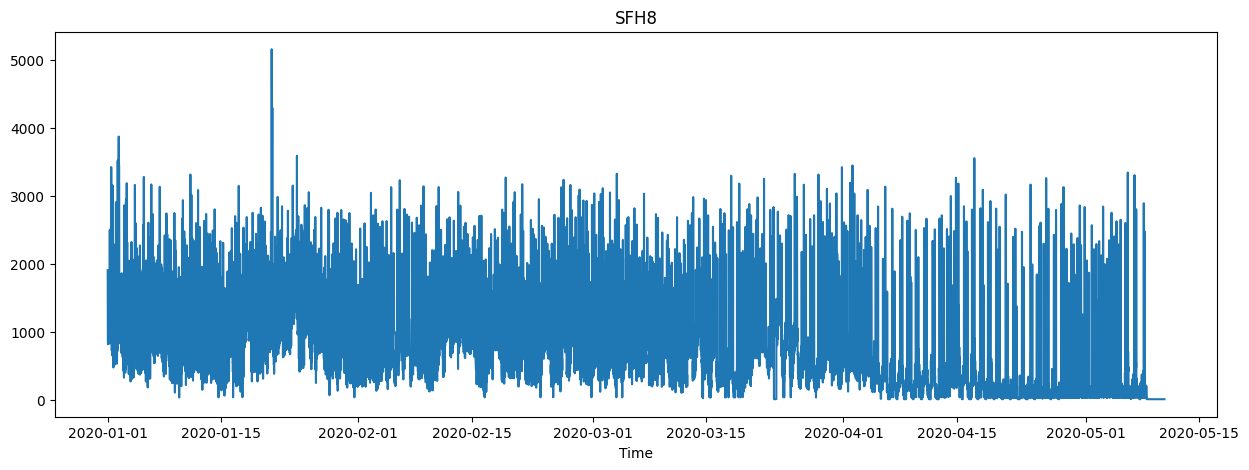

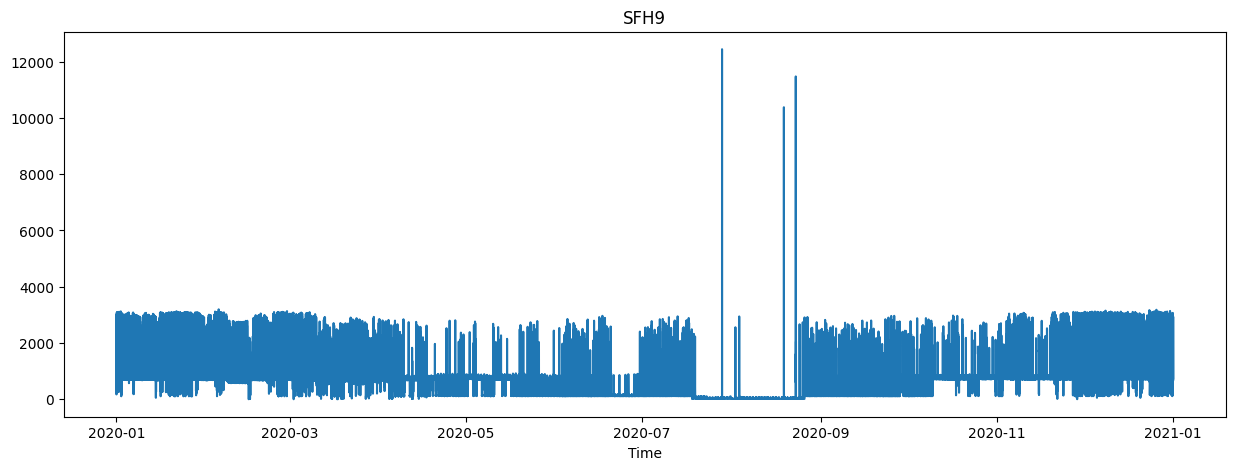

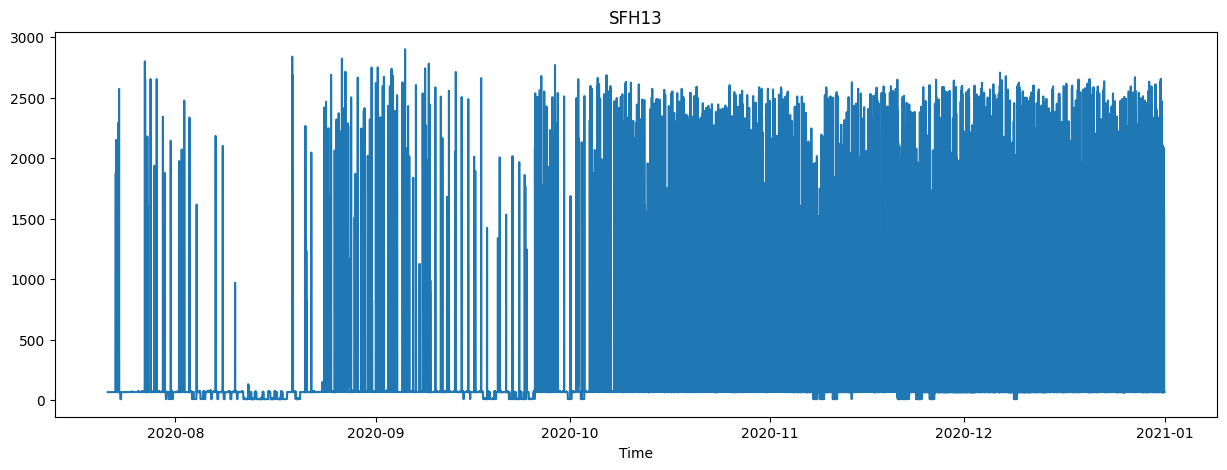

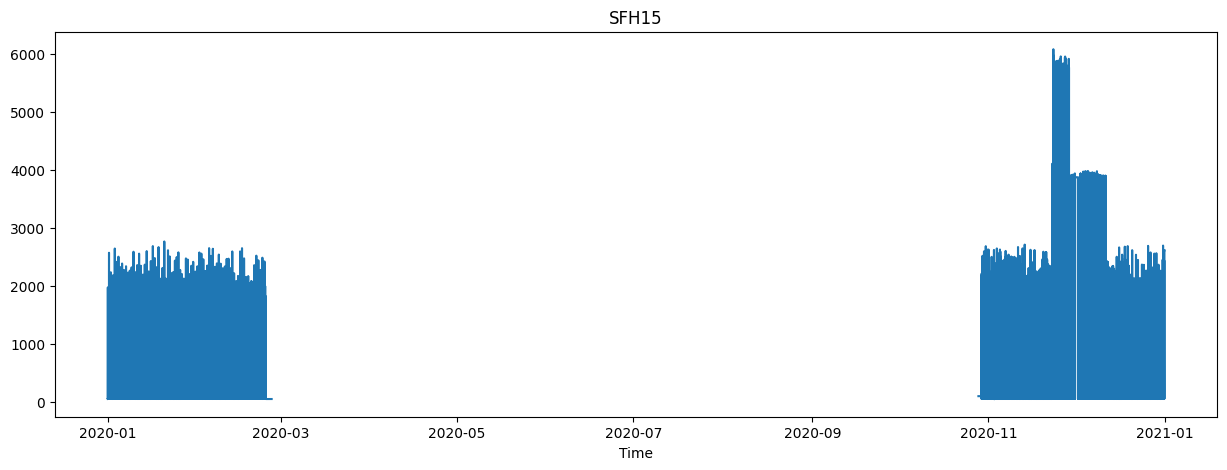

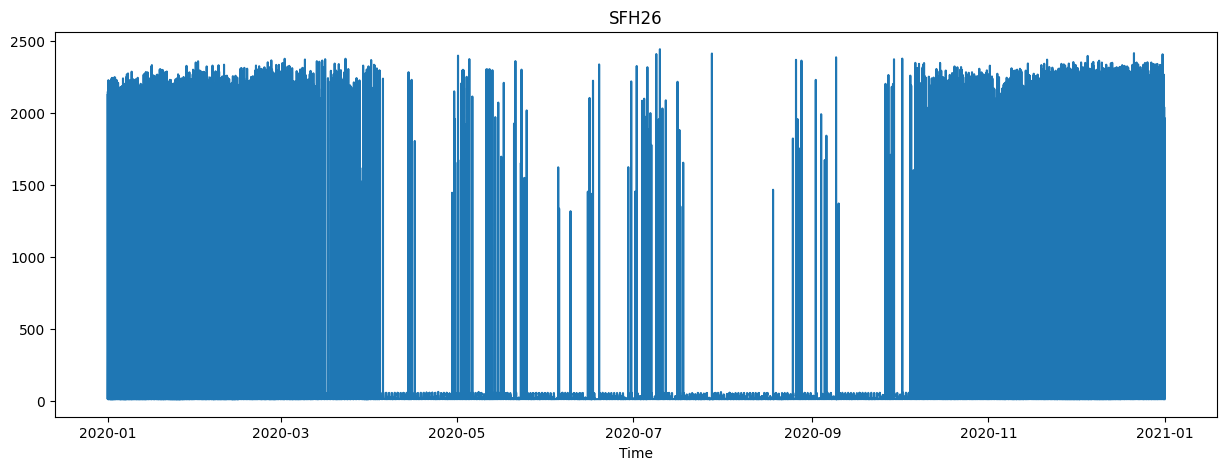

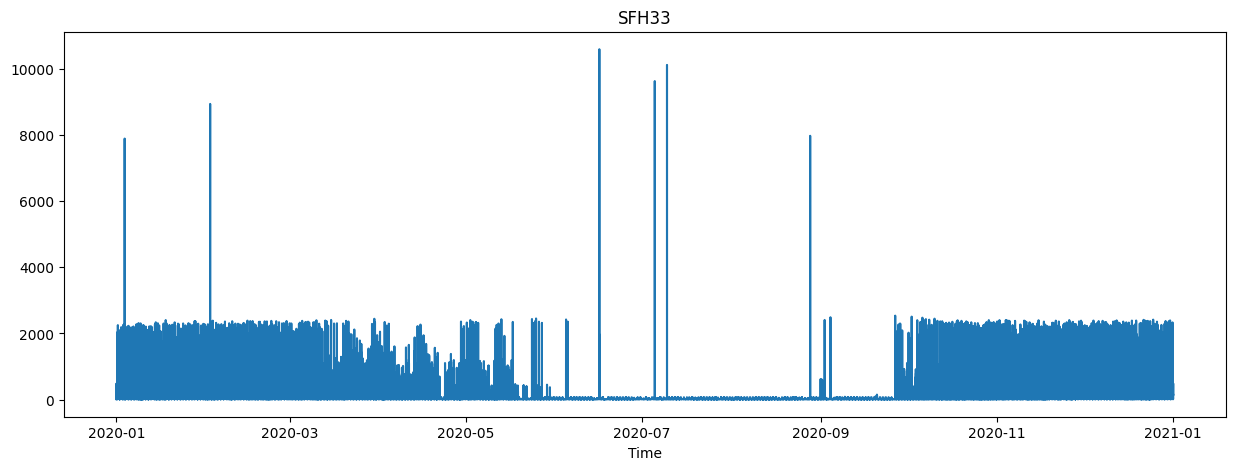

In [ ]:
for building in wpuq_data['NO_PV'].keys():
    hp_df = pd.DataFrame(np.array(wpuq_data['NO_PV'][building]['HEATPUMP']['table']))
    hp_df['index'] = pd.to_datetime(hp_df['index'], utc=True, origin='unix', unit='s')
    plt.figure(figsize=(15,5))
    plt.plot(hp_df['index'], hp_df['P_TOT'])
    plt.title(building)
    plt.xlabel('Time')
    plt.show()

# --------------------------------

for building in wpuq_data['WITH_PV'].keys():
    hp_df = pd.DataFrame(np.array(wpuq_data['WITH_PV'][building]['HEATPUMP']['table']))
    hp_df['index'] = pd.to_datetime(hp_df['index'], utc=True, origin='unix', unit='s')
    plt.figure(figsize=(15,5))
    plt.plot(hp_df['index'], hp_df['P_TOT'])
    plt.title(building)
    plt.xlabel('Time')
    plt.show()

# Checking for PV (HEAPO)

In [ ]:
households = heapo.get_all_households()

for household_id in households:
    try:
        df_house = heapo.load_smart_meter_data(household_id, resolution='15min')
        #df_house = df_house[df_house['Timestamp'] >= pd.to_datetime(start_date)]
        df_house.dropna(subset=['kWh_returned_PV'],inplace=True)
        if len(df_house) > 0:
            print(f'Household {household_id} has submetered PV with {len(df_house)} data points.')
    except:
        pass